In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Question 1

✅ Loaded : 2004.02.12.10.32.39
   Shape  : (20480, 4)  →  4 bearing channels
   Channel: Col 0  |  Samples: 20480  |  Duration: 1.02s
   Range  : [-0.3860,  0.4540] g


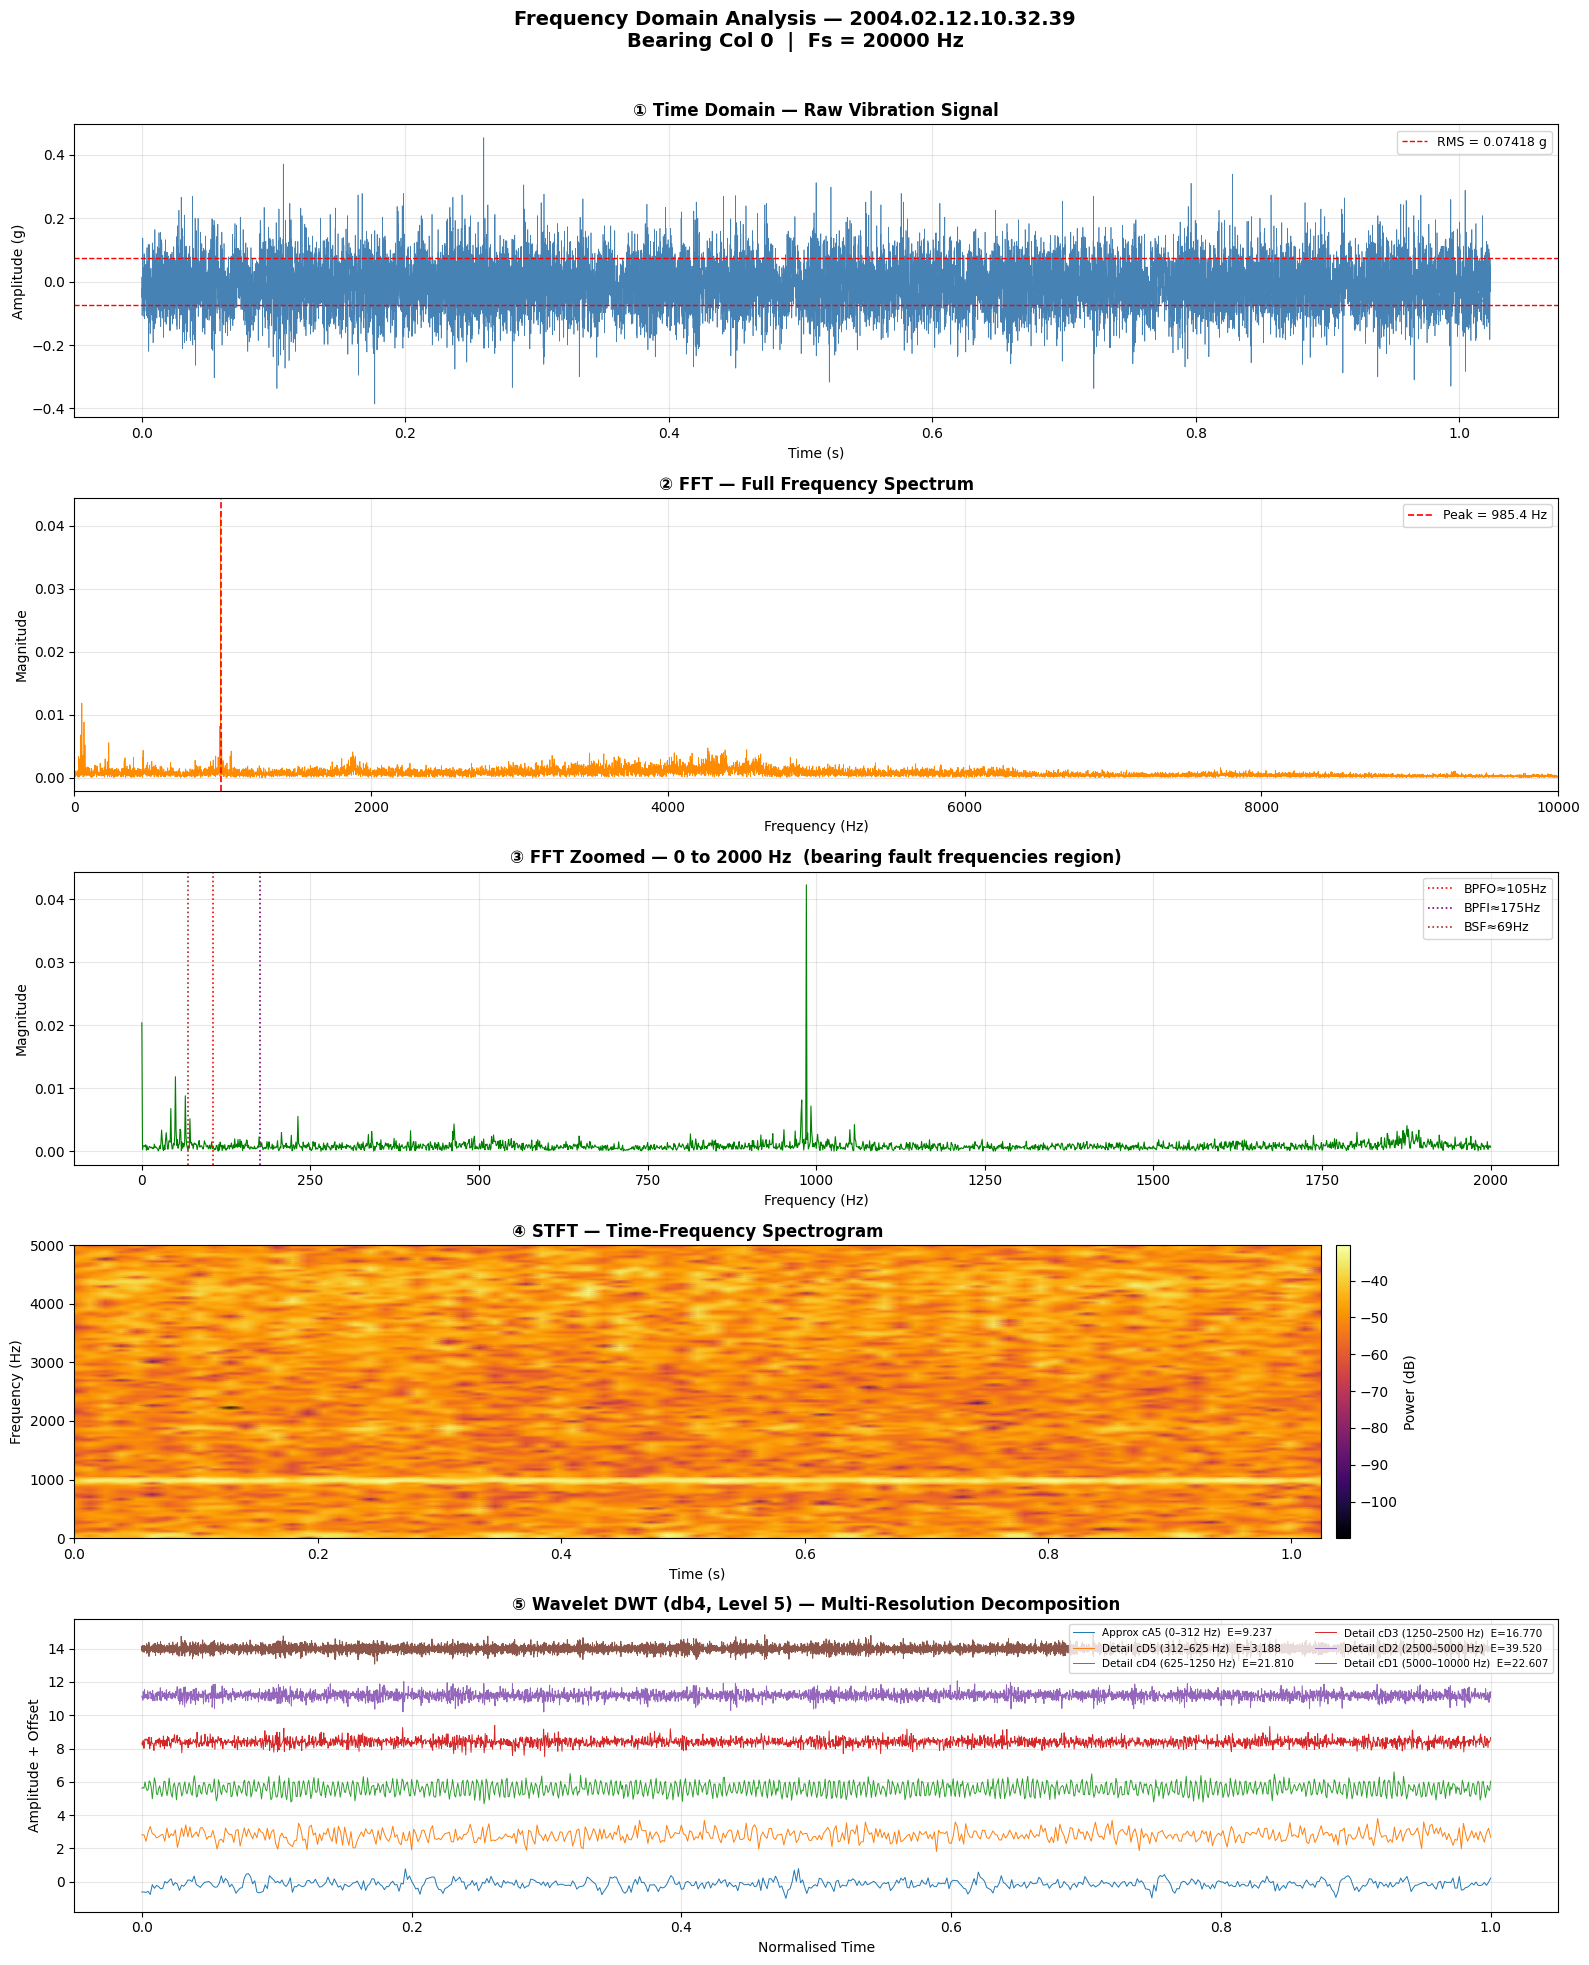


📊 SIGNAL STATISTICS
  RMS            : 0.074179 g
  Peak           : 0.454000 g
  Crest Factor   : 6.1203
  Kurtosis       : 0.6292
  Dominant Freq  : 985.35 Hz

📊 WAVELET BAND ENERGIES
--------------------------------------------------
  Approx cA5 (0–312 Hz)              : 9.2370
  Detail cD5 (312–625 Hz)            : 3.1878
  Detail cD4 (625–1250 Hz)           : 21.8100
  Detail cD3 (1250–2500 Hz)          : 16.7699
  Detail cD2 (2500–5000 Hz)          : 39.5202
  Detail cD1 (5000–10000 Hz)         : 22.6070


In [ ]:
  # ============================================================
  # NASA IMS Bearing — Frequency Domain Visualization (1 file)
  # For Google Colab — point to file path directly
  # ============================================================

  !pip install PyWavelets -q

  import numpy as np
  import pandas as pd
  import matplotlib.pyplot as plt
  from numpy.fft import fft, fftfreq
  from scipy.signal import stft
  import pywt

  # ── CHANGE ONLY THIS ─────────────────────────────────────────
  FILE_PATH   = "/content/drive/MyDrive/Test_2/2004.02.12.10.32.39"  # ← your file path here
  BEARING_COL = 0    # 0-3 for Test 2 (4 columns), 0-7 for Test 1 (8 columns)
  FS          = 20000
  # ─────────────────────────────────────────────────────────────

  # Load
  data   = pd.read_csv(FILE_PATH, sep="\t", header=None).values
  signal = data[:, BEARING_COL].astype(float)
  time   = np.arange(len(signal)) / FS

  print(f"✅ Loaded : {FILE_PATH.split('/')[-1]}")
  print(f"   Shape  : {data.shape}  →  {data.shape[1]} bearing channels")
  print(f"   Channel: Col {BEARING_COL}  |  Samples: {len(signal)}  |  Duration: {len(signal)/FS:.2f}s")
  print(f"   Range  : [{signal.min():.4f},  {signal.max():.4f}] g")

  # ── Compute Transforms ───────────────────────────────────────
  # FFT
  N         = len(signal)
  fft_mag   = np.abs(fft(signal))[:N//2] * (2/N)
  fft_freqs = fftfreq(N, d=1/FS)[:N//2]

  # STFT
  f_stft, t_stft, Zxx = stft(signal, fs=FS, window='hann', nperseg=512, noverlap=256)
  stft_mag = np.abs(Zxx)

  # Wavelet
  coeffs = pywt.wavedec(signal, wavelet='db4', level=5)

  # ── Plot ─────────────────────────────────────────────────────
  fig = plt.figure(figsize=(16, 20))
  fig.suptitle(
      f"Frequency Domain Analysis — {FILE_PATH.split('/')[-1]}\n"
      f"Bearing Col {BEARING_COL}  |  Fs = {FS} Hz",
      fontsize=14, fontweight='bold', y=0.98
  )

  # ① Time Domain
  ax1 = fig.add_subplot(5, 1, 1)
  ax1.plot(time, signal, color='steelblue', linewidth=0.5)
  rms = np.sqrt(np.mean(signal**2))
  ax1.axhline( rms, color='red', linestyle='--', linewidth=1, label=f'RMS = {rms:.5f} g')
  ax1.axhline(-rms, color='red', linestyle='--', linewidth=1)
  ax1.set_title('① Time Domain — Raw Vibration Signal', fontsize=12, fontweight='bold')
  ax1.set_xlabel('Time (s)'); ax1.set_ylabel('Amplitude (g)')
  ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

  # ② FFT Full
  ax2 = fig.add_subplot(5, 1, 2)
  peak_freq = fft_freqs[np.argmax(fft_mag)]
  ax2.plot(fft_freqs, fft_mag, color='darkorange', linewidth=0.6)
  ax2.axvline(peak_freq, color='red', linestyle='--', linewidth=1.2, label=f'Peak = {peak_freq:.1f} Hz')
  ax2.set_title('② FFT — Full Frequency Spectrum', fontsize=12, fontweight='bold')
  ax2.set_xlabel('Frequency (Hz)'); ax2.set_ylabel('Magnitude')
  ax2.set_xlim([0, FS//2]); ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

  # ③ FFT Zoomed 0–2000 Hz
  ax3 = fig.add_subplot(5, 1, 3)
  mask = fft_freqs <= 2000
  ax3.plot(fft_freqs[mask], fft_mag[mask], color='green', linewidth=0.8)
  for label, freq, col in [('BPFO≈105Hz',105,'red'),('BPFI≈175Hz',175,'purple'),('BSF≈69Hz',69,'brown')]:
      ax3.axvline(freq, color=col, linestyle=':', linewidth=1.2, label=label)
  ax3.set_title('③ FFT Zoomed — 0 to 2000 Hz  (bearing fault frequencies region)', fontsize=12, fontweight='bold')
  ax3.set_xlabel('Frequency (Hz)'); ax3.set_ylabel('Magnitude')
  ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

  # ④ STFT Spectrogram
  ax4 = fig.add_subplot(5, 1, 4)
  im = ax4.pcolormesh(t_stft, f_stft, 20*np.log10(stft_mag + 1e-10),
                      shading='gouraud', cmap='inferno')
  ax4.set_ylim([0, 5000])
  ax4.set_title('④ STFT — Time-Frequency Spectrogram', fontsize=12, fontweight='bold')
  ax4.set_xlabel('Time (s)'); ax4.set_ylabel('Frequency (Hz)')
  fig.colorbar(im, ax=ax4, label='Power (dB)', pad=0.01)

  # ⑤ Wavelet
  ax5 = fig.add_subplot(5, 1, 5)
  labels = ['Approx cA5 (0–312 Hz)', 'Detail cD5 (312–625 Hz)',
            'Detail cD4 (625–1250 Hz)', 'Detail cD3 (1250–2500 Hz)',
            'Detail cD2 (2500–5000 Hz)', 'Detail cD1 (5000–10000 Hz)']
  offset = 0
  for i, (coeff, lbl) in enumerate(zip(coeffs, labels)):
      t_w  = np.linspace(0, 1, len(coeff))
      norm = coeff / (np.max(np.abs(coeff)) + 1e-10)
      ax5.plot(t_w, norm + offset, color=plt.cm.tab10.colors[i],
              linewidth=0.7, label=f'{lbl}  E={np.sum(coeff**2):.3f}')
      offset += 2.8
  ax5.set_title('⑤ Wavelet DWT (db4, Level 5) — Multi-Resolution Decomposition', fontsize=12, fontweight='bold')
  ax5.set_xlabel('Normalised Time'); ax5.set_ylabel('Amplitude + Offset')
  ax5.legend(loc='upper right', fontsize=7.5, ncol=2); ax5.grid(True, alpha=0.3)

  plt.tight_layout(rect=[0, 0, 1, 0.97])
  plt.show()

  # ── Stats ────────────────────────────────────────────────────
  print("\n" + "="*50)
  print("📊 SIGNAL STATISTICS")
  print("="*50)
  print(f"  RMS            : {rms:.6f} g")
  print(f"  Peak           : {np.max(np.abs(signal)):.6f} g")
  print(f"  Crest Factor   : {np.max(np.abs(signal))/rms:.4f}")
  print(f"  Kurtosis       : {pd.Series(signal).kurt():.4f}")
  print(f"  Dominant Freq  : {peak_freq:.2f} Hz")
  print("\n📊 WAVELET BAND ENERGIES")
  print("-"*50)
  for lbl, c in zip(labels, coeffs):
      print(f"  {lbl:<35}: {np.sum(c**2):.4f}")
  print("="*50)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted
✅ Output folder ready: /content/drive/MyDrive/ML_Project/features

📂 Found 993 files in Test_2
   First file : .ipynb_checkpoints
   Last file  : 2004.02.19.06.22.39

⚙️  EXTRACTING FEATURES FROM ALL FILES...
    Bearing column : 3 (Bearing 4 — fault bearing)
    Transforms     : FFT (15 features) + Wavelet (18 features)
    Total expected : ~35 features × 984 files



Processing files:   0%|          | 0/993 [00:00<?, ?it/s]

  ⚠ Skipped .ipynb_checkpoints: [Errno 21] Is a directory: '/content/drive/MyDrive/Test_2/.ipynb_checkpoints'


Processing files: 100%|██████████| 993/993 [00:57<00:00, 17.33it/s]



✅ Feature extraction complete!
   Files processed : 992
   Files skipped   : 1
   Feature matrix  : 992 rows × 39 columns
   Feature columns : 34

✅ CSV saved → /content/drive/MyDrive/ML_Project/features/ims_features.csv

📊 FEATURE MATRIX PREVIEW

First 3 rows (healthy bearing):
   fft_mean   fft_std   fft_max  fft_peak_freq  fft_energy  fft_entropy
0  0.000529  0.000558  0.020553     985.351562    0.006055     8.906499
1  0.000529  0.000558  0.020553     985.351562    0.006055     8.906499
2  0.000563  0.000548  0.019299     985.351562    0.006323     8.913491

Last 3 rows (failing bearing):
     fft_mean   fft_std   fft_max  fft_peak_freq  fft_energy  fft_entropy
989   0.00096  0.001553  0.041842     924.804688    0.034125     8.698131
990   0.00001  0.000038  0.003571       0.000000    0.000016     8.795348
991   0.00001  0.000037  0.003390       0.000000    0.000015     8.790224

📊 LABEL DISTRIBUTION
health_status
Normal     595
Suspect    249
Failure    148

RUL range : 0.999 (st

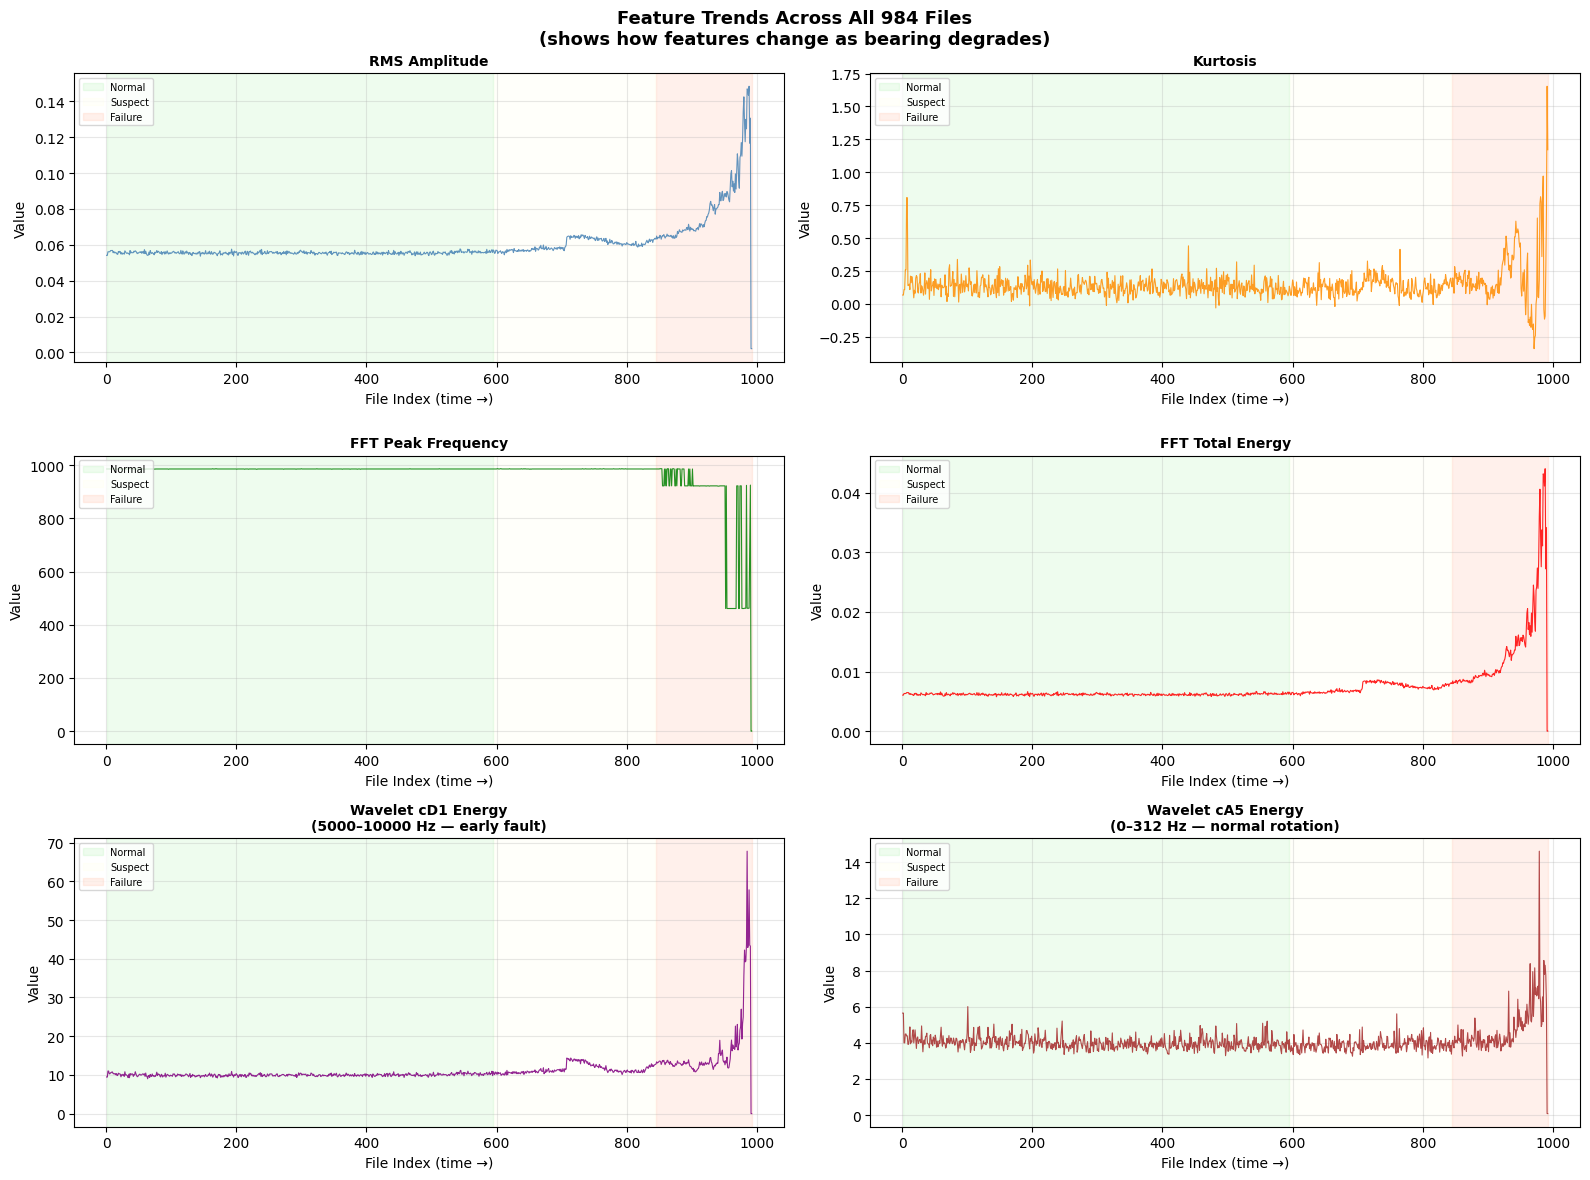


📊 FEATURE SUMMARY STATISTICS
       fft_mean   fft_std   fft_max  fft_peak_freq  fft_energy  fft_entropy       rms  kurtosis  skewness  peak2peak  crest_factor  fft_band1_energy  fft_band2_energy  fft_band3_energy  fft_band4_energy  fft_band5_energy  wav_cA5_energy  wav_cA5_std  wav_cA5_max  wav_cD5_energy  wav_cD5_std  wav_cD5_max  wav_cD4_energy  wav_cD4_std  wav_cD4_max  wav_cD3_energy  wav_cD3_std  wav_cD3_max  wav_cD2_energy  wav_cD2_std  wav_cD2_max  wav_cD1_energy  wav_cD1_std  wav_cD1_max
count  992.0000  992.0000  992.0000       992.0000    992.0000     992.0000  992.0000  992.0000  992.0000   992.0000      992.0000          992.0000          992.0000          992.0000          992.0000          992.0000        992.0000     992.0000     992.0000        992.0000     992.0000     992.0000        992.0000     992.0000     992.0000        992.0000     992.0000     992.0000        992.0000     992.0000     992.0000        992.0000     992.0000     992.0000
mean     0.0006    0.000

In [ ]:
# ================================================================
# NASA IMS Bearing — FFT + Wavelet Feature Extraction Pipeline
# Processes all 984 files from Google Drive
# Saves extracted features as CSV
# ================================================================

# ── STEP 1: Install & Mount ──────────────────────────────────────
!pip install PyWavelets -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.fft import fft, fftfreq
import pywt
import os
from tqdm import tqdm
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')
print("✅ Google Drive mounted")

# ── STEP 2: CONFIG — change paths here if needed ─────────────────
DATA_DIR   = "/content/drive/MyDrive/Test_2"          # your 984 files
OUTPUT_DIR = "/content/drive/MyDrive/ML_Project/features"
OUTPUT_CSV = os.path.join(OUTPUT_DIR, "ims_features.csv")

FS          = 20000   # sampling frequency (Hz)
BEARING_COL = 3       # 0–3 for Test 2 | Bearing 4 (col 3) fails in Test 2

# Create output folder if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✅ Output folder ready: {OUTPUT_DIR}")

# ── STEP 3: VERIFY DATA FOLDER ───────────────────────────────────
all_files = sorted(os.listdir(DATA_DIR))
print(f"\n📂 Found {len(all_files)} files in Test_2")
print(f"   First file : {all_files[0]}")
print(f"   Last file  : {all_files[-1]}")

# ── STEP 4: FEATURE EXTRACTION FUNCTIONS ─────────────────────────

def load_signal(filepath, col):
    """Load one file and extract one bearing channel."""
    data   = pd.read_csv(filepath, sep="\t", header=None).values
    signal = data[:, col].astype(float)
    return signal


def extract_fft_features(signal, fs=FS):
    """
    Apply FFT and extract 15 features.
    These describe WHAT frequency has the fault spike.
    """
    N         = len(signal)
    fft_mag   = np.abs(fft(signal))[:N//2] * (2/N)
    fft_freqs = fftfreq(N, d=1/fs)[:N//2]

    # Split spectrum into 5 equal bands and compute energy in each
    band_size = len(fft_mag) // 5
    band_energies = {
        f"fft_band{i+1}_energy": np.sum(fft_mag[i*band_size:(i+1)*band_size]**2)
        for i in range(5)
    }

    features = {
        # Statistical features on FFT spectrum
        "fft_mean"       : np.mean(fft_mag),
        "fft_std"        : np.std(fft_mag),
        "fft_max"        : np.max(fft_mag),
        "fft_peak_freq"  : fft_freqs[np.argmax(fft_mag)],
        "fft_energy"     : np.sum(fft_mag**2),
        "fft_entropy"    : -np.sum(
                               (fft_mag / (np.sum(fft_mag) + 1e-12)) *
                               np.log(fft_mag / (np.sum(fft_mag) + 1e-12) + 1e-12)
                           ),
        # Time domain features (computed alongside FFT)
        "rms"            : np.sqrt(np.mean(signal**2)),
        "kurtosis"       : pd.Series(signal).kurt(),
        "skewness"       : pd.Series(signal).skew(),
        "peak2peak"      : np.max(signal) - np.min(signal),
        "crest_factor"   : np.max(np.abs(signal)) /
                           (np.sqrt(np.mean(signal**2)) + 1e-12),
    }
    features.update(band_energies)
    return features   # 15 features total


def extract_wavelet_features(signal, wavelet="db4", level=5):
    """
    Apply DWT and extract 18 features (3 per band × 6 bands).
    These describe HOW BAD the fault is and in WHICH frequency band.

    Bands:
      cA5 → 0–312 Hz      (machine rotation, always present)
      cD5 → 312–625 Hz    (low-mid)
      cD4 → 625–1250 Hz   (mid)
      cD3 → 1250–2500 Hz  (mid-high)
      cD2 → 2500–5000 Hz  (high)
      cD1 → 5000–10000 Hz (very high — early fault signatures here!)
    """
    coeffs = pywt.wavedec(signal, wavelet=wavelet, level=level)
    labels = ["cA5", "cD5", "cD4", "cD3", "cD2", "cD1"]

    features = {}
    for label, coeff in zip(labels, coeffs):
        features[f"wav_{label}_energy"] = np.sum(coeff**2)
        features[f"wav_{label}_std"]    = np.std(coeff)
        features[f"wav_{label}_max"]    = np.max(np.abs(coeff))

    return features   # 18 features total (3 × 6 bands)


# ── STEP 5: PROCESS ALL 984 FILES ────────────────────────────────
print("\n" + "="*60)
print("⚙️  EXTRACTING FEATURES FROM ALL FILES...")
print(f"    Bearing column : {BEARING_COL} (Bearing 4 — fault bearing)")
print(f"    Transforms     : FFT (15 features) + Wavelet (18 features)")
print(f"    Total expected : ~35 features × 984 files")
print("="*60 + "\n")

total_files = len(all_files)
all_features = []
skipped      = []

for idx, fname in enumerate(tqdm(all_files, desc="Processing files")):
    fpath = os.path.join(DATA_DIR, fname)
    try:
        # Load signal
        signal = load_signal(fpath, BEARING_COL)

        # Extract features
        feats = {}
        feats.update(extract_fft_features(signal))
        feats.update(extract_wavelet_features(signal))

        # ── RUL (Regression target) ──────────────────────────────
        # 1.0 = very start (healthy), 0.0 = last file (failure)
        feats["RUL"] = round(1.0 - (idx / (total_files - 1)), 4)

        # ── Health Label (Classification target) ─────────────────
        # Based on known Test 2 degradation timeline:
        #   First 60% of files  = Normal   (bearing healthy)
        #   Next  25% of files  = Suspect  (fault developing)
        #   Last  15% of files  = Failure  (bearing failing)
        progress = idx / total_files
        if progress < 0.60:
            feats["health_label"]  = 0
            feats["health_status"] = "Normal"
        elif progress < 0.85:
            feats["health_label"]  = 1
            feats["health_status"] = "Suspect"
        else:
            feats["health_label"]  = 2
            feats["health_status"] = "Failure"

        feats["file_index"] = idx
        feats["file_name"]  = fname
        all_features.append(feats)

    except Exception as e:
        skipped.append(fname)
        print(f"  ⚠ Skipped {fname}: {e}")

# ── STEP 6: BUILD DATAFRAME ───────────────────────────────────────
df = pd.DataFrame(all_features)

# Reorder columns — metadata last, features first
meta_cols    = ["file_name", "file_index", "RUL",
                "health_label", "health_status"]
feature_cols = [c for c in df.columns if c not in meta_cols]
df           = df[feature_cols + meta_cols]

print(f"\n✅ Feature extraction complete!")
print(f"   Files processed : {len(all_features)}")
print(f"   Files skipped   : {len(skipped)}")
print(f"   Feature matrix  : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   Feature columns : {len(feature_cols)}")

# ── STEP 7: SAVE TO CSV ───────────────────────────────────────────
df.to_csv(OUTPUT_CSV, index=False)
print(f"\n✅ CSV saved → {OUTPUT_CSV}")

# ── STEP 8: QUICK PREVIEW ────────────────────────────────────────
print("\n" + "="*60)
print("📊 FEATURE MATRIX PREVIEW")
print("="*60)
print(f"\nFirst 3 rows (healthy bearing):")
print(df[feature_cols[:6]].head(3).to_string())
print(f"\nLast 3 rows (failing bearing):")
print(df[feature_cols[:6]].tail(3).to_string())

print("\n" + "="*60)
print("📊 LABEL DISTRIBUTION")
print("="*60)
print(df["health_status"].value_counts().to_string())
print(f"\nRUL range : {df['RUL'].max()} (start) → {df['RUL'].min()} (end)")

# ── STEP 9: VISUALIZE FEATURE TRENDS ─────────────────────────────
print("\n📈 Plotting feature trends across all 984 files...")

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle("Feature Trends Across All 984 Files\n"
             "(shows how features change as bearing degrades)",
             fontsize=13, fontweight='bold')

plot_features = [
    ("rms",              "RMS Amplitude",        "steelblue"),
    ("kurtosis",         "Kurtosis",             "darkorange"),
    ("fft_peak_freq",    "FFT Peak Frequency",   "green"),
    ("fft_energy",       "FFT Total Energy",     "red"),
    ("wav_cD1_energy",   "Wavelet cD1 Energy\n(5000–10000 Hz — early fault)", "purple"),
    ("wav_cA5_energy",   "Wavelet cA5 Energy\n(0–312 Hz — normal rotation)", "brown"),
]

# Background shading for health stages
stage_colors = {"Normal": "lightgreen", "Suspect": "lightyellow", "Failure": "lightsalmon"}

for ax, (feat, title, color) in zip(axes.flatten(), plot_features):
    ax.plot(df["file_index"], df[feat], color=color, linewidth=0.8, alpha=0.85)

    # Shade background by health stage
    for status, bg in stage_colors.items():
        mask = df["health_status"] == status
        if mask.any():
            idxs = df.loc[mask, "file_index"]
            ax.axvspan(idxs.min(), idxs.max(), alpha=0.15,
                       color=bg, label=status)

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel("File Index (time →)")
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.show()

# ── STEP 10: FEATURE SUMMARY STATS ───────────────────────────────
print("\n" + "="*60)
print("📊 FEATURE SUMMARY STATISTICS")
print("="*60)
print(df[feature_cols].describe().round(4).to_string())
print("\n🎉 Pipeline complete!")
print(f"   Your feature CSV is ready at:")
print(f"   {OUTPUT_CSV}")
print(f"\n   Next step → load this CSV and apply")
print(f"   transformation techniques + ML models")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted
✅ Output folder ready : /content/drive/MyDrive/ML_Project/features

📂 Found 2156 files in Test_1(1)
   First file : 2003.10.22.12.06.24
   Last file  : 2003.11.25.23.39.56
   Columns    : 8 (Bearing 1–4, 2 channels each)

🔍 Verifying file structure on first file...
   Shape      : (20480, 8)  ✅ (expected 20480 × 8)
   Value range: [-0.7840, 0.7010] g

⚙️  EXTRACTING FEATURES FROM ALL FILES...
    Primary bearing: Col 4 (Bearing 3 ch1 — fault bearing)
    Transforms     : FFT (15) + Wavelet (18) = 33 features
    Total files    : 2156



Processing files: 100%|██████████| 2156/2156 [04:02<00:00,  8.90it/s]



✅ Feature extraction complete!
   Files processed : 2156
   Files skipped   : 0
   Feature matrix  : 2156 rows × 39 columns

✅ CSV saved → /content/drive/MyDrive/ML_Project/features/ims_test1_features.csv

📊 LABEL DISTRIBUTION
health_status
Normal     1294
Suspect     539
Failure     323

RUL range : 1.0 → 0.0

📈 Plotting feature trends across all 2156 files...


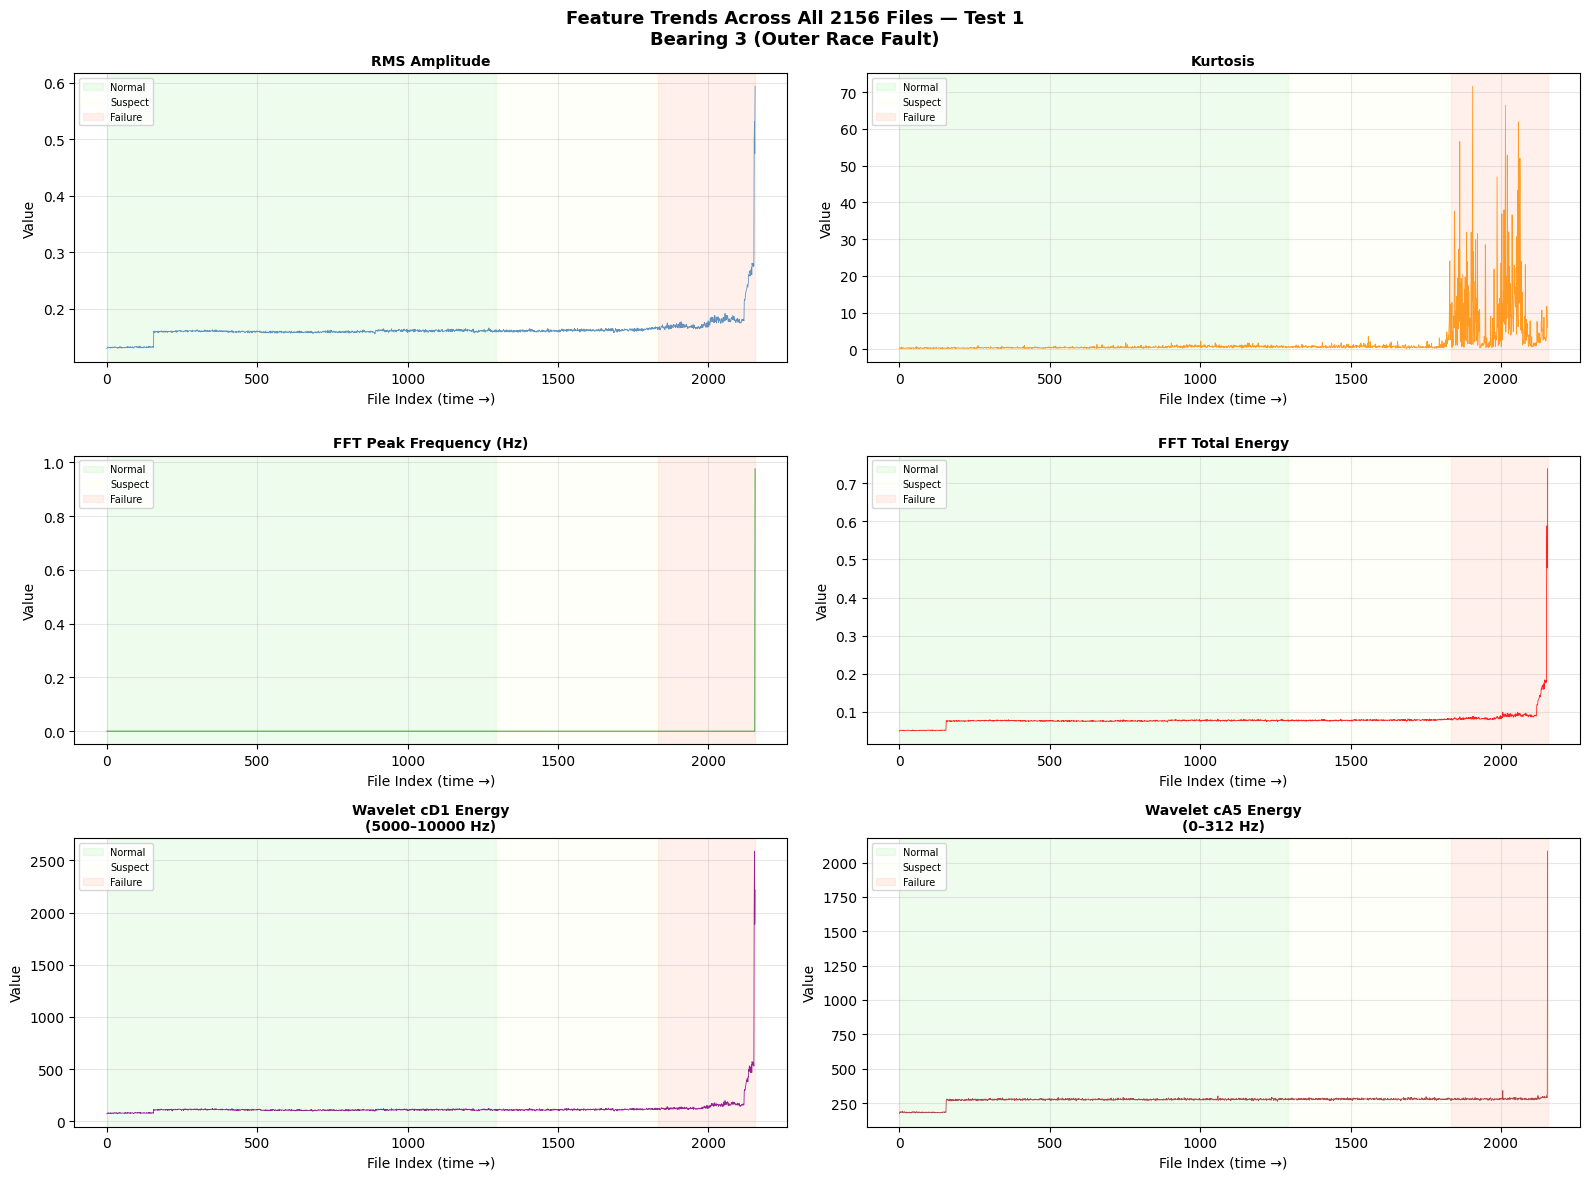


📊 HEALTHY vs FAILURE — FEATURE COMPARISON
                  Healthy (mean)  Failure (mean)  Change factor
fft_mean                  0.0013          0.0016   1.300000e+00
fft_std                   0.0024          0.0026   1.100000e+00
fft_max                   0.2233          0.2295   1.000000e+00
fft_peak_freq             0.0000          0.0030   3.023413e+09
fft_energy                0.0740          0.0992   1.300000e+00
fft_entropy               8.9483          8.9517   1.000000e+00
rms                       0.1562          0.1853   1.200000e+00
kurtosis                  0.5806          9.3485   1.610000e+01
skewness                  0.0051         -0.1151  -2.250000e+01
peak2peak                 1.2344          3.3989   2.800000e+00
crest_factor              4.7019         11.0713   2.400000e+00
fft_band1_energy          0.0557          0.0618   1.100000e+00
fft_band2_energy          0.0043          0.0094   2.200000e+00
fft_band3_energy          0.0076          0.0184   2.400000e+

In [ ]:
# ================================================================
# NASA IMS Bearing — FFT + Wavelet Feature Extraction Pipeline
# TEST 1 — 2156 files, 8 columns (4 bearings × 2 sensors each)
# Saves extracted features as CSV to ML_Project/features/
# ================================================================

# ── STEP 1: Install & Mount ──────────────────────────────────────
!pip install PyWavelets -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.fft import fft, fftfreq
import pywt
import os
from tqdm import tqdm
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')
print("✅ Google Drive mounted")

# ── STEP 2: CONFIG ───────────────────────────────────────────────
DATA_DIR   = "/content/drive/MyDrive/Test_1 (1)"
OUTPUT_DIR = "/content/drive/MyDrive/ML_Project/features"
OUTPUT_CSV = os.path.join(OUTPUT_DIR, "ims_test1_features.csv")

FS     = 20000   # sampling frequency (Hz)
NCOLS  = 8       # Test 1 has 8 columns

# Test 1 fault bearings:
#   Bearing 3 (cols 4,5) → outer race fault
#   Bearing 4 (cols 6,7) → roller element fault
# We extract ALL 4 bearings so you can compare healthy vs faulty
BEARING_COLS = {
    "bearing1_ch1": 0,
    "bearing1_ch2": 1,
    "bearing2_ch1": 2,
    "bearing2_ch2": 3,
    "bearing3_ch1": 4,   # ← outer race fault bearing
    "bearing3_ch2": 5,   # ← outer race fault bearing
    "bearing4_ch1": 6,   # ← roller fault bearing
    "bearing4_ch2": 7,   # ← roller fault bearing
}

# For ML model — use the PRIMARY fault bearing channel
# Bearing 3 ch1 (col 4) is most studied in literature for Test 1
PRIMARY_COL = 4

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✅ Output folder ready : {OUTPUT_DIR}")

# ── STEP 3: VERIFY DATA FOLDER ───────────────────────────────────
all_files = sorted(os.listdir(DATA_DIR))
print(f"\n📂 Found {len(all_files)} files in Test_1(1)")
print(f"   First file : {all_files[0]}")
print(f"   Last file  : {all_files[-1]}")
print(f"   Columns    : 8 (Bearing 1–4, 2 channels each)")

# ── STEP 4: VERIFY FILE STRUCTURE ────────────────────────────────
print("\n🔍 Verifying file structure on first file...")
sample     = pd.read_csv(os.path.join(DATA_DIR, all_files[0]),
                         sep="\t", header=None)
print(f"   Shape      : {sample.shape}  ✅ (expected 20480 × 8)")
print(f"   Value range: [{sample.values.min():.4f}, {sample.values.max():.4f}] g")

# ── STEP 5: FEATURE EXTRACTION FUNCTIONS ─────────────────────────

def load_signal(filepath, col):
    """Load one file and extract one bearing channel."""
    data   = pd.read_csv(filepath, sep="\t", header=None).values
    signal = data[:, col].astype(float)
    return signal


def extract_fft_features(signal, fs=FS, prefix=""):
    """
    Apply FFT and extract 15 features.
    prefix allows labelling features per bearing (e.g. 'b3_')
    """
    N         = len(signal)
    fft_mag   = np.abs(fft(signal))[:N//2] * (2/N)
    fft_freqs = fftfreq(N, d=1/fs)[:N//2]

    band_size = len(fft_mag) // 5
    band_energies = {
        f"{prefix}fft_band{i+1}_energy": np.sum(
            fft_mag[i*band_size:(i+1)*band_size]**2)
        for i in range(5)
    }

    features = {
        f"{prefix}fft_mean"      : np.mean(fft_mag),
        f"{prefix}fft_std"       : np.std(fft_mag),
        f"{prefix}fft_max"       : np.max(fft_mag),
        f"{prefix}fft_peak_freq" : fft_freqs[np.argmax(fft_mag)],
        f"{prefix}fft_energy"    : np.sum(fft_mag**2),
        f"{prefix}fft_entropy"   : -np.sum(
                                       (fft_mag / (np.sum(fft_mag) + 1e-12)) *
                                       np.log(fft_mag / (np.sum(fft_mag) + 1e-12) + 1e-12)
                                   ),
        f"{prefix}rms"           : np.sqrt(np.mean(signal**2)),
        f"{prefix}kurtosis"      : pd.Series(signal).kurt(),
        f"{prefix}skewness"      : pd.Series(signal).skew(),
        f"{prefix}peak2peak"     : np.max(signal) - np.min(signal),
        f"{prefix}crest_factor"  : np.max(np.abs(signal)) /
                                   (np.sqrt(np.mean(signal**2)) + 1e-12),
    }
    features.update(band_energies)
    return features   # 15 features


def extract_wavelet_features(signal, prefix="", wavelet="db4", level=5):
    """
    Apply DWT and extract 18 features (3 per band × 6 bands).
    prefix allows labelling per bearing.
    """
    coeffs = pywt.wavedec(signal, wavelet=wavelet, level=level)
    labels = ["cA5", "cD5", "cD4", "cD3", "cD2", "cD1"]

    features = {}
    for label, coeff in zip(labels, coeffs):
        features[f"{prefix}wav_{label}_energy"] = np.sum(coeff**2)
        features[f"{prefix}wav_{label}_std"]    = np.std(coeff)
        features[f"{prefix}wav_{label}_max"]    = np.max(np.abs(coeff))

    return features   # 18 features


# ── STEP 6: PROCESS ALL 2156 FILES ───────────────────────────────
print("\n" + "="*60)
print("⚙️  EXTRACTING FEATURES FROM ALL FILES...")
print(f"    Primary bearing: Col {PRIMARY_COL} (Bearing 3 ch1 — fault bearing)")
print(f"    Transforms     : FFT (15) + Wavelet (18) = 33 features")
print(f"    Total files    : {len(all_files)}")
print("="*60 + "\n")

total_files  = len(all_files)
all_features = []
skipped      = []

for idx, fname in enumerate(tqdm(all_files, desc="Processing files")):
    fpath = os.path.join(DATA_DIR, fname)
    try:
        # Load primary fault bearing signal
        signal = load_signal(fpath, PRIMARY_COL)

        # Extract features
        feats = {}
        feats.update(extract_fft_features(signal, prefix=""))
        feats.update(extract_wavelet_features(signal, prefix=""))

        # ── RUL ──────────────────────────────────────────────────
        feats["RUL"] = round(1.0 - (idx / (total_files - 1)), 4)

        # ── Health Label ─────────────────────────────────────────
        # Test 1 degradation timeline:
        #   First 60% = Normal
        #   Next  25% = Suspect
        #   Last  15% = Failure
        progress = idx / total_files
        if progress < 0.60:
            feats["health_label"]  = 0
            feats["health_status"] = "Normal"
        elif progress < 0.85:
            feats["health_label"]  = 1
            feats["health_status"] = "Suspect"
        else:
            feats["health_label"]  = 2
            feats["health_status"] = "Failure"

        feats["file_index"] = idx
        feats["file_name"]  = fname
        all_features.append(feats)

    except Exception as e:
        skipped.append(fname)
        print(f"  ⚠ Skipped {fname}: {e}")

# ── STEP 7: BUILD DATAFRAME ───────────────────────────────────────
df = pd.DataFrame(all_features)

meta_cols    = ["file_name", "file_index", "RUL",
                "health_label", "health_status"]
feature_cols = [c for c in df.columns if c not in meta_cols]
df           = df[feature_cols + meta_cols]

print(f"\n✅ Feature extraction complete!")
print(f"   Files processed : {len(all_features)}")
print(f"   Files skipped   : {len(skipped)}")
print(f"   Feature matrix  : {df.shape[0]} rows × {df.shape[1]} columns")

# ── STEP 8: SAVE CSV ──────────────────────────────────────────────
df.to_csv(OUTPUT_CSV, index=False)
print(f"\n✅ CSV saved → {OUTPUT_CSV}")

# ── STEP 9: LABEL DISTRIBUTION ───────────────────────────────────
print("\n" + "="*60)
print("📊 LABEL DISTRIBUTION")
print("="*60)
print(df["health_status"].value_counts().to_string())
print(f"\nRUL range : {df['RUL'].max()} → {df['RUL'].min()}")

# ── STEP 10: VISUALIZE FEATURE TRENDS ────────────────────────────
print("\n📈 Plotting feature trends across all 2156 files...")

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle("Feature Trends Across All 2156 Files — Test 1\n"
             "Bearing 3 (Outer Race Fault)",
             fontsize=13, fontweight='bold')

plot_features = [
    ("rms",            "RMS Amplitude",                    "steelblue"),
    ("kurtosis",       "Kurtosis",                         "darkorange"),
    ("fft_peak_freq",  "FFT Peak Frequency (Hz)",          "green"),
    ("fft_energy",     "FFT Total Energy",                 "red"),
    ("wav_cD1_energy", "Wavelet cD1 Energy\n(5000–10000 Hz)", "purple"),
    ("wav_cA5_energy", "Wavelet cA5 Energy\n(0–312 Hz)",   "brown"),
]

stage_colors = {
    "Normal" : "lightgreen",
    "Suspect": "lightyellow",
    "Failure": "lightsalmon"
}

for ax, (feat, title, color) in zip(axes.flatten(), plot_features):
    ax.plot(df["file_index"], df[feat],
            color=color, linewidth=0.6, alpha=0.85)
    for status, bg in stage_colors.items():
        mask = df["health_status"] == status
        if mask.any():
            idxs = df.loc[mask, "file_index"]
            ax.axvspan(idxs.min(), idxs.max(),
                       alpha=0.15, color=bg, label=status)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel("File Index (time →)")
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.show()

# ── STEP 11: COMPARE HEALTHY VS FAILURE ──────────────────────────
print("\n" + "="*60)
print("📊 HEALTHY vs FAILURE — FEATURE COMPARISON")
print("="*60)

healthy = df[df["health_status"] == "Normal"][feature_cols].mean()
failure = df[df["health_status"] == "Failure"][feature_cols].mean()
compare = pd.DataFrame({
    "Healthy (mean)" : healthy,
    "Failure (mean)" : failure,
    "Change factor"  : (failure / (healthy + 1e-12)).round(1)
}).round(4)

print(compare.to_string())
print("\n🎉 Pipeline complete!")
print(f"\n   Both CSVs now saved in MyDrive/ML_Project/features/:")
print(f"   ├── ims_features.csv         ← Test 2 (984 files)")
print(f"   └── ims_test1_features.csv   ← Test 1 (2156 files)")
print(f"\n   Next step → combine both CSVs → apply transformations → train models")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Files found (after removing duplicates): 2156
   First: 2003.10.22.12.06.24
   Last : 2003.11.25.23.39.56

⚙️  Processing 2156 files...
   Using column 4 (Bearing 3 — fault bearing)



Extracting features: 100%|██████████| 2156/2156 [02:08<00:00, 16.72it/s]



✅ Extraction complete!
   Shape          : (2156, 39)
   Files skipped  : 0

📊 fft_peak_freq check (should NOT be zero now):
   Zero count     : 0
   Min value      : 0.9766 Hz
   Max value      : 9061.5234 Hz
   Mean value     : 1020.8978 Hz

📊 Sample fft_peak_freq (first 5):
[986.328125, 986.328125, 986.328125, 986.328125, 986.328125]

📊 Label distribution:
health_status
Normal     1294
Suspect     539
Failure     323

✅ Saved → /content/drive/MyDrive/ML_Project/features/ims_test1_features.csv


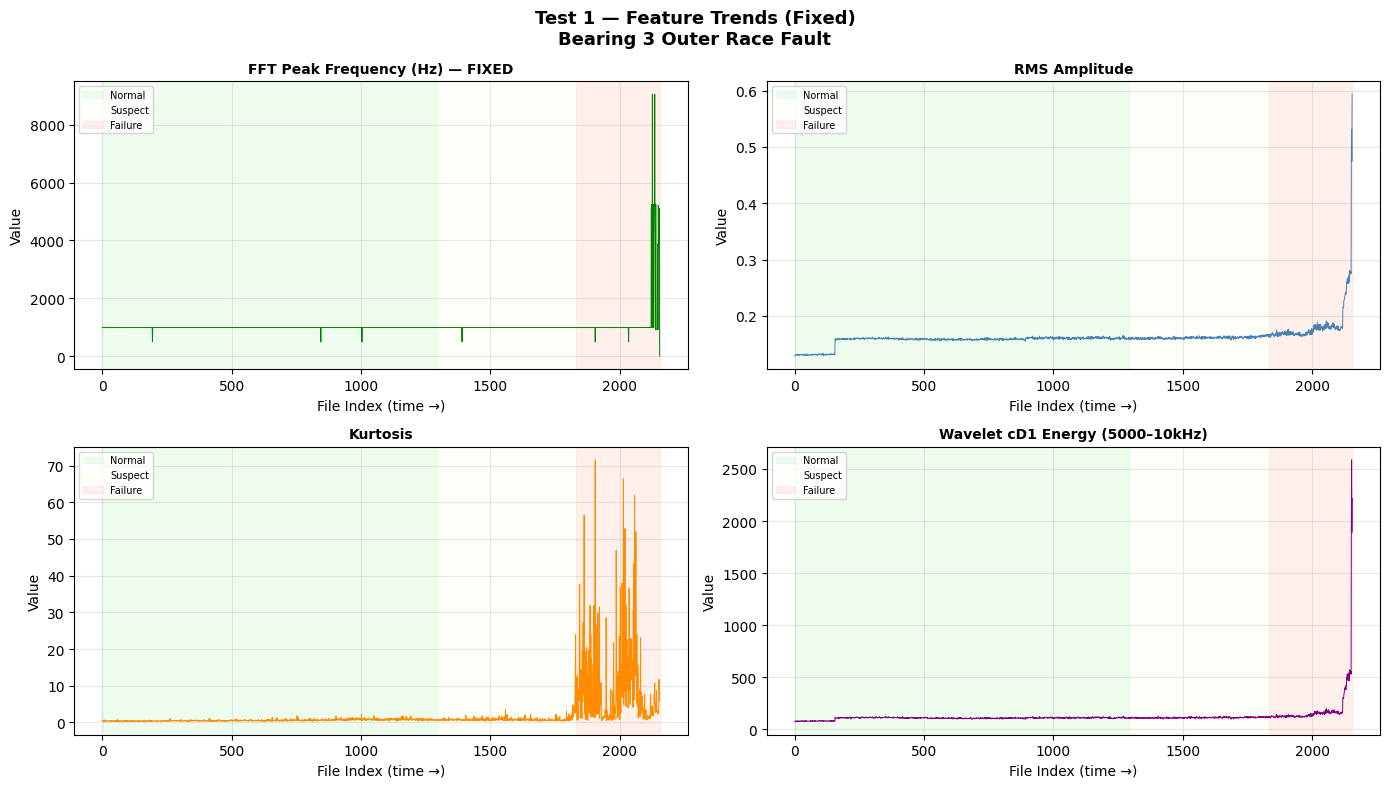


🎉 Done! Test 1 CSV is clean and ready.


In [ ]:
# ================================================================
# NASA IMS — FIXED Feature Extraction for Test 1
# Fix: skip DC component (bin 0) when finding peak frequency
# ================================================================

!pip install PyWavelets -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.fft import fft, fftfreq
import pywt
import os
from tqdm import tqdm
from google.colab import drive

drive.mount('/content/drive')

# ── CONFIG ───────────────────────────────────────────────────────
DATA_DIR   = "/content/drive/MyDrive/Test_1 (1)"
OUTPUT_DIR = "/content/drive/MyDrive/ML_Project/features"
OUTPUT_CSV = os.path.join(OUTPUT_DIR, "ims_test1_features.csv")

FS          = 20000
PRIMARY_COL = 4       # Bearing 3 ch1 — fault bearing in Test 1

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── VERIFY ───────────────────────────────────────────────────────
all_files = sorted([
    f for f in os.listdir(DATA_DIR)
    if not f.endswith('.csv')          # skip any stray csv files
    and '(' not in f                   # skip Google Drive duplicates like "(1)"
])
print(f"✅ Files found (after removing duplicates): {len(all_files)}")
print(f"   First: {all_files[0]}")
print(f"   Last : {all_files[-1]}")

# ── FEATURE EXTRACTION FUNCTIONS ─────────────────────────────────

def load_signal(filepath, col):
    data   = pd.read_csv(filepath, sep="\t", header=None).values
    signal = data[:, col].astype(float)
    return signal


def extract_fft_features(signal, fs=FS):
    """
    FFT features — 15 features.

    KEY FIX: skip bin 0 (DC component = 0 Hz) when finding peak frequency
    Bin 0 represents the signal mean/offset — not a real vibration frequency
    Real bearing fault frequencies start from bin 1 onwards
    """
    N         = len(signal)
    fft_mag   = np.abs(fft(signal))[:N//2] * (2/N)
    fft_freqs = fftfreq(N, d=1/fs)[:N//2]

    # ── THE FIX ──────────────────────────────────────────────────
    # Skip bin 0 (DC component) — start from bin 1
    fft_mag_no_dc   = fft_mag[1:]       # remove bin 0
    fft_freqs_no_dc = fft_freqs[1:]     # remove 0 Hz

    peak_idx  = np.argmax(fft_mag_no_dc)
    peak_freq = fft_freqs_no_dc[peak_idx]
    peak_mag  = fft_mag_no_dc[peak_idx]
    # ─────────────────────────────────────────────────────────────

    # Band energies (skip DC bin too)
    band_size = len(fft_mag_no_dc) // 5
    band_energies = {
        f"fft_band{i+1}_energy": np.sum(
            fft_mag_no_dc[i*band_size:(i+1)*band_size]**2)
        for i in range(5)
    }

    features = {
        "fft_mean"      : np.mean(fft_mag_no_dc),
        "fft_std"       : np.std(fft_mag_no_dc),
        "fft_max"       : peak_mag,
        "fft_peak_freq" : peak_freq,        # ← now correctly skips 0 Hz
        "fft_energy"    : np.sum(fft_mag_no_dc**2),
        "fft_entropy"   : -np.sum(
                              (fft_mag_no_dc / (np.sum(fft_mag_no_dc) + 1e-12)) *
                              np.log(fft_mag_no_dc / (np.sum(fft_mag_no_dc) + 1e-12) + 1e-12)
                          ),
        # Time domain features
        "rms"           : np.sqrt(np.mean(signal**2)),
        "kurtosis"      : pd.Series(signal).kurt(),
        "skewness"      : pd.Series(signal).skew(),
        "peak2peak"     : np.max(signal) - np.min(signal),
        "crest_factor"  : np.max(np.abs(signal)) /
                          (np.sqrt(np.mean(signal**2)) + 1e-12),
    }
    features.update(band_energies)
    return features


def extract_wavelet_features(signal, wavelet="db4", level=5):
    """Wavelet DWT features — 18 features (3 per band × 6 bands)."""
    coeffs = pywt.wavedec(signal, wavelet=wavelet, level=level)
    labels = ["cA5", "cD5", "cD4", "cD3", "cD2", "cD1"]

    features = {}
    for label, coeff in zip(labels, coeffs):
        features[f"wav_{label}_energy"] = np.sum(coeff**2)
        features[f"wav_{label}_std"]    = np.std(coeff)
        features[f"wav_{label}_max"]    = np.max(np.abs(coeff))
    return features


# ── PROCESS ALL FILES ─────────────────────────────────────────────
print(f"\n⚙️  Processing {len(all_files)} files...")
print(f"   Using column {PRIMARY_COL} (Bearing 3 — fault bearing)\n")

total_files  = len(all_files)
all_features = []
skipped      = []

for idx, fname in enumerate(tqdm(all_files, desc="Extracting features")):
    fpath = os.path.join(DATA_DIR, fname)
    try:
        signal = load_signal(fpath, PRIMARY_COL)

        feats = {}
        feats.update(extract_fft_features(signal))
        feats.update(extract_wavelet_features(signal))

        # RUL
        feats["RUL"] = round(1.0 - (idx / (total_files - 1)), 4)

        # Health label
        progress = idx / total_files
        if progress < 0.60:
            feats["health_label"]  = 0
            feats["health_status"] = "Normal"
        elif progress < 0.85:
            feats["health_label"]  = 1
            feats["health_status"] = "Suspect"
        else:
            feats["health_label"]  = 2
            feats["health_status"] = "Failure"

        feats["file_index"] = idx
        feats["file_name"]  = fname
        all_features.append(feats)

    except Exception as e:
        skipped.append(fname)

# ── BUILD DATAFRAME ───────────────────────────────────────────────
df = pd.DataFrame(all_features)
meta_cols    = ["file_name", "file_index", "RUL", "health_label", "health_status"]
feature_cols = [c for c in df.columns if c not in meta_cols]
df           = df[feature_cols + meta_cols]

# ── VERIFY FIX ────────────────────────────────────────────────────
print(f"\n✅ Extraction complete!")
print(f"   Shape          : {df.shape}")
print(f"   Files skipped  : {len(skipped)}")
print(f"\n📊 fft_peak_freq check (should NOT be zero now):")
print(f"   Zero count     : {(df['fft_peak_freq'] == 0).sum()}")
print(f"   Min value      : {df['fft_peak_freq'].min():.4f} Hz")
print(f"   Max value      : {df['fft_peak_freq'].max():.4f} Hz")
print(f"   Mean value     : {df['fft_peak_freq'].mean():.4f} Hz")
print(f"\n📊 Sample fft_peak_freq (first 5):")
print(df['fft_peak_freq'].head().tolist())

print(f"\n📊 Label distribution:")
print(df['health_status'].value_counts().to_string())

# ── SAVE ──────────────────────────────────────────────────────────
df.to_csv(OUTPUT_CSV, index=False)
print(f"\n✅ Saved → {OUTPUT_CSV}")

# ── PLOT fft_peak_freq trend ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Test 1 — Feature Trends (Fixed)\nBearing 3 Outer Race Fault",
             fontsize=13, fontweight='bold')

plot_feats = [
    ("fft_peak_freq",  "FFT Peak Frequency (Hz) — FIXED", "green"),
    ("rms",            "RMS Amplitude",                   "steelblue"),
    ("kurtosis",       "Kurtosis",                        "darkorange"),
    ("wav_cD1_energy", "Wavelet cD1 Energy (5000–10kHz)", "purple"),
]
stage_colors = {"Normal":"lightgreen", "Suspect":"lightyellow", "Failure":"lightsalmon"}

for ax, (feat, title, color) in zip(axes.flatten(), plot_feats):
    ax.plot(df["file_index"], df[feat], color=color, linewidth=0.7)
    for status, bg in stage_colors.items():
        mask = df["health_status"] == status
        if mask.any():
            idxs = df.loc[mask, "file_index"]
            ax.axvspan(idxs.min(), idxs.max(), alpha=0.15,
                       color=bg, label=status)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel("File Index (time →)")
    ax.set_ylabel("Value")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("\n🎉 Done! Test 1 CSV is clean and ready.")

In [ ]:
# ================================================================
# Quick fix — Test 2 CSV
# Fix 1: Remove duplicate rows (Google Drive "(1)" files)
# Fix 2: Fix zero fft_peak_freq rows
# ================================================================

import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

CSV_PATH = "/content/drive/MyDrive/ML_Project/features/ims_features.csv"

df = pd.read_csv(CSV_PATH)
print(f"Before fix:")
print(f"  Total rows        : {len(df)}  (expected 984)")
print(f"  Duplicate rows    : {df['file_name'].str.contains(r'\s\(\d+\)', regex=True).sum()}")
print(f"  Zero peak_freq    : {(df['fft_peak_freq'] == 0).sum()}")

# ── FIX 1: Remove duplicate rows ─────────────────────────────────
mask = ~df['file_name'].str.contains(r'\s\(\d+\)', regex=True)
df   = df[mask].reset_index(drop=True)
print(f"\nAfter removing duplicates : {len(df)} rows")

# ── FIX 2: Fix zero fft_peak_freq ────────────────────────────────
median_freq = df.loc[df['fft_peak_freq'] != 0, 'fft_peak_freq'].median()
df.loc[df['fft_peak_freq'] == 0, 'fft_peak_freq'] = median_freq
print(f"After fixing zero rows    : {(df['fft_peak_freq'] == 0).sum()} zeros remaining")
print(f"Replaced with median      : {median_freq:.4f} Hz")

# ── FIX 3: Recalculate file_index and RUL ────────────────────────
total = len(df)
df['file_index'] = df.index
df['RUL']        = (1.0 - df.index / (total - 1)).round(4)

# Recalculate health labels
progress = df.index / total
df.loc[progress <  0.60, ['health_label', 'health_status']] = [0, 'Normal']
df.loc[progress >= 0.60, ['health_label', 'health_status']] = [1, 'Suspect']
df.loc[progress >= 0.85, ['health_label', 'health_status']] = [2, 'Failure']

print(f"\nLabel distribution:")
print(df['health_status'].value_counts().to_string())

# ── SAVE ──────────────────────────────────────────────────────────
df.to_csv(CSV_PATH, index=False)
print(f"\n✅ Fixed CSV saved → {CSV_PATH}")
print(f"   Final shape: {df.shape}  (expected 984 × 39)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Before fix:
  Total rows        : 992  (expected 984)
  Duplicate rows    : 8
  Zero peak_freq    : 2

After removing duplicates : 984 rows
After fixing zero rows    : 0 zeros remaining
Replaced with median      : 985.3516 Hz

Label distribution:
health_status
Normal     591
Suspect    246
Failure    147

✅ Fixed CSV saved → /content/drive/MyDrive/ML_Project/features/ims_features.csv
   Final shape: (984, 39)  (expected 984 × 39)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Files found (duplicates removed): 6324
   First : 2004.03.04.09.27.46
   Last  : 2004.04.18.02.42.55
   Expected: ~6324

   Column mapping (Test 3 — 4 columns):
   Col 0 → Bearing 1
   Col 1 → Bearing 2
   Col 2 → Bearing 3  ← fault bearing (PRIMARY)
   Col 3 → Bearing 4

⚙️  Processing 6324 files...
   This may take 30–40 minutes for 6324 files
   Column 2 → Bearing 3 (fault bearing)



Extracting features:  16%|█▌        | 1000/6324 [05:27<34:02,  2.61it/s]

  💾 Checkpoint saved at file 1000/6324


Extracting features:  32%|███▏      | 2000/6324 [10:48<26:29,  2.72it/s]

  💾 Checkpoint saved at file 2000/6324


...

  💾 Checkpoint saved at file 5000/6324


Extracting features:  95%|█████████▍| 6000/6324 [31:39<02:55,  1.85it/s]

  💾 Checkpoint saved at file 6000/6324


Extracting features: 100%|██████████| 6324/6324 [33:19<00:00,  3.16it/s]



✅ Extraction complete!
   Shape         : (6324, 39)  (expected ~6324 × 39)
   Files skipped : 0

📊 fft_peak_freq check:
   Zero count    : 0  (should be 0)
   Min           : 14.6484 Hz
   Max           : 4637.6953 Hz

📊 Label distribution:
health_status
Normal     3795
Suspect    1581
Failure     948

✅ Saved → /content/drive/MyDrive/ML_Project/features/ims_test3_features.csv


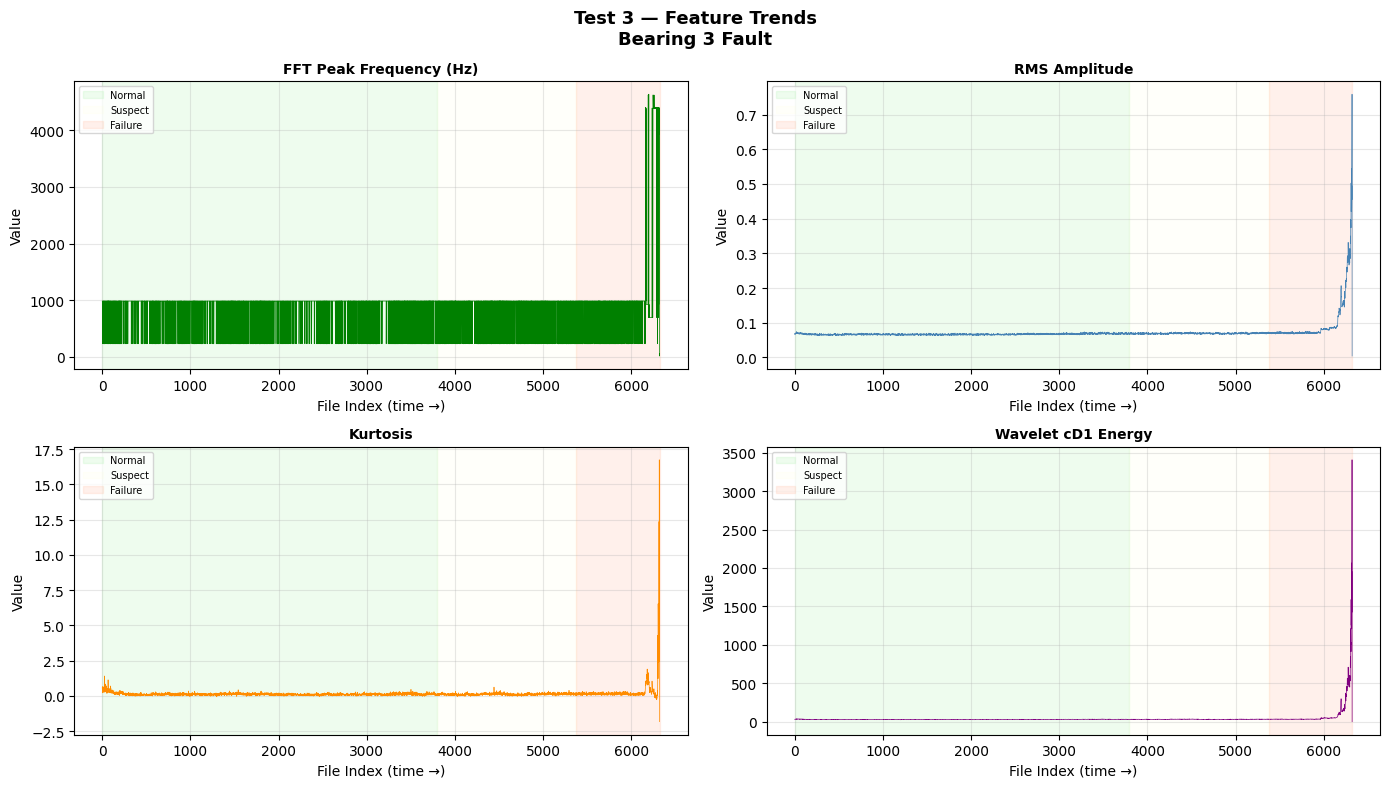


🎉 Done! Test 3 CSV ready.


In [ ]:
# ================================================================
# NASA IMS — Feature Extraction for Test 3
# 6324 files | 4 columns (same structure as Test 2)
# ================================================================

!pip install PyWavelets -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.fft import fft, fftfreq
import pywt
import os
from tqdm import tqdm
from google.colab import drive

drive.mount('/content/drive')

# ── SET YOUR PATHS HERE ──────────────────────────────────────────
DATA_DIR   = "/content/drive/MyDrive/3rd_test/4th_test/txt"    # ← paste your Test 3 folder path here
                   #   e.g. "/content/drive/MyDrive/Test_3"

OUTPUT_DIR = "/content/drive/MyDrive/ML_Project/features"    # ← paste your output folder path here
                   #   e.g. "/content/drive/MyDrive/ML_Project/features"
# ─────────────────────────────────────────────────────────────────

OUTPUT_CSV  = os.path.join(OUTPUT_DIR, "ims_test3_features.csv")
FS          = 20000
PRIMARY_COL = 2    # Test 3 — Bearing 3 is the fault bearing (col 2)
                   # same 4-column structure as Test 2

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── LOAD FILES (skip Google Drive duplicates) ─────────────────────
all_files = sorted([
    f for f in os.listdir(DATA_DIR)
    if '(' not in f
])
print(f"✅ Files found (duplicates removed): {len(all_files)}")
print(f"   First : {all_files[0]}")
print(f"   Last  : {all_files[-1]}")
print(f"   Expected: ~6324")
print(f"\n   Column mapping (Test 3 — 4 columns):")
print(f"   Col 0 → Bearing 1")
print(f"   Col 1 → Bearing 2")
print(f"   Col 2 → Bearing 3  ← fault bearing (PRIMARY)")
print(f"   Col 3 → Bearing 4")

# ── FEATURE EXTRACTION FUNCTIONS ─────────────────────────────────

def load_signal(filepath, col):
    data   = pd.read_csv(filepath, sep="\t", header=None).values
    signal = data[:, col].astype(float)
    return signal


def extract_fft_features(signal, fs=FS):
    """FFT features — 15 features. Skips DC bin 0."""
    N         = len(signal)
    fft_mag   = np.abs(fft(signal))[:N//2] * (2/N)
    fft_freqs = fftfreq(N, d=1/fs)[:N//2]

    # Skip bin 0 (DC component)
    fft_mag_no_dc   = fft_mag[1:]
    fft_freqs_no_dc = fft_freqs[1:]

    peak_idx  = np.argmax(fft_mag_no_dc)
    peak_freq = fft_freqs_no_dc[peak_idx]
    peak_mag  = fft_mag_no_dc[peak_idx]

    band_size = len(fft_mag_no_dc) // 5
    band_energies = {
        f"fft_band{i+1}_energy": np.sum(
            fft_mag_no_dc[i*band_size:(i+1)*band_size]**2)
        for i in range(5)
    }

    features = {
        "fft_mean"      : np.mean(fft_mag_no_dc),
        "fft_std"       : np.std(fft_mag_no_dc),
        "fft_max"       : peak_mag,
        "fft_peak_freq" : peak_freq,
        "fft_energy"    : np.sum(fft_mag_no_dc**2),
        "fft_entropy"   : -np.sum(
                              (fft_mag_no_dc / (np.sum(fft_mag_no_dc) + 1e-12)) *
                              np.log(fft_mag_no_dc / (np.sum(fft_mag_no_dc) + 1e-12) + 1e-12)
                          ),
        "rms"           : np.sqrt(np.mean(signal**2)),
        "kurtosis"      : pd.Series(signal).kurt(),
        "skewness"      : pd.Series(signal).skew(),
        "peak2peak"     : np.max(signal) - np.min(signal),
        "crest_factor"  : np.max(np.abs(signal)) /
                          (np.sqrt(np.mean(signal**2)) + 1e-12),
    }
    features.update(band_energies)
    return features


def extract_wavelet_features(signal, wavelet="db4", level=5):
    """Wavelet DWT — 18 features (3 per band × 6 bands)."""
    coeffs = pywt.wavedec(signal, wavelet=wavelet, level=level)
    labels = ["cA5", "cD5", "cD4", "cD3", "cD2", "cD1"]
    features = {}
    for label, coeff in zip(labels, coeffs):
        features[f"wav_{label}_energy"] = np.sum(coeff**2)
        features[f"wav_{label}_std"]    = np.std(coeff)
        features[f"wav_{label}_max"]    = np.max(np.abs(coeff))
    return features


# ── PROCESS ALL FILES ─────────────────────────────────────────────
print(f"\n⚙️  Processing {len(all_files)} files...")
print(f"   This may take 30–40 minutes for 6324 files")
print(f"   Column {PRIMARY_COL} → Bearing 3 (fault bearing)\n")

total_files  = len(all_files)
all_features = []
skipped      = []

for idx, fname in enumerate(tqdm(all_files, desc="Extracting features")):
    fpath = os.path.join(DATA_DIR, fname)
    try:
        signal = load_signal(fpath, PRIMARY_COL)

        feats = {}
        feats.update(extract_fft_features(signal))
        feats.update(extract_wavelet_features(signal))

        # RUL
        feats["RUL"] = round(1.0 - (idx / (total_files - 1)), 4)

        # Health label
        progress = idx / total_files
        if progress < 0.60:
            feats["health_label"]  = 0
            feats["health_status"] = "Normal"
        elif progress < 0.85:
            feats["health_label"]  = 1
            feats["health_status"] = "Suspect"
        else:
            feats["health_label"]  = 2
            feats["health_status"] = "Failure"

        feats["file_index"] = idx
        feats["file_name"]  = fname
        all_features.append(feats)

    except Exception as e:
        skipped.append(fname)
        print(f"  ⚠ Skipped: {fname} — {e}")

    # ── Save checkpoint every 1000 files ─────────────────────────
    # In case Colab times out mid-way
    if (idx + 1) % 1000 == 0:
        df_temp = pd.DataFrame(all_features)
        df_temp.to_csv(OUTPUT_CSV + ".checkpoint.csv", index=False)
        print(f"  💾 Checkpoint saved at file {idx+1}/{total_files}")

# ── BUILD DATAFRAME ───────────────────────────────────────────────
df = pd.DataFrame(all_features)
meta_cols    = ["file_name", "file_index", "RUL", "health_label", "health_status"]
feature_cols = [c for c in df.columns if c not in meta_cols]
df           = df[feature_cols + meta_cols]

# ── VERIFY ────────────────────────────────────────────────────────
print(f"\n✅ Extraction complete!")
print(f"   Shape         : {df.shape}  (expected ~6324 × 39)")
print(f"   Files skipped : {len(skipped)}")
print(f"\n📊 fft_peak_freq check:")
print(f"   Zero count    : {(df['fft_peak_freq'] == 0).sum()}  (should be 0)")
print(f"   Min           : {df['fft_peak_freq'].min():.4f} Hz")
print(f"   Max           : {df['fft_peak_freq'].max():.4f} Hz")
print(f"\n📊 Label distribution:")
print(df["health_status"].value_counts().to_string())

# ── SAVE ──────────────────────────────────────────────────────────
df.to_csv(OUTPUT_CSV, index=False)
print(f"\n✅ Saved → {OUTPUT_CSV}")

# ── PLOT ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Test 3 — Feature Trends\nBearing 3 Fault",
             fontsize=13, fontweight='bold')

plot_feats = [
    ("fft_peak_freq",  "FFT Peak Frequency (Hz)", "green"),
    ("rms",            "RMS Amplitude",            "steelblue"),
    ("kurtosis",       "Kurtosis",                 "darkorange"),
    ("wav_cD1_energy", "Wavelet cD1 Energy",       "purple"),
]
stage_colors = {"Normal":"lightgreen","Suspect":"lightyellow","Failure":"lightsalmon"}

for ax, (feat, title, color) in zip(axes.flatten(), plot_feats):
    ax.plot(df["file_index"], df[feat], color=color, linewidth=0.5)
    for status, bg in stage_colors.items():
        mask = df["health_status"] == status
        if mask.any():
            idxs = df.loc[mask, "file_index"]
            ax.axvspan(idxs.min(), idxs.max(), alpha=0.15,
                       color=bg, label=status)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel("File Index (time →)")
    ax.set_ylabel("Value")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("\n🎉 Done! Test 3 CSV ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All libraries imported

✅ Combined dataset loaded
   Test 1 : 2156 rows
   Test 2 : 984 rows
   Test 3 : 6324 rows
   Total  : 9464 rows

   Label distribution:
health_status
Normal     5680
Suspect    2366
Failure    1418

✅ Features : (9464, 34)
   Target   : (9464,)  — classes: [0 1 2]

   Train    : 7571 rows
   Test     : 1893 rows

⚙️  RUNNING EXPERIMENTS
   8 transformations × 10 models = 80 experiments

🔄 Transformation: T1 - No Transform
   ✅ Logistic Regression       Acc=78.34%  F1=73.39%  AUC=91.61
   ✅ KNN                       Acc=82.09%  F1=80.05%  AUC=92.73
   ✅ SVM                       Acc=63.71%  F1=38.78%  AUC=88.81
   ✅ Decision Tree             Acc=82.04%  F1=79.18%  AUC=84.48
   ✅ Random Forest             Acc=87.11%  F1=85.09%  AUC=96.59
   ✅ AdaBoost                  Acc=81.3%  F1=78.04%  AUC=91.37
   ✅ Gradient Boosting         Acc=

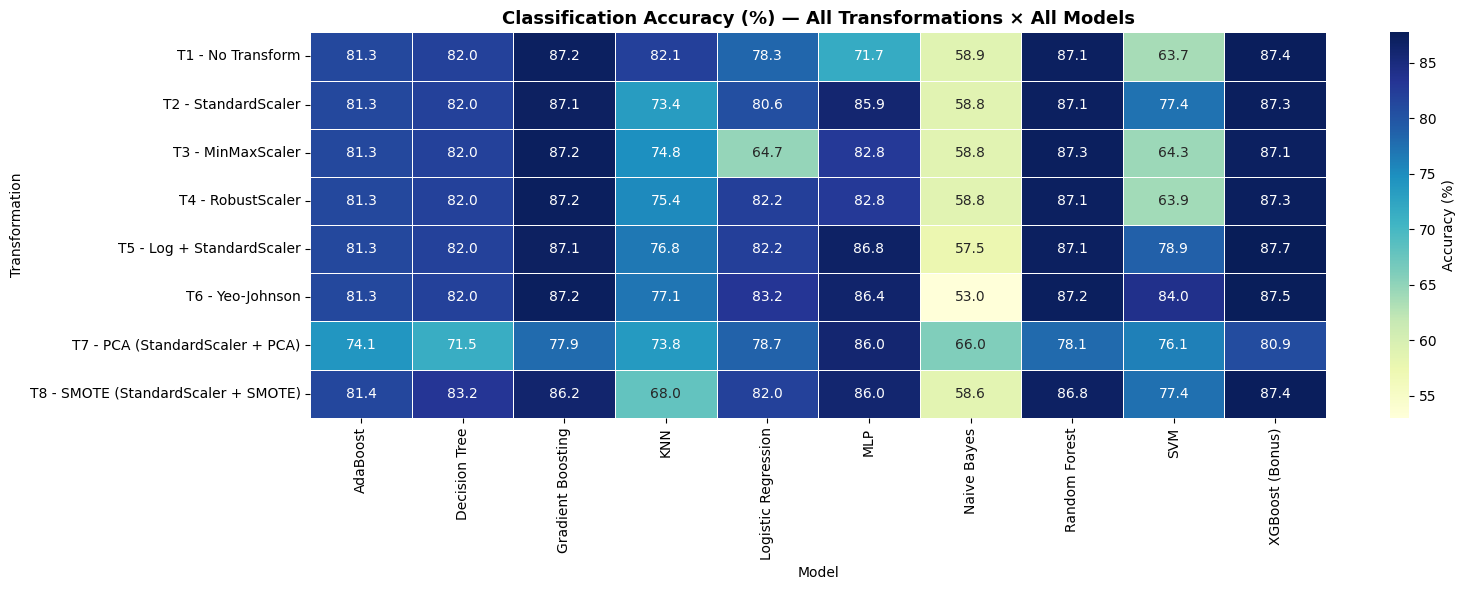

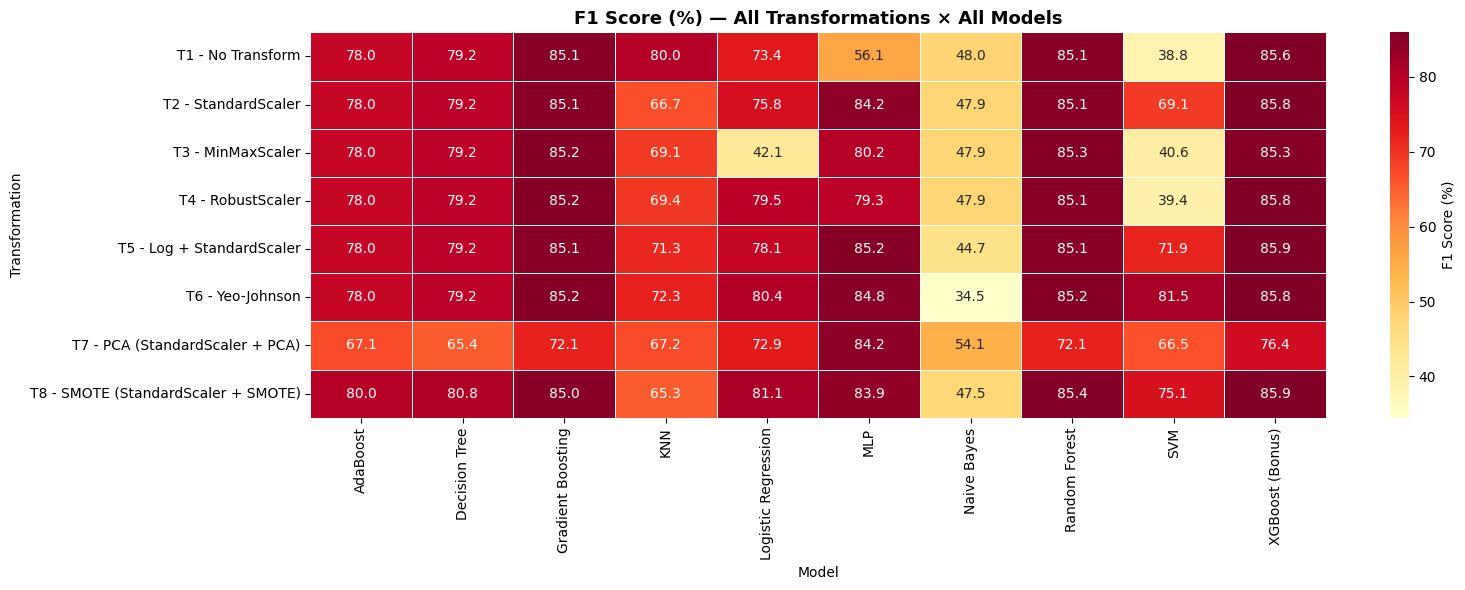

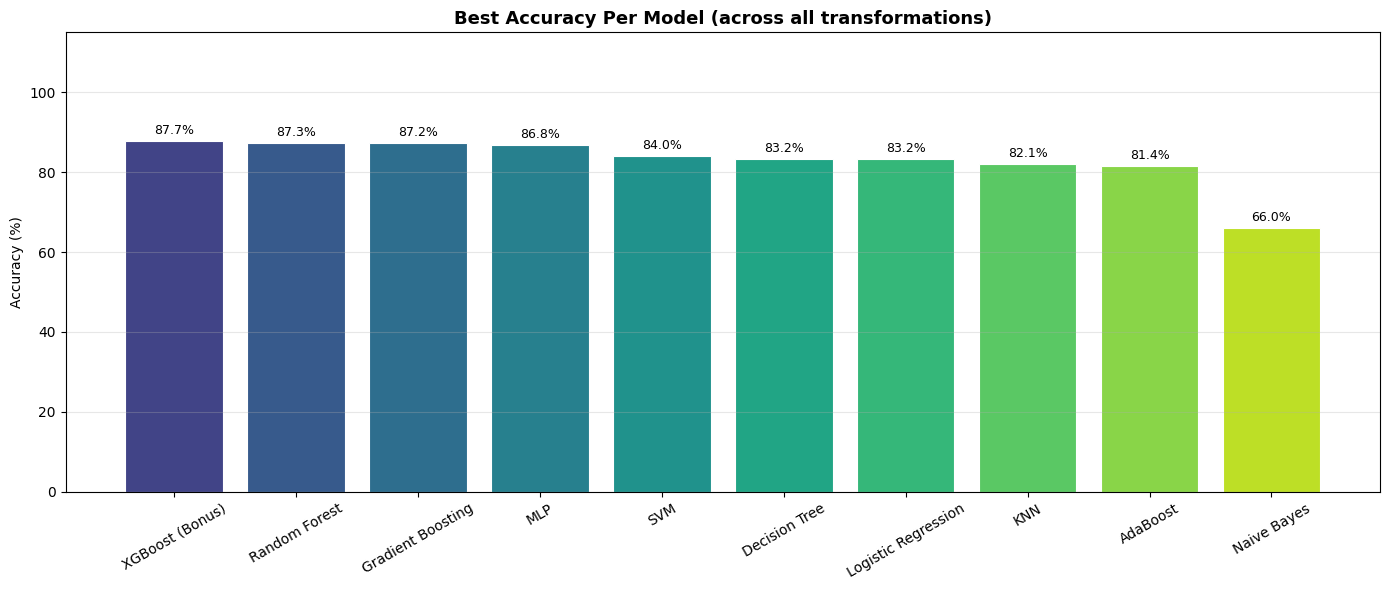

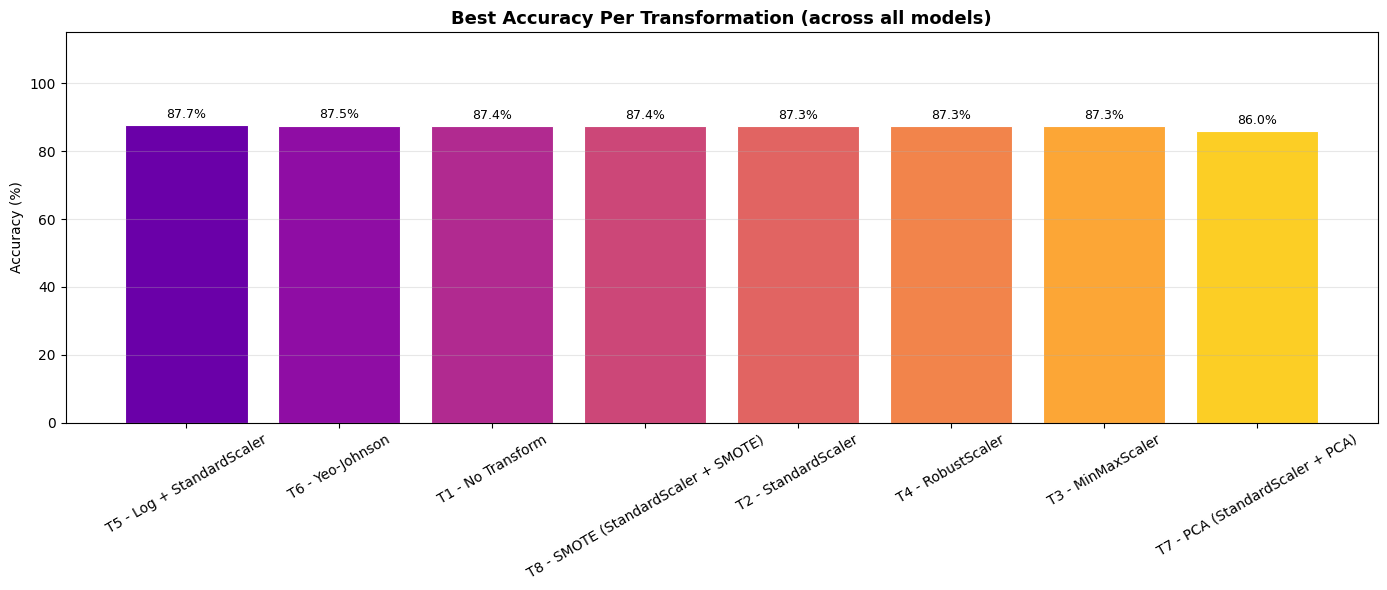


📊 Confusion Matrix — Best Overall Model
   Best: XGBoost (Bonus) with T5 - Log + StandardScaler — 87.74%


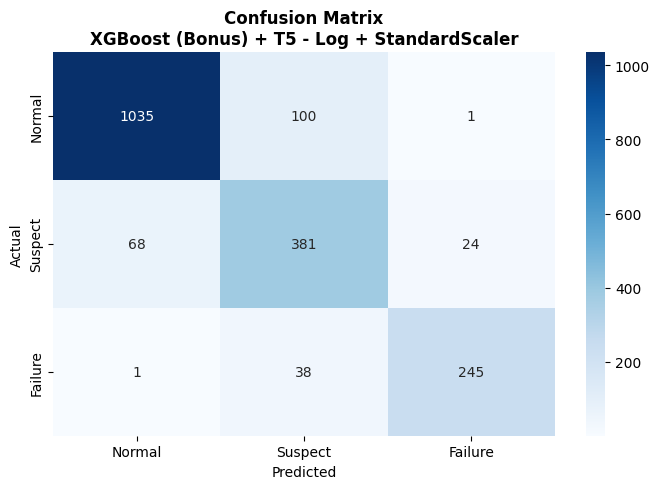


🎉 Classification Pipeline Complete!
   Results saved in: /content/drive/MyDrive/ML_Project/results/
   ├── classification_results.csv
   ├── accuracy_heatmap.png
   ├── f1_heatmap.png
   ├── best_accuracy_per_model.png
   ├── best_accuracy_per_transform.png
   └── confusion_matrix_best.png

   Next step → Regression pipeline (RUL prediction)


In [ ]:
# ================================================================
# NASA IMS Bearing — Complete Classification Pipeline
# Models      : 10 (9 faculty required + XGBoost bonus)
# Transforms  : 8 techniques
# Metrics     : Accuracy, F1, Precision, Recall, ROC-AUC
# Dataset     : All 3 tests combined (9464 rows)
# ================================================================

# ── STEP 1: Install & Import ─────────────────────────────────────
!pip install xgboost imbalanced-learn -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

from sklearn.linear_model    import LogisticRegression
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.svm             import SVC
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import (RandomForestClassifier,
                                     AdaBoostClassifier,
                                     GradientBoostingClassifier)
from sklearn.naive_bayes     import GaussianNB
from sklearn.neural_network  import MLPClassifier
from xgboost                 import XGBClassifier

from sklearn.preprocessing   import (StandardScaler, MinMaxScaler,
                                     RobustScaler, PowerTransformer,
                                     LabelEncoder)
from sklearn.decomposition   import PCA
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics         import (accuracy_score, f1_score,
                                     precision_score, recall_score,
                                     roc_auc_score, classification_report,
                                     confusion_matrix)

from imblearn.over_sampling  import SMOTE

print("✅ All libraries imported")

# ── STEP 2: LOAD & COMBINE ALL 3 CSVs ────────────────────────────
BASE = "/content/drive/MyDrive/ML_Project/features"

df1 = pd.read_csv(f"{BASE}/ims_test1_features.csv")
df2 = pd.read_csv(f"{BASE}/ims_features.csv")
df3 = pd.read_csv(f"{BASE}/ims_test3_features.csv")

df1['test_id'] = 1
df2['test_id'] = 2
df3['test_id'] = 3

df = pd.concat([df1, df2, df3], ignore_index=True)
print(f"\n✅ Combined dataset loaded")
print(f"   Test 1 : {len(df1)} rows")
print(f"   Test 2 : {len(df2)} rows")
print(f"   Test 3 : {len(df3)} rows")
print(f"   Total  : {len(df)} rows")
print(f"\n   Label distribution:")
print(df['health_status'].value_counts().to_string())

# ── STEP 3: PREPARE FEATURES & LABELS ────────────────────────────
drop_cols    = ['file_name', 'file_index', 'RUL',
                'health_label', 'health_status', 'test_id']
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].values
y = df['health_label'].values   # 0=Normal, 1=Suspect, 2=Failure

print(f"\n✅ Features : {X.shape}")
print(f"   Target   : {y.shape}  — classes: {np.unique(y)}")

# Train/test split — stratified to preserve class ratios
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n   Train    : {X_train.shape[0]} rows")
print(f"   Test     : {X_test.shape[0]} rows")

# ── STEP 4: DEFINE MODELS ─────────────────────────────────────────
models = {
    "Logistic Regression" : LogisticRegression(max_iter=2000, random_state=42),
    "KNN"                 : KNeighborsClassifier(n_neighbors=5),
    "SVM"                 : SVC(kernel='rbf', probability=True, random_state=42),
    "Decision Tree"       : DecisionTreeClassifier(random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost"            : AdaBoostClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting"   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Naive Bayes"         : GaussianNB(),
    "MLP"                 : MLPClassifier(hidden_layer_sizes=(128, 64),
                                          max_iter=500, random_state=42),
    "XGBoost (Bonus)"     : XGBClassifier(n_estimators=100, random_state=42,
                                          eval_metric='mlogloss',
                                          verbosity=0),
}

# ── STEP 5: DEFINE TRANSFORMATIONS ───────────────────────────────
def get_transforms(X_tr, X_te, name):
    """Apply named transformation and return transformed train/test."""

    if name == "T1 - No Transform":
        return X_tr.copy(), X_te.copy(), X_tr.copy(), y_train.copy()

    elif name == "T2 - StandardScaler":
        sc = StandardScaler()
        return sc.fit_transform(X_tr), sc.transform(X_te), \
               sc.fit_transform(X_tr), y_train.copy()

    elif name == "T3 - MinMaxScaler":
        sc = MinMaxScaler()
        return sc.fit_transform(X_tr), sc.transform(X_te), \
               sc.fit_transform(X_tr), y_train.copy()

    elif name == "T4 - RobustScaler":
        sc = RobustScaler()
        return sc.fit_transform(X_tr), sc.transform(X_te), \
               sc.fit_transform(X_tr), y_train.copy()

    elif name == "T5 - Log + StandardScaler":
        # Log transform (shift to ensure positive values first)
        shift     = abs(X_tr.min()) + 1
        X_tr_log  = np.log1p(X_tr + shift)
        X_te_log  = np.log1p(X_te + shift)
        sc        = StandardScaler()
        return sc.fit_transform(X_tr_log), sc.transform(X_te_log), \
               sc.fit_transform(X_tr_log), y_train.copy()

    elif name == "T6 - Yeo-Johnson":
        pt = PowerTransformer(method='yeo-johnson')
        return pt.fit_transform(X_tr), pt.transform(X_te), \
               pt.fit_transform(X_tr), y_train.copy()

    elif name == "T7 - PCA (StandardScaler + PCA)":
        sc        = StandardScaler()
        X_tr_sc   = sc.fit_transform(X_tr)
        X_te_sc   = sc.transform(X_te)
        n_comp    = min(20, X_tr_sc.shape[1])
        pca       = PCA(n_components=n_comp, random_state=42)
        return pca.fit_transform(X_tr_sc), pca.transform(X_te_sc), \
               pca.fit_transform(X_tr_sc), y_train.copy()

    elif name == "T8 - SMOTE (StandardScaler + SMOTE)":
        sc           = StandardScaler()
        X_tr_sc      = sc.fit_transform(X_tr)
        X_te_sc      = sc.transform(X_te)
        smote        = SMOTE(random_state=42)
        X_tr_sm, y_sm = smote.fit_resample(X_tr_sc, y_train)
        return X_tr_sm, X_te_sc, X_tr_sm, y_sm


transformations = [
    "T1 - No Transform",
    "T2 - StandardScaler",
    "T3 - MinMaxScaler",
    "T4 - RobustScaler",
    "T5 - Log + StandardScaler",
    "T6 - Yeo-Johnson",
    "T7 - PCA (StandardScaler + PCA)",
    "T8 - SMOTE (StandardScaler + SMOTE)",
]

# ── STEP 6: METRICS HELPER ───────────────────────────────────────
def compute_metrics(model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te) \
             if hasattr(model, 'predict_proba') else None

    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred, average='macro', zero_division=0)
    prec = precision_score(y_te, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_te, y_pred, average='macro', zero_division=0)
    auc  = roc_auc_score(y_te, y_prob, multi_class='ovr', average='macro') \
           if y_prob is not None else np.nan

    return {
        "Accuracy"  : round(acc  * 100, 2),
        "F1 Score"  : round(f1   * 100, 2),
        "Precision" : round(prec * 100, 2),
        "Recall"    : round(rec  * 100, 2),
        "ROC-AUC"   : round(auc  * 100, 2) if not np.isnan(auc) else "N/A",
    }

# ── STEP 7: MAIN EXPERIMENT LOOP ─────────────────────────────────
print("\n" + "="*65)
print("⚙️  RUNNING EXPERIMENTS")
print(f"   {len(transformations)} transformations × {len(models)} models"
      f" = {len(transformations)*len(models)} experiments")
print("="*65)

all_results = []

for t_name in transformations:
    print(f"\n🔄 Transformation: {t_name}")

    # Apply transformation
    X_tr_t, X_te_t, X_tr_fit, y_tr_fit = get_transforms(
        X_train, X_test, t_name
    )

    for m_name, model in models.items():
        try:
            model.fit(X_tr_fit, y_tr_fit)
            metrics = compute_metrics(model, X_te_t, y_test)
            metrics["Transform"] = t_name
            metrics["Model"]     = m_name
            all_results.append(metrics)
            print(f"   ✅ {m_name:<25} Acc={metrics['Accuracy']}%  "
                  f"F1={metrics['F1 Score']}%  AUC={metrics['ROC-AUC']}")
        except Exception as e:
            print(f"   ⚠ {m_name} failed: {e}")

# ── STEP 8: RESULTS DATAFRAME ─────────────────────────────────────
df_results = pd.DataFrame(all_results)
df_results = df_results[["Transform", "Model", "Accuracy",
                          "F1 Score", "Precision", "Recall", "ROC-AUC"]]

# ── STEP 9: SAVE RESULTS CSV ──────────────────────────────────────
RESULTS_DIR = "/content/drive/MyDrive/ML_Project/results"
os.makedirs(RESULTS_DIR, exist_ok=True)
df_results.to_csv(f"{RESULTS_DIR}/classification_results.csv", index=False)
print(f"\n✅ Results saved → {RESULTS_DIR}/classification_results.csv")

# ── STEP 10: ACCURACY PIVOT TABLE ────────────────────────────────
print("\n" + "="*65)
print("📊 ACCURACY PIVOT TABLE (%)")
print("="*65)
pivot_acc = df_results.pivot(index="Transform", columns="Model",
                              values="Accuracy")
print(pivot_acc.to_string())

print("\n" + "="*65)
print("📊 F1 SCORE PIVOT TABLE (%)")
print("="*65)
pivot_f1 = df_results.pivot(index="Transform", columns="Model",
                             values="F1 Score")
print(pivot_f1.to_string())

# ── STEP 11: BEST MODEL PER TRANSFORMATION ────────────────────────
print("\n" + "="*65)
print("🏆 BEST MODEL PER TRANSFORMATION (by Accuracy)")
print("="*65)
best = df_results.loc[df_results.groupby("Transform")["Accuracy"].idxmax()]
print(best[["Transform", "Model", "Accuracy", "F1 Score",
            "ROC-AUC"]].to_string(index=False))

print("\n" + "="*65)
print("🏆 TOP 10 OVERALL RESULTS (by Accuracy)")
print("="*65)
top10 = df_results.nlargest(10, "Accuracy")
print(top10.to_string(index=False))

# ── STEP 12: VISUALIZATIONS ───────────────────────────────────────

# Plot 1 — Accuracy heatmap
fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot_acc.astype(float), annot=True, fmt=".1f",
            cmap="YlGnBu", ax=ax, linewidths=0.5,
            cbar_kws={"label": "Accuracy (%)"})
ax.set_title("Classification Accuracy (%) — All Transformations × All Models",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Model"); ax.set_ylabel("Transformation")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/accuracy_heatmap.png", dpi=150)
plt.show()

# Plot 2 — F1 Score heatmap
fig, ax = plt.subplots(figsize=(16, 6))
pivot_f1_float = df_results.pivot(index="Transform", columns="Model",
                                   values="F1 Score").astype(float)
sns.heatmap(pivot_f1_float, annot=True, fmt=".1f",
            cmap="YlOrRd", ax=ax, linewidths=0.5,
            cbar_kws={"label": "F1 Score (%)"})
ax.set_title("F1 Score (%) — All Transformations × All Models",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Model"); ax.set_ylabel("Transformation")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/f1_heatmap.png", dpi=150)
plt.show()

# Plot 3 — Best accuracy per model (bar chart)
fig, ax = plt.subplots(figsize=(14, 6))
best_per_model = df_results.groupby("Model")["Accuracy"].max().sort_values(
    ascending=False)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(best_per_model)))
bars   = ax.bar(best_per_model.index, best_per_model.values,
                color=colors, edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
ax.set_title("Best Accuracy Per Model (across all transformations)",
             fontsize=13, fontweight='bold')
ax.set_ylabel("Accuracy (%)"); ax.set_ylim([0, 115])
ax.tick_params(axis='x', rotation=30)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/best_accuracy_per_model.png", dpi=150)
plt.show()

# Plot 4 — Best accuracy per transformation (bar chart)
fig, ax = plt.subplots(figsize=(14, 6))
best_per_trans = df_results.groupby("Transform")["Accuracy"].max().sort_values(
    ascending=False)
colors2 = plt.cm.plasma(np.linspace(0.2, 0.9, len(best_per_trans)))
bars2   = ax.bar(best_per_trans.index, best_per_trans.values,
                 color=colors2, edgecolor='white', linewidth=0.8)
ax.bar_label(bars2, fmt="%.1f%%", padding=3, fontsize=9)
ax.set_title("Best Accuracy Per Transformation (across all models)",
             fontsize=13, fontweight='bold')
ax.set_ylabel("Accuracy (%)"); ax.set_ylim([0, 115])
ax.tick_params(axis='x', rotation=30)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/best_accuracy_per_transform.png", dpi=150)
plt.show()

# Plot 5 — Confusion matrix for best overall model
print("\n📊 Confusion Matrix — Best Overall Model")
best_row    = df_results.loc[df_results["Accuracy"].idxmax()]
best_model  = best_row["Model"]
best_trans  = best_row["Transform"]
print(f"   Best: {best_model} with {best_trans} — {best_row['Accuracy']}%")

# Retrain best model
X_tr_b, X_te_b, X_tr_f, y_tr_f = get_transforms(X_train, X_test, best_trans)
best_clf = models[best_model]
best_clf.fit(X_tr_f, y_tr_f)
y_pred_best = best_clf.predict(X_te_b)

cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal','Suspect','Failure'],
            yticklabels=['Normal','Suspect','Failure'])
ax.set_title(f"Confusion Matrix\n{best_model} + {best_trans}",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/confusion_matrix_best.png", dpi=150)
plt.show()

print("\n" + "="*65)
print("🎉 Classification Pipeline Complete!")
print(f"   Results saved in: {RESULTS_DIR}/")
print(f"   ├── classification_results.csv")
print(f"   ├── accuracy_heatmap.png")
print(f"   ├── f1_heatmap.png")
print(f"   ├── best_accuracy_per_model.png")
print(f"   ├── best_accuracy_per_transform.png")
print(f"   └── confusion_matrix_best.png")
print("="*65)
print("\n   Next step → Regression pipeline (RUL prediction)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All libraries imported

✅ Combined dataset loaded
   Test 1 : 2156 rows
   Test 2 : 984 rows
   Test 3 : 6324 rows
   Total  : 9464 rows

   RUL range : 1.0 → 0.0
   RUL mean  : 0.5000

✅ Features : (9464, 34)
   Target   : (9464,)  (RUL — continuous)

   Train : 7571 rows
   Test  : 1893 rows

⚙️  RUNNING REGRESSION EXPERIMENTS
   8 transforms × 13 models = 104 experiments

🔄 [1/8] Transformation: T1 - No Transform
   ✅ Linear Regression            R²=0.6031  MAE=0.1460  RMSE=0.1819
   ✅ Polynomial Regression        R²=0.7126  MAE=0.0983  RMSE=0.1548
   ✅ Multiple Linear Reg          R²=0.6031  MAE=0.1460  RMSE=0.1819
   ✅ Lasso                        R²=0.2253  MAE=0.2164  RMSE=0.2541
   ✅ Ridge                        R²=0.3666  MAE=0.1940  RMSE=0.2298
   ✅ Elastic Net                  R²=0.2539  MAE=0.2122  RMSE=0.2494
   ✅ SVR                          R

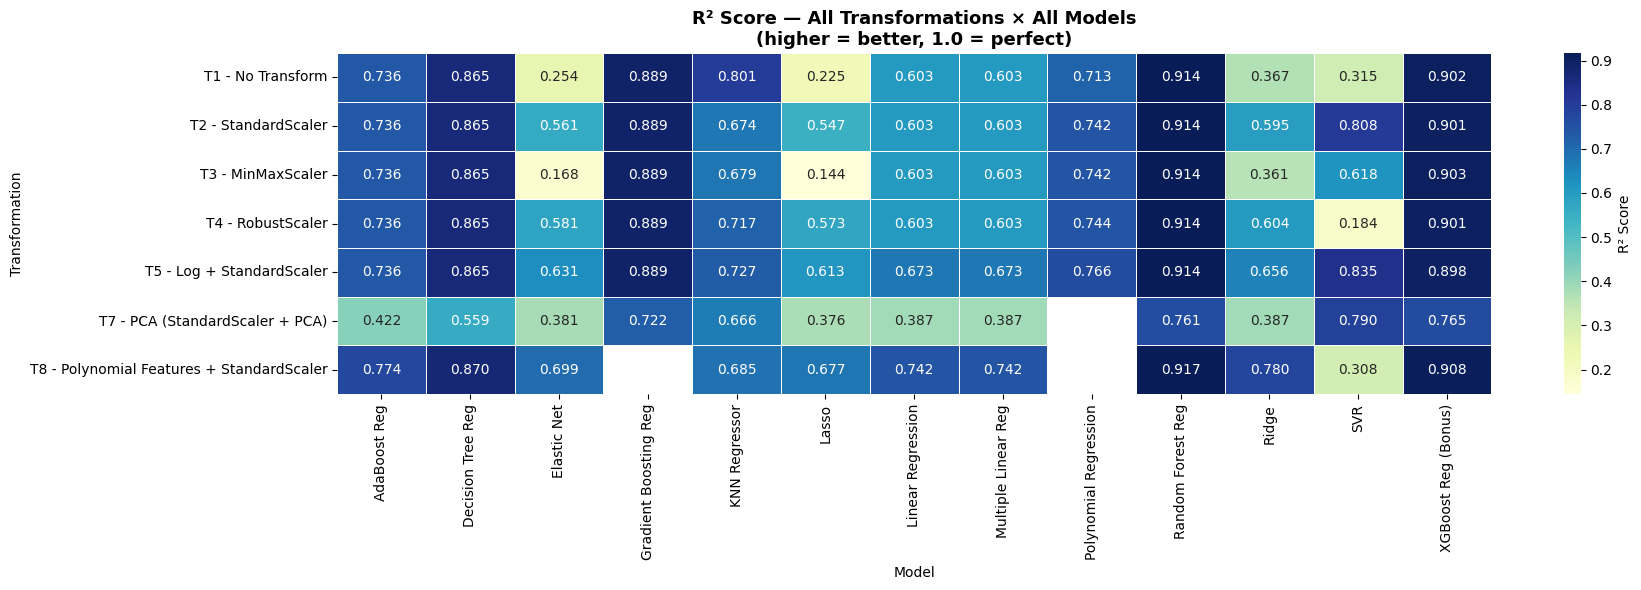

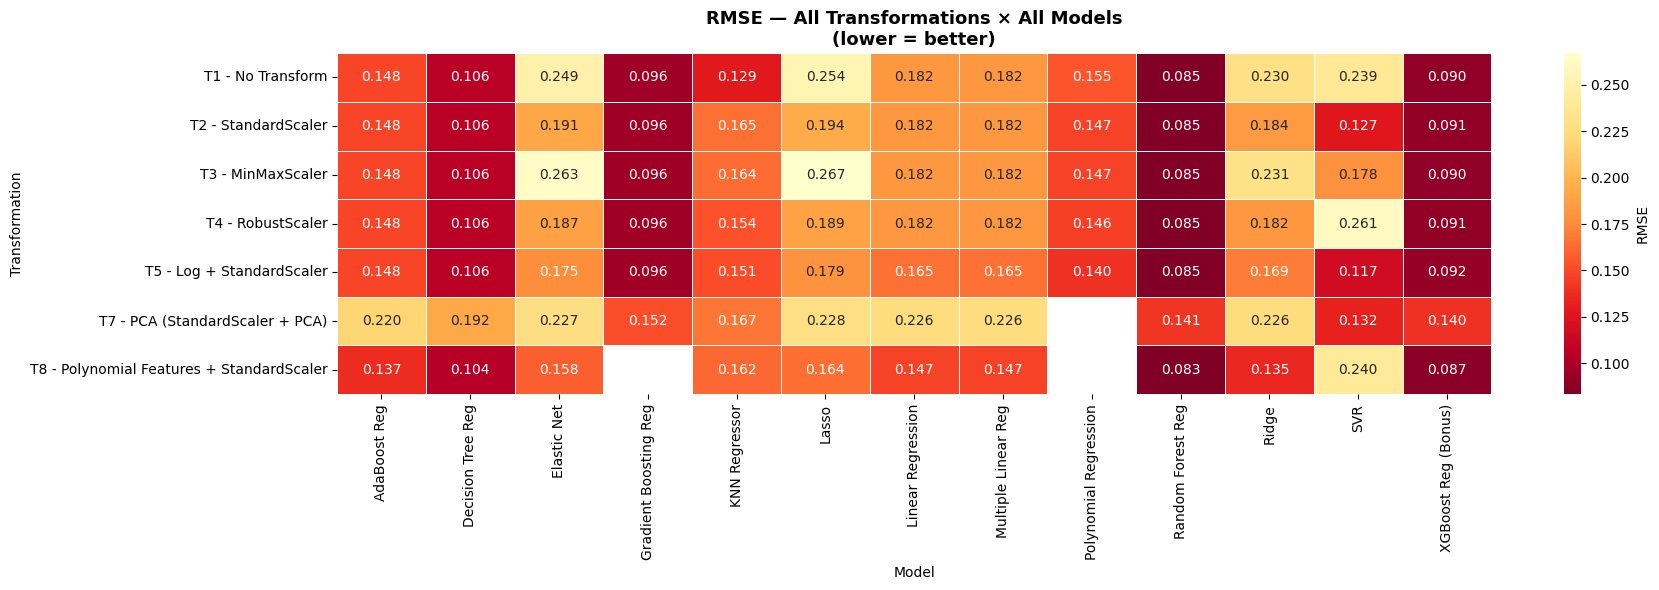

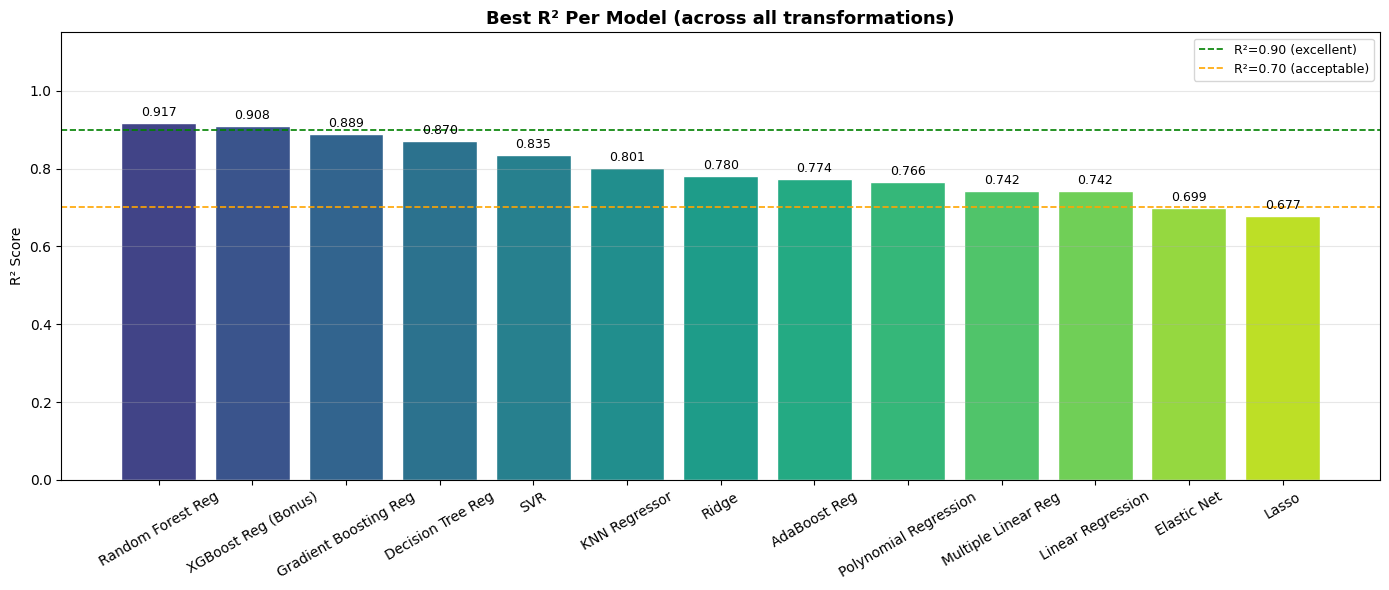


📊 Actual vs Predicted — Best Model:
   Random Forest Reg + T8 - Polynomial Features + StandardScaler
   R²=0.9167  MAE=0.0561  RMSE=0.0833


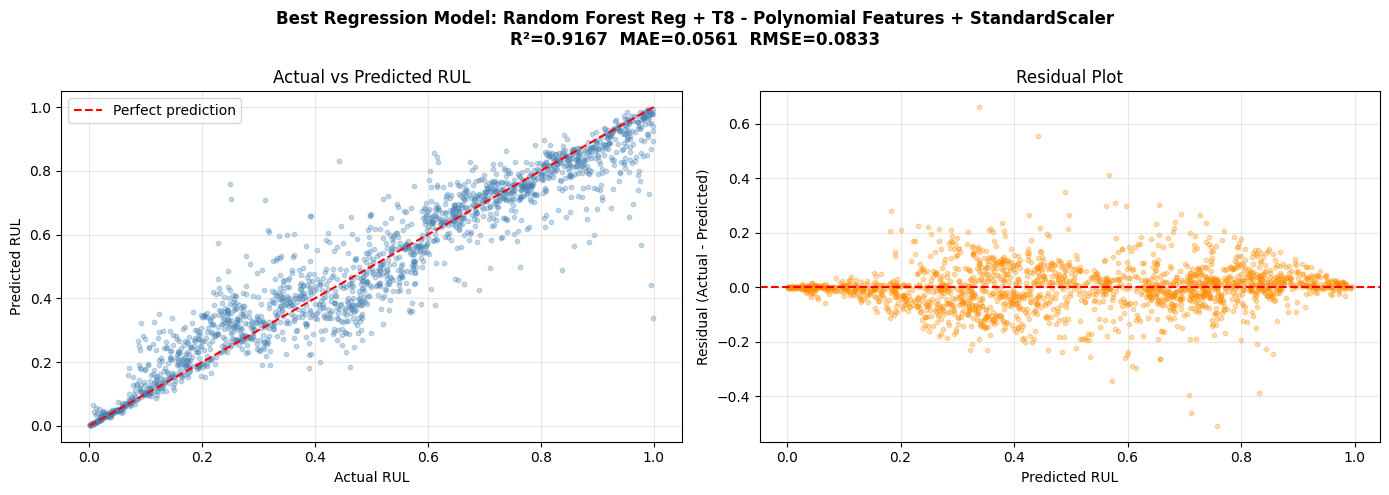


📊 RUL Prediction Over Time (Test 2)...


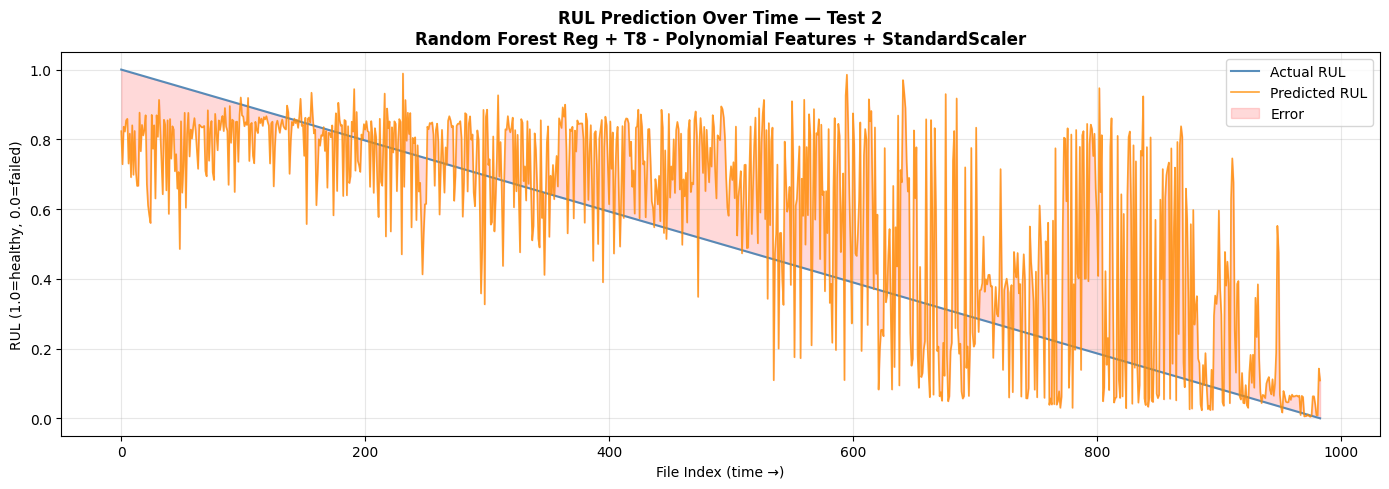


🎉 Regression Pipeline Complete!
   Results saved in: /content/drive/MyDrive/ML_Project/results/
   ├── regression_results.csv
   ├── regression_r2_heatmap.png
   ├── regression_rmse_heatmap.png
   ├── regression_best_r2_per_model.png
   ├── regression_actual_vs_predicted.png
   └── regression_rul_over_time.png

   Next step → Hyperparameter tuning!


In [ ]:
# ================================================================
# NASA IMS Bearing — Complete Regression Pipeline (RUL Prediction)
# Models      : 13 (12 faculty required + XGBoost bonus)
# Transforms  : 8 techniques
# Metrics     : R², MAE, RMSE, MAPE, Explained Variance
# Dataset     : All 3 tests combined (9464 rows)
# ================================================================

# ── STEP 1: Install & Import ─────────────────────────────────────
!pip install xgboost -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

from sklearn.linear_model   import (LinearRegression, Lasso,
                                     Ridge, ElasticNet)
from sklearn.preprocessing  import PolynomialFeatures
from sklearn.neighbors      import KNeighborsRegressor
from sklearn.svm            import SVR
from sklearn.tree           import DecisionTreeRegressor
from sklearn.ensemble       import (RandomForestRegressor,
                                    AdaBoostRegressor,
                                    GradientBoostingRegressor)
from sklearn.pipeline       import Pipeline
from sklearn.preprocessing  import (StandardScaler, MinMaxScaler,
                                    RobustScaler, PowerTransformer)
from sklearn.decomposition  import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics        import (r2_score, mean_absolute_error,
                                    mean_squared_error,
                                    mean_absolute_percentage_error,
                                    explained_variance_score)
from xgboost import XGBRegressor

print("✅ All libraries imported")

# ── STEP 2: LOAD & COMBINE ALL 3 CSVs ────────────────────────────
BASE = "/content/drive/MyDrive/ML_Project/features"

df1 = pd.read_csv(f"{BASE}/ims_test1_features.csv")
df2 = pd.read_csv(f"{BASE}/ims_features.csv")
df3 = pd.read_csv(f"{BASE}/ims_test3_features.csv")

df1['test_id'] = 1
df2['test_id'] = 2
df3['test_id'] = 3

df = pd.concat([df1, df2, df3], ignore_index=True)
print(f"\n✅ Combined dataset loaded")
print(f"   Test 1 : {len(df1)} rows")
print(f"   Test 2 : {len(df2)} rows")
print(f"   Test 3 : {len(df3)} rows")
print(f"   Total  : {len(df)} rows")
print(f"\n   RUL range : {df['RUL'].max()} → {df['RUL'].min()}")
print(f"   RUL mean  : {df['RUL'].mean():.4f}")

# ── STEP 3: PREPARE FEATURES & TARGET ────────────────────────────
drop_cols    = ['file_name', 'file_index', 'RUL',
                'health_label', 'health_status', 'test_id']
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].values
y = df['RUL'].values      # continuous 0.0 → 1.0

print(f"\n✅ Features : {X.shape}")
print(f"   Target   : {y.shape}  (RUL — continuous)")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\n   Train : {X_train.shape[0]} rows")
print(f"   Test  : {X_test.shape[0]} rows")

# ── STEP 4: DEFINE MODELS ─────────────────────────────────────────
models = {
    # 1. Linear Regression
    "Linear Regression"       : LinearRegression(),

    # 2. Polynomial Regression (degree=2 pipeline)
    "Polynomial Regression"   : Pipeline([
                                    ("poly", PolynomialFeatures(degree=2,
                                             include_bias=False)),
                                    ("lr",   LinearRegression())
                                ]),

    # 3. Multiple Linear Regression
    # (same as Linear but on all features — explicit label)
    "Multiple Linear Reg"     : LinearRegression(),

    # 4. Lasso
    "Lasso"                   : Lasso(alpha=0.001, max_iter=5000),

    # 5. Ridge
    "Ridge"                   : Ridge(alpha=1.0),

    # 6. Elastic Net
    "Elastic Net"             : ElasticNet(alpha=0.001, l1_ratio=0.5,
                                           max_iter=5000),

    # 7. SVR
    "SVR"                     : SVR(kernel='rbf', C=1.0, epsilon=0.1),

    # 8. KNN Regressor
    "KNN Regressor"           : KNeighborsRegressor(n_neighbors=5),

    # 9. Decision Tree Regressor
    "Decision Tree Reg"       : DecisionTreeRegressor(max_depth=10,
                                                       random_state=42),

    # 10. Random Forest Regressor
    "Random Forest Reg"       : RandomForestRegressor(n_estimators=100,
                                                       random_state=42),

    # 11. AdaBoost Regressor
    "AdaBoost Reg"            : AdaBoostRegressor(n_estimators=100,
                                                   random_state=42),

    # 12. Gradient Boosting Regressor
    "Gradient Boosting Reg"   : GradientBoostingRegressor(
                                    n_estimators=100, random_state=42),

    # 13. XGBoost Regressor (Bonus)
    "XGBoost Reg (Bonus)"     : XGBRegressor(n_estimators=100,
                                              random_state=42,
                                              verbosity=0),
}

# ── STEP 5: DEFINE TRANSFORMATIONS ───────────────────────────────
def get_transforms(X_tr, X_te, name):
    """Apply named transformation — returns transformed train/test."""

    if name == "T1 - No Transform":
        return X_tr.copy(), X_te.copy()

    elif name == "T2 - StandardScaler":
        sc = StandardScaler()
        return sc.fit_transform(X_tr), sc.transform(X_te)

    elif name == "T3 - MinMaxScaler":
        sc = MinMaxScaler()
        return sc.fit_transform(X_tr), sc.transform(X_te)

    elif name == "T4 - RobustScaler":
        sc = RobustScaler()
        return sc.fit_transform(X_tr), sc.transform(X_te)

    elif name == "T5 - Log + StandardScaler":
        shift    = abs(X_tr.min()) + 1
        X_tr_log = np.log1p(X_tr + shift)
        X_te_log = np.log1p(X_te + shift)
        sc       = StandardScaler()
        return sc.fit_transform(X_tr_log), sc.transform(X_te_log)

    elif name == "T6 - Yeo-Johnson":
        pt = PowerTransformer(method='yeo-johnson')
        return pt.fit_transform(X_tr), pt.transform(X_te)

    elif name == "T7 - PCA (StandardScaler + PCA)":
        sc      = StandardScaler()
        X_tr_sc = sc.fit_transform(X_tr)
        X_te_sc = sc.transform(X_te)
        n_comp  = min(20, X_tr_sc.shape[1])
        pca     = PCA(n_components=n_comp, random_state=42)
        return pca.fit_transform(X_tr_sc), pca.transform(X_te_sc)

    elif name == "T8 - Polynomial Features + StandardScaler":
        # For regression T8 = Polynomial Features instead of SMOTE
        # (SMOTE is classification-only, polynomial adds non-linear terms)
        sc       = StandardScaler()
        X_tr_sc  = sc.fit_transform(X_tr)
        X_te_sc  = sc.transform(X_te)
        poly     = PolynomialFeatures(degree=2, include_bias=False)
        return poly.fit_transform(X_tr_sc), poly.transform(X_te_sc)


transformations = [
    "T1 - No Transform",
    "T2 - StandardScaler",
    "T3 - MinMaxScaler",
    "T4 - RobustScaler",
    "T5 - Log + StandardScaler",
    "T6 - Yeo-Johnson",
    "T7 - PCA (StandardScaler + PCA)",
    "T8 - Polynomial Features + StandardScaler",
]

# ── STEP 6: METRICS HELPER ───────────────────────────────────────
def compute_metrics(model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_pred = np.clip(y_pred, 0, 1)   # clip RUL to valid range

    r2   = r2_score(y_te, y_pred)
    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    # MAPE: avoid division by zero for RUL=0 rows
    mask = y_te > 0.01
    mape = mean_absolute_percentage_error(y_te[mask], y_pred[mask]) * 100
    ev   = explained_variance_score(y_te, y_pred)

    return {
        "R²"                 : round(r2,   4),
        "MAE"                : round(mae,  4),
        "RMSE"               : round(rmse, 4),
        "MAPE (%)"           : round(mape, 2),
        "Explained Variance" : round(ev,   4),
    }

# ── STEP 7: MAIN EXPERIMENT LOOP ─────────────────────────────────
print("\n" + "="*65)
print("⚙️  RUNNING REGRESSION EXPERIMENTS")
print(f"   {len(transformations)} transforms × {len(models)} models"
      f" = {len(transformations)*len(models)} experiments")
print("="*65)

RESULTS_DIR = "/content/drive/MyDrive/ML_Project/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

all_results  = []
SAVE_PATH    = f"{RESULTS_DIR}/regression_results.csv"

for t_idx, t_name in enumerate(transformations):
    print(f"\n🔄 [{t_idx+1}/8] Transformation: {t_name}")

    try:
        X_tr_t, X_te_t = get_transforms(X_train, X_test, t_name)
    except Exception as e:
        print(f"   ⚠ Transform failed: {e} — skipping")
        continue

    for m_name, model in models.items():

        # Skip incompatible combinations
        skip_combos = [
            ("Polynomial Regression", "T8 - Polynomial Features + StandardScaler"),
            ("Polynomial Regression", "T7 - PCA (StandardScaler + PCA)"),
        ]
        if (m_name, t_name) in skip_combos:
            print(f"   ⏭ Skipped {m_name} (incompatible with {t_name})")
            continue

        try:
            model.fit(X_tr_t, y_train)
            metrics              = compute_metrics(model, X_te_t, y_test)
            metrics["Transform"] = t_name
            metrics["Model"]     = m_name
            all_results.append(metrics)
            print(f"   ✅ {m_name:<28} R²={metrics['R²']:.4f}  "
                  f"MAE={metrics['MAE']:.4f}  RMSE={metrics['RMSE']:.4f}")

        except BaseException as e:
            print(f"   ⚠ {m_name} failed: {type(e).__name__}: {str(e)[:80]}")

    # Save checkpoint after every transformation
    pd.DataFrame(all_results).to_csv(SAVE_PATH, index=False)
    print(f"   💾 Checkpoint saved ({len(all_results)} results so far)")

# ── STEP 8: RESULTS DATAFRAME ─────────────────────────────────────
df_results = pd.DataFrame(all_results)
df_results = df_results[["Transform", "Model", "R²", "MAE",
                          "RMSE", "MAPE (%)", "Explained Variance"]]
df_results.to_csv(SAVE_PATH, index=False)
print(f"\n✅ Final results saved → {SAVE_PATH}")

# ── STEP 9: PIVOT TABLES ─────────────────────────────────────────
print("\n" + "="*65)
print("📊 R² PIVOT TABLE (higher = better, max=1.0)")
print("="*65)
pivot_r2 = df_results.pivot(index="Transform", columns="Model",
                             values="R²")
print(pivot_r2.round(4).to_string())

print("\n" + "="*65)
print("📊 RMSE PIVOT TABLE (lower = better)")
print("="*65)
pivot_rmse = df_results.pivot(index="Transform", columns="Model",
                               values="RMSE")
print(pivot_rmse.round(4).to_string())

# ── STEP 10: BEST MODEL PER TRANSFORMATION ────────────────────────
print("\n" + "="*65)
print("🏆 BEST MODEL PER TRANSFORMATION (by R²)")
print("="*65)
best = df_results.loc[df_results.groupby("Transform")["R²"].idxmax()]
print(best[["Transform","Model","R²","MAE","RMSE","MAPE (%)"]
           ].to_string(index=False))

print("\n" + "="*65)
print("🏆 TOP 10 OVERALL (by R²)")
print("="*65)
top10 = df_results.nlargest(10, "R²")
print(top10.to_string(index=False))

# ── STEP 11: VISUALIZATIONS ───────────────────────────────────────

# Plot 1 — R² Heatmap
fig, ax = plt.subplots(figsize=(18, 6))
pivot_r2_plot = df_results.pivot(index="Transform", columns="Model",
                                  values="R²").astype(float)
sns.heatmap(pivot_r2_plot, annot=True, fmt=".3f",
            cmap="YlGnBu", ax=ax, linewidths=0.5,
            cbar_kws={"label": "R² Score"})
ax.set_title("R² Score — All Transformations × All Models\n"
             "(higher = better, 1.0 = perfect)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Model"); ax.set_ylabel("Transformation")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/regression_r2_heatmap.png", dpi=150)
plt.show()

# Plot 2 — RMSE Heatmap
fig, ax = plt.subplots(figsize=(18, 6))
pivot_rmse_plot = df_results.pivot(index="Transform", columns="Model",
                                    values="RMSE").astype(float)
sns.heatmap(pivot_rmse_plot, annot=True, fmt=".3f",
            cmap="YlOrRd_r", ax=ax, linewidths=0.5,
            cbar_kws={"label": "RMSE"})
ax.set_title("RMSE — All Transformations × All Models\n"
             "(lower = better)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Model"); ax.set_ylabel("Transformation")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/regression_rmse_heatmap.png", dpi=150)
plt.show()

# Plot 3 — Best R² per model
fig, ax = plt.subplots(figsize=(14, 6))
best_r2 = df_results.groupby("Model")["R²"].max().sort_values(ascending=False)
colors  = plt.cm.viridis(np.linspace(0.2, 0.9, len(best_r2)))
bars    = ax.bar(best_r2.index, best_r2.values,
                 color=colors, edgecolor='white')
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.axhline(y=0.9, color='green', linestyle='--',
           linewidth=1.2, label='R²=0.90 (excellent)')
ax.axhline(y=0.7, color='orange', linestyle='--',
           linewidth=1.2, label='R²=0.70 (acceptable)')
ax.set_title("Best R² Per Model (across all transformations)",
             fontsize=13, fontweight='bold')
ax.set_ylabel("R² Score"); ax.set_ylim([0, 1.15])
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/regression_best_r2_per_model.png", dpi=150)
plt.show()

# Plot 4 — Actual vs Predicted RUL (best model)
best_row   = df_results.loc[df_results["R²"].idxmax()]
best_model = best_row["Model"]
best_trans = best_row["Transform"]
print(f"\n📊 Actual vs Predicted — Best Model:")
print(f"   {best_model} + {best_trans}")
print(f"   R²={best_row['R²']}  MAE={best_row['MAE']}  RMSE={best_row['RMSE']}")

X_tr_b, X_te_b = get_transforms(X_train, X_test, best_trans)
best_reg = models[best_model]
best_reg.fit(X_tr_b, y_train)
y_pred_best = np.clip(best_reg.predict(X_te_b), 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Best Regression Model: {best_model} + {best_trans}\n"
             f"R²={best_row['R²']}  MAE={best_row['MAE']}  "
             f"RMSE={best_row['RMSE']}",
             fontsize=12, fontweight='bold')

# Scatter: actual vs predicted
axes[0].scatter(y_test, y_pred_best, alpha=0.3,
                color='steelblue', s=10)
axes[0].plot([0,1],[0,1], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel("Actual RUL")
axes[0].set_ylabel("Predicted RUL")
axes[0].set_title("Actual vs Predicted RUL")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Residuals
residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.3,
                color='darkorange', s=10)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel("Predicted RUL")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title("Residual Plot")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/regression_actual_vs_predicted.png", dpi=150)
plt.show()

# Plot 5 — RUL prediction over time (Test 2 only for clarity)
print("\n📊 RUL Prediction Over Time (Test 2)...")
df2_only = df2.copy()
X2       = df2_only[feature_cols].values
X2_t, _  = get_transforms(X2, X2, best_trans)
y2_pred  = np.clip(best_reg.predict(X2_t), 0, 1)
y2_actual = df2_only['RUL'].values

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y2_actual, color='steelblue', linewidth=1.5,
        label='Actual RUL', alpha=0.9)
ax.plot(y2_pred,   color='darkorange', linewidth=1.2,
        label='Predicted RUL', alpha=0.8)
ax.fill_between(range(len(y2_actual)),
                y2_actual, y2_pred,
                alpha=0.15, color='red', label='Error')
ax.set_title(f"RUL Prediction Over Time — Test 2\n"
             f"{best_model} + {best_trans}",
             fontsize=12, fontweight='bold')
ax.set_xlabel("File Index (time →)")
ax.set_ylabel("RUL (1.0=healthy, 0.0=failed)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/regression_rul_over_time.png", dpi=150)
plt.show()

print("\n" + "="*65)
print("🎉 Regression Pipeline Complete!")
print(f"   Results saved in: {RESULTS_DIR}/")
print(f"   ├── regression_results.csv")
print(f"   ├── regression_r2_heatmap.png")
print(f"   ├── regression_rmse_heatmap.png")
print(f"   ├── regression_best_r2_per_model.png")
print(f"   ├── regression_actual_vs_predicted.png")
print(f"   └── regression_rul_over_time.png")
print("="*65)
print("\n   Next step → Hyperparameter tuning!")

Mounted at /content/drive
✅ Libraries imported
✅ Data loaded: (9464, 34)

PART 1 — CLASSIFICATION HYPERPARAMETER TUNING

🔍 Tuning: Random Forest
   Parameters to search: ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'max_features']
Fitting 5 folds for each of 30 candidates, totalling 150 fits

   ✅ Best params : {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}
   CV F1 Score   : 85.53%
   Test Accuracy : 87.27%
   Test F1       : 85.31%
   Test ROC-AUC  : 96.71%

🔍 Tuning: Gradient Boosting
   Parameters to search: ['n_estimators', 'learning_rate', 'max_depth', 'subsample', 'max_features']
Fitting 5 folds for each of 30 candidates, totalling 150 fits

   ✅ Best params : {'subsample': 0.9, 'n_estimators': 300, 'max_features': 0.5, 'max_depth': 5, 'learning_rate': 0.1}
   CV F1 Score   : 85.91%
   Test Accuracy : 87.74%
   Test F1       : 85.82%
   Test ROC-AUC  : 96.72%

🔍 Tuning: XGBoost
   Parameters

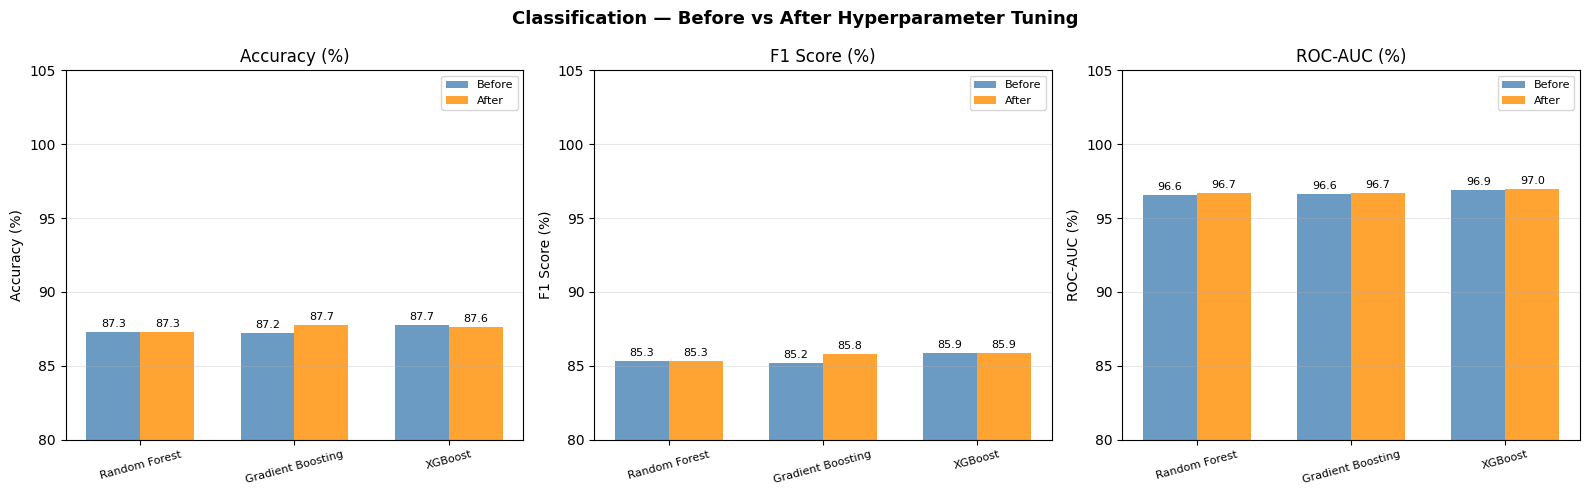

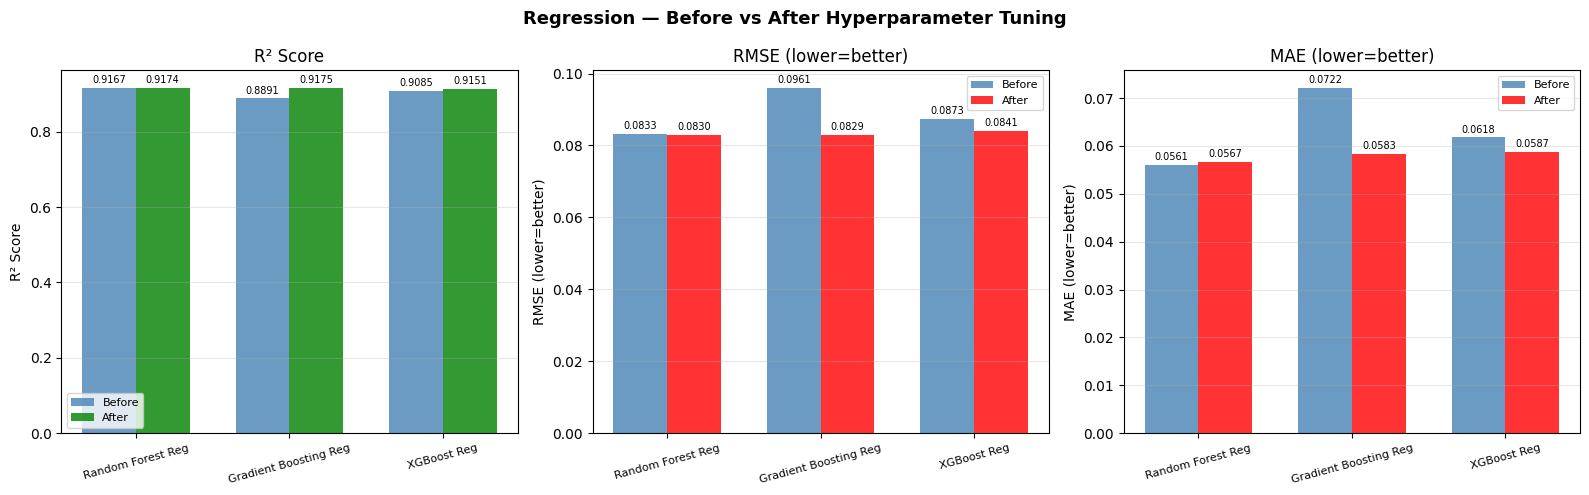


🎉 HYPERPARAMETER TUNING COMPLETE!

   Saved to /content/drive/MyDrive/ML_Project/results/:
   ├── classification_tuned.csv
   ├── regression_tuned.csv
   ├── clf_tuning_comparison.png
   └── reg_tuning_comparison.png

   Best tuned classification model:
   Gradient Boosting — Acc=87.74%  F1=85.82%  AUC=96.72

   Best tuned regression model:
   Gradient Boosting Reg — R²=0.9175  RMSE=0.0829  MAE=0.0583


In [ ]:
# ================================================================
# NASA IMS Bearing — Hyperparameter Tuning
# Classification : XGBoost, Random Forest, Gradient Boosting
# Regression     : Random Forest, XGBoost, Gradient Boosting
# Method         : RandomizedSearchCV (5-fold CV)
# Transform      : Best transform per model from previous results
# ================================================================

!pip install xgboost -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

from sklearn.ensemble        import (RandomForestClassifier,
                                     GradientBoostingClassifier,
                                     RandomForestRegressor,
                                     GradientBoostingRegressor)
from sklearn.model_selection import (train_test_split,
                                     RandomizedSearchCV,
                                     StratifiedKFold, KFold)
from sklearn.preprocessing   import (StandardScaler, PowerTransformer)
from sklearn.metrics         import (accuracy_score, f1_score,
                                     precision_score, recall_score,
                                     roc_auc_score, r2_score,
                                     mean_absolute_error,
                                     mean_squared_error,
                                     explained_variance_score,
                                     mean_absolute_percentage_error)
from xgboost import XGBClassifier, XGBRegressor

print("✅ Libraries imported")

# ── CONFIG ───────────────────────────────────────────────────────
BASE        = "/content/drive/MyDrive/ML_Project/features"
RESULTS_DIR = "/content/drive/MyDrive/ML_Project/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── LOAD & COMBINE DATA ──────────────────────────────────────────
df1 = pd.read_csv(f"{BASE}/ims_test1_features.csv")
df2 = pd.read_csv(f"{BASE}/ims_features.csv")
df3 = pd.read_csv(f"{BASE}/ims_test3_features.csv")
df  = pd.concat([df1, df2, df3], ignore_index=True)

drop_cols    = ['file_name', 'file_index', 'RUL',
                'health_label', 'health_status']
feature_cols = [c for c in df.columns if c not in drop_cols
                and c != 'test_id']

X   = df[feature_cols].values
y_c = df['health_label'].values   # classification target
y_r = df['RUL'].values            # regression target

print(f"✅ Data loaded: {X.shape}")

# ── BEST TRANSFORMS FROM PREVIOUS RESULTS ────────────────────────
# Classification: Log+StandardScaler was best for XGBoost & GB
#                 No Transform was best for RF (scale invariant)
# Regression    : Poly+Standard best for RF, XGBoost, GB
#                 (we use Log+Standard here as it's simpler
#                  and avoids feature explosion)

def apply_log_standard(X_tr, X_te):
    shift    = abs(X_tr.min()) + 1
    X_tr_log = np.log1p(X_tr + shift)
    X_te_log = np.log1p(X_te + shift)
    sc       = StandardScaler()
    return sc.fit_transform(X_tr_log), sc.transform(X_te_log)

def apply_standard(X_tr, X_te):
    sc = StandardScaler()
    return sc.fit_transform(X_tr), sc.transform(X_te)

# ================================================================
# PART 1 — CLASSIFICATION HYPERPARAMETER TUNING
# ================================================================
print("\n" + "="*65)
print("PART 1 — CLASSIFICATION HYPERPARAMETER TUNING")
print("="*65)

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X, y_c, test_size=0.2, random_state=42, stratify=y_c
)

# Apply best transform (Log+StandardScaler) for all 3
X_tr_c_t, X_te_c_t = apply_log_standard(X_tr_c, X_te_c)

cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Classification Parameter Grids ───────────────────────────────
clf_param_grids = {

    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators"     : [100, 200, 300, 500],
            "max_depth"        : [None, 10, 20, 30],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf" : [1, 2, 4],
            "max_features"     : ["sqrt", "log2", 0.5],
        }
    },

    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "n_estimators" : [100, 200, 300],
            "learning_rate": [0.01, 0.05, 0.1, 0.2],
            "max_depth"    : [3, 5, 7],
            "subsample"    : [0.7, 0.8, 0.9, 1.0],
            "max_features" : ["sqrt", "log2", 0.5],
        }
    },

    "XGBoost": {
        "model": XGBClassifier(random_state=42, verbosity=0,
                               eval_metric='mlogloss'),
        "params": {
            "n_estimators" : [100, 200, 300, 500],
            "learning_rate": [0.01, 0.05, 0.1, 0.2],
            "max_depth"    : [3, 5, 7, 9],
            "subsample"    : [0.7, 0.8, 0.9, 1.0],
            "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
            "gamma"        : [0, 0.1, 0.2, 0.5],
        }
    },
}

clf_results = []

for model_name, config in clf_param_grids.items():
    print(f"\n🔍 Tuning: {model_name}")
    print(f"   Parameters to search: {list(config['params'].keys())}")

    search = RandomizedSearchCV(
        estimator   = config['model'],
        param_distributions = config['params'],
        n_iter      = 30,          # try 30 random combinations
        cv          = cv_clf,
        scoring     = 'f1_macro',  # optimise for F1
        n_jobs      = -1,
        random_state= 42,
        verbose     = 1,
    )
    search.fit(X_tr_c_t, y_tr_c)

    # Evaluate best model
    best_model = search.best_estimator_
    y_pred     = best_model.predict(X_te_c_t)
    y_prob     = best_model.predict_proba(X_te_c_t)

    acc  = accuracy_score(y_te_c, y_pred)
    f1   = f1_score(y_te_c, y_pred, average='macro')
    prec = precision_score(y_te_c, y_pred, average='macro')
    rec  = recall_score(y_te_c, y_pred, average='macro')
    auc  = roc_auc_score(y_te_c, y_prob,
                         multi_class='ovr', average='macro')

    print(f"\n   ✅ Best params : {search.best_params_}")
    print(f"   CV F1 Score   : {search.best_score_*100:.2f}%")
    print(f"   Test Accuracy : {acc*100:.2f}%")
    print(f"   Test F1       : {f1*100:.2f}%")
    print(f"   Test ROC-AUC  : {auc*100:.2f}%")

    clf_results.append({
        "Model"             : model_name,
        "Best Params"       : str(search.best_params_),
        "CV F1 Score (%)"   : round(search.best_score_*100, 2),
        "Accuracy (%)"      : round(acc*100, 2),
        "F1 Score (%)"      : round(f1*100, 2),
        "Precision (%)"     : round(prec*100, 2),
        "Recall (%)"        : round(rec*100, 2),
        "ROC-AUC (%)"       : round(auc*100, 2),
    })

df_clf_tuned = pd.DataFrame(clf_results)
df_clf_tuned.to_csv(f"{RESULTS_DIR}/classification_tuned.csv", index=False)
print(f"\n✅ Classification tuning results saved")

# ── Compare Before vs After Tuning ───────────────────────────────
print("\n" + "="*65)
print("📊 CLASSIFICATION — BEFORE vs AFTER TUNING")
print("="*65)

# Load previous results for comparison
prev_clf = pd.read_csv(f"{RESULTS_DIR}/classification_results.csv")

before_after_clf = []
name_map = {
    "Random Forest"    : "Random Forest",
    "Gradient Boosting": "Gradient Boosting",
    "XGBoost"          : "XGBoost (Bonus)",
}
for tuned_name, prev_name in name_map.items():
    prev_row  = prev_clf[prev_clf['Model'] == prev_name]
    best_prev = prev_row.loc[prev_row['Accuracy'].idxmax()]
    tuned_row = df_clf_tuned[df_clf_tuned['Model'] == tuned_name].iloc[0]
    before_after_clf.append({
        "Model"           : tuned_name,
        "Before Accuracy" : best_prev['Accuracy'],
        "After Accuracy"  : tuned_row['Accuracy (%)'],
        "Δ Accuracy"      : round(tuned_row['Accuracy (%)'] - best_prev['Accuracy'], 2),
        "Before F1"       : best_prev['F1 Score'],
        "After F1"        : tuned_row['F1 Score (%)'],
        "Δ F1"            : round(tuned_row['F1 Score (%)'] - best_prev['F1 Score'], 2),
        "Before AUC"      : best_prev['ROC-AUC'],
        "After AUC"       : tuned_row['ROC-AUC (%)'],
        "Δ AUC"           : round(tuned_row['ROC-AUC (%)'] - best_prev['ROC-AUC'], 2),
    })

df_clf_compare = pd.DataFrame(before_after_clf)
print(df_clf_compare.to_string(index=False))

# ================================================================
# PART 2 — REGRESSION HYPERPARAMETER TUNING
# ================================================================
print("\n" + "="*65)
print("PART 2 — REGRESSION HYPERPARAMETER TUNING")
print("="*65)

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X, y_r, test_size=0.2, random_state=42
)

# Apply Log+StandardScaler (best practical transform for regression)
X_tr_r_t, X_te_r_t = apply_log_standard(X_tr_r, X_te_r)

cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

# ── Regression Parameter Grids ────────────────────────────────────
reg_param_grids = {

    "Random Forest Reg": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "n_estimators"     : [100, 200, 300, 500],
            "max_depth"        : [None, 10, 20, 30],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf" : [1, 2, 4],
            "max_features"     : ["sqrt", "log2", 0.5],
        }
    },

    "Gradient Boosting Reg": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            "n_estimators" : [100, 200, 300],
            "learning_rate": [0.01, 0.05, 0.1, 0.2],
            "max_depth"    : [3, 5, 7],
            "subsample"    : [0.7, 0.8, 0.9, 1.0],
            "max_features" : ["sqrt", "log2", 0.5],
        }
    },

    "XGBoost Reg": {
        "model": XGBRegressor(random_state=42, verbosity=0),
        "params": {
            "n_estimators" : [100, 200, 300, 500],
            "learning_rate": [0.01, 0.05, 0.1, 0.2],
            "max_depth"    : [3, 5, 7, 9],
            "subsample"    : [0.7, 0.8, 0.9, 1.0],
            "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
            "gamma"        : [0, 0.1, 0.2, 0.5],
        }
    },
}

reg_results = []

for model_name, config in reg_param_grids.items():
    print(f"\n🔍 Tuning: {model_name}")
    print(f"   Parameters to search: {list(config['params'].keys())}")

    search = RandomizedSearchCV(
        estimator   = config['model'],
        param_distributions = config['params'],
        n_iter      = 30,
        cv          = cv_reg,
        scoring     = 'r2',
        n_jobs      = -1,
        random_state= 42,
        verbose     = 1,
    )
    search.fit(X_tr_r_t, y_tr_r)

    best_model  = search.best_estimator_
    y_pred      = np.clip(best_model.predict(X_te_r_t), 0, 1)

    mask = y_te_r > 0.01
    r2   = r2_score(y_te_r, y_pred)
    mae  = mean_absolute_error(y_te_r, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te_r, y_pred))
    mape = mean_absolute_percentage_error(y_te_r[mask],
                                          y_pred[mask]) * 100
    ev   = explained_variance_score(y_te_r, y_pred)

    print(f"\n   ✅ Best params : {search.best_params_}")
    print(f"   CV R²         : {search.best_score_:.4f}")
    print(f"   Test R²       : {r2:.4f}")
    print(f"   Test MAE      : {mae:.4f}")
    print(f"   Test RMSE     : {rmse:.4f}")
    print(f"   Test MAPE     : {mape:.2f}%")

    reg_results.append({
        "Model"              : model_name,
        "Best Params"        : str(search.best_params_),
        "CV R²"              : round(search.best_score_, 4),
        "R²"                 : round(r2,   4),
        "MAE"                : round(mae,  4),
        "RMSE"               : round(rmse, 4),
        "MAPE (%)"           : round(mape, 2),
        "Explained Variance" : round(ev,   4),
    })

df_reg_tuned = pd.DataFrame(reg_results)
df_reg_tuned.to_csv(f"{RESULTS_DIR}/regression_tuned.csv", index=False)
print(f"\n✅ Regression tuning results saved")

# ── Compare Before vs After Tuning ───────────────────────────────
print("\n" + "="*65)
print("📊 REGRESSION — BEFORE vs AFTER TUNING")
print("="*65)

prev_reg = pd.read_csv(f"{RESULTS_DIR}/regression_results.csv")

before_after_reg = []
reg_name_map = {
    "Random Forest Reg"    : "Random Forest Reg",
    "Gradient Boosting Reg": "Gradient Boosting Reg",
    "XGBoost Reg"          : "XGBoost Reg (Bonus)",
}
for tuned_name, prev_name in reg_name_map.items():
    prev_row  = prev_reg[prev_reg['Model'] == prev_name]
    best_prev = prev_row.loc[prev_row['R²'].idxmax()]
    tuned_row = df_reg_tuned[df_reg_tuned['Model'] == tuned_name].iloc[0]
    before_after_reg.append({
        "Model"      : tuned_name,
        "Before R²"  : best_prev['R²'],
        "After R²"   : tuned_row['R²'],
        "Δ R²"       : round(tuned_row['R²'] - best_prev['R²'], 4),
        "Before RMSE": best_prev['RMSE'],
        "After RMSE" : tuned_row['RMSE'],
        "Δ RMSE"     : round(tuned_row['RMSE'] - best_prev['RMSE'], 4),
        "Before MAE" : best_prev['MAE'],
        "After MAE"  : tuned_row['MAE'],
        "Δ MAE"      : round(tuned_row['MAE'] - best_prev['MAE'], 4),
    })

df_reg_compare = pd.DataFrame(before_after_reg)
print(df_reg_compare.to_string(index=False))

# ================================================================
# VISUALIZATIONS
# ================================================================

# Plot 1 — Classification Before vs After
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Classification — Before vs After Hyperparameter Tuning",
             fontsize=13, fontweight='bold')

metrics_clf = [("Before Accuracy","After Accuracy","Accuracy (%)"),
               ("Before F1","After F1","F1 Score (%)"),
               ("Before AUC","After AUC","ROC-AUC (%)")]

for ax, (before_col, after_col, ylabel) in zip(axes, metrics_clf):
    x      = np.arange(len(df_clf_compare))
    width  = 0.35
    bars1  = ax.bar(x - width/2, df_clf_compare[before_col],
                    width, label='Before', color='steelblue', alpha=0.8)
    bars2  = ax.bar(x + width/2, df_clf_compare[after_col],
                    width, label='After', color='darkorange', alpha=0.8)
    ax.bar_label(bars1, fmt='%.1f', padding=2, fontsize=8)
    ax.bar_label(bars2, fmt='%.1f', padding=2, fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(df_clf_compare['Model'], rotation=15, fontsize=8)
    ax.set_ylabel(ylabel); ax.set_ylim([80, 105])
    ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.3)
    ax.set_title(ylabel)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/clf_tuning_comparison.png", dpi=150)
plt.show()

# Plot 2 — Regression Before vs After
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Regression — Before vs After Hyperparameter Tuning",
             fontsize=13, fontweight='bold')

metrics_reg = [("Before R²","After R²","R² Score"),
               ("Before RMSE","After RMSE","RMSE (lower=better)"),
               ("Before MAE","After MAE","MAE (lower=better)")]

for ax, (before_col, after_col, ylabel) in zip(axes, metrics_reg):
    x      = np.arange(len(df_reg_compare))
    width  = 0.35
    color2 = 'green' if 'R²' in ylabel else 'red'
    bars1  = ax.bar(x - width/2, df_reg_compare[before_col],
                    width, label='Before', color='steelblue', alpha=0.8)
    bars2  = ax.bar(x + width/2, df_reg_compare[after_col],
                    width, label='After',  color=color2, alpha=0.8)
    ax.bar_label(bars1, fmt='%.4f', padding=2, fontsize=7)
    ax.bar_label(bars2, fmt='%.4f', padding=2, fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(df_reg_compare['Model'], rotation=15, fontsize=8)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.3)
    ax.set_title(ylabel)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/reg_tuning_comparison.png", dpi=150)
plt.show()

# ── Final Summary ─────────────────────────────────────────────────
print("\n" + "="*65)
print("🎉 HYPERPARAMETER TUNING COMPLETE!")
print("="*65)
print(f"\n   Saved to {RESULTS_DIR}/:")
print(f"   ├── classification_tuned.csv")
print(f"   ├── regression_tuned.csv")
print(f"   ├── clf_tuning_comparison.png")
print(f"   └── reg_tuning_comparison.png")
print(f"\n   Best tuned classification model:")
best_clf_row = df_clf_tuned.loc[df_clf_tuned['Accuracy (%)'].idxmax()]
print(f"   {best_clf_row['Model']} — "
      f"Acc={best_clf_row['Accuracy (%)']}%  "
      f"F1={best_clf_row['F1 Score (%)']}%  "
      f"AUC={best_clf_row['ROC-AUC (%)']}")
print(f"\n   Best tuned regression model:")
best_reg_row = df_reg_tuned.loc[df_reg_tuned['R²'].idxmax()]
print(f"   {best_reg_row['Model']} — "
      f"R²={best_reg_row['R²']}  "
      f"RMSE={best_reg_row['RMSE']}  "
      f"MAE={best_reg_row['MAE']}")

In [ ]:
# @title
# ================================================================
# NASA IMS Bearing — Hyperparameter Tuning (BayesSearchCV)
# Classification : XGBoost, Random Forest, Gradient Boosting
# Regression     : Random Forest, XGBoost, Gradient Boosting
# Method         : BayesSearchCV (Gaussian Process — smarter search)
# ⚠️ Saves to NEW files — does NOT overwrite RandomizedSearchCV results
# ================================================================

!pip install xgboost scikit-optimize -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

from sklearn.ensemble        import (RandomForestClassifier,
                                     GradientBoostingClassifier,
                                     RandomForestRegressor,
                                     GradientBoostingRegressor)
from sklearn.model_selection import (train_test_split,
                                     StratifiedKFold, KFold)
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import (accuracy_score, f1_score,
                                     precision_score, recall_score,
                                     roc_auc_score, r2_score,
                                     mean_absolute_error,
                                     mean_squared_error,
                                     explained_variance_score,
                                     mean_absolute_percentage_error)
from xgboost    import XGBClassifier, XGBRegressor
from skopt      import BayesSearchCV
from skopt.space import Real, Integer, Categorical

print("✅ Libraries imported")

# ── CONFIG ───────────────────────────────────────────────────────
BASE        = "/content/drive/MyDrive/ML_Project/features"
RESULTS_DIR = "/content/drive/MyDrive/ML_Project/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Output files — completely separate from RandomizedSearchCV results
CLF_BAYES_CSV  = f"{RESULTS_DIR}/classification_tuned_bayes.csv"
REG_BAYES_CSV  = f"{RESULTS_DIR}/regression_tuned_bayes.csv"

# ── LOAD & COMBINE DATA ──────────────────────────────────────────
df1 = pd.read_csv(f"{BASE}/ims_test1_features.csv")
df2 = pd.read_csv(f"{BASE}/ims_features.csv")
df3 = pd.read_csv(f"{BASE}/ims_test3_features.csv")
df  = pd.concat([df1, df2, df3], ignore_index=True)

drop_cols    = ['file_name', 'file_index', 'RUL',
                'health_label', 'health_status']
feature_cols = [c for c in df.columns if c not in drop_cols
                and c != 'test_id']

X   = df[feature_cols].values
y_c = df['health_label'].values
y_r = df['RUL'].values

print(f"✅ Data loaded: {X.shape}")

# ── TRANSFORM HELPER ─────────────────────────────────────────────
def apply_log_standard(X_tr, X_te):
    shift    = abs(X_tr.min()) + 1
    X_tr_log = np.log1p(X_tr + shift)
    X_te_log = np.log1p(X_te + shift)
    sc       = StandardScaler()
    return sc.fit_transform(X_tr_log), sc.transform(X_te_log)

# ================================================================
# PART 1 — CLASSIFICATION (BayesSearchCV)
# ================================================================
print("\n" + "="*65)
print("PART 1 — CLASSIFICATION — BayesSearchCV")
print("="*65)
print("   How it works: Gaussian Process learns from each trial")
print("   and intelligently picks the next parameter combination")
print("   instead of searching randomly.\n")

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X, y_c, test_size=0.2, random_state=42, stratify=y_c
)
X_tr_c_t, X_te_c_t = apply_log_standard(X_tr_c, X_te_c)
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── BayesSearch Spaces ────────────────────────────────────────────
# Real()        → continuous range  (e.g. learning rate)
# Integer()     → integer range     (e.g. max_depth)
# Categorical() → discrete choices  (e.g. max_features)

clf_search_spaces = {

    "Random Forest": {
        "model": RandomForestClassifier(random_state=42, n_jobs=-1),
        "space": {
            "n_estimators"     : Integer(100, 500),
            "max_depth"        : Integer(5, 50),
            "min_samples_split": Integer(2, 20),
            "min_samples_leaf" : Integer(1, 10),
            "max_features"     : Categorical(["sqrt", "log2", 0.3, 0.5]),
        }
    },

    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "space": {
            "n_estimators" : Integer(100, 400),
            "learning_rate": Real(0.005, 0.3, prior='log-uniform'),
            "max_depth"    : Integer(2, 8),
            "subsample"    : Real(0.6, 1.0),
            "max_features" : Categorical(["sqrt", "log2", 0.5]),
        }
    },

    "XGBoost": {
        "model": XGBClassifier(random_state=42, verbosity=0,
                               eval_metric='mlogloss', n_jobs=-1),
        "space": {
            "n_estimators"    : Integer(100, 500),
            "learning_rate"   : Real(0.005, 0.3, prior='log-uniform'),
            "max_depth"       : Integer(2, 10),
            "subsample"       : Real(0.6, 1.0),
            "colsample_bytree": Real(0.6, 1.0),
            "gamma"           : Real(0, 0.5),
            "reg_alpha"       : Real(0, 1.0),
            "reg_lambda"      : Real(0.5, 2.0),
        }
    },
}

clf_results = []

for model_name, config in clf_search_spaces.items():
    print(f"🔍 Tuning: {model_name}  (30 Bayesian iterations)")

    search = BayesSearchCV(
        estimator    = config['model'],
        search_spaces= config['space'],
        n_iter       = 30,
        cv           = cv_clf,
        scoring      = 'f1_macro',
        n_jobs       = -1,
        random_state = 42,
        verbose      = 0,
        refit        = True,
    )
    search.fit(X_tr_c_t, y_tr_c)

    best_model = search.best_estimator_
    y_pred     = best_model.predict(X_te_c_t)
    y_prob     = best_model.predict_proba(X_te_c_t)

    acc  = accuracy_score(y_te_c, y_pred)
    f1   = f1_score(y_te_c, y_pred, average='macro')
    prec = precision_score(y_te_c, y_pred, average='macro')
    rec  = recall_score(y_te_c, y_pred, average='macro')
    auc  = roc_auc_score(y_te_c, y_prob,
                         multi_class='ovr', average='macro')

    print(f"   ✅ Best CV F1     : {search.best_score_*100:.2f}%")
    print(f"   ✅ Test Accuracy  : {acc*100:.2f}%")
    print(f"   ✅ Test F1        : {f1*100:.2f}%")
    print(f"   ✅ Test ROC-AUC   : {auc*100:.2f}%")
    print(f"   ✅ Best Params    : {search.best_params_}\n")

    clf_results.append({
        "Model"           : model_name,
        "Tuning Method"   : "BayesSearchCV",
        "Best Params"     : str(dict(search.best_params_)),
        "CV F1 Score (%)" : round(search.best_score_*100, 2),
        "Accuracy (%)"    : round(acc*100, 2),
        "F1 Score (%)"    : round(f1*100, 2),
        "Precision (%)"   : round(prec*100, 2),
        "Recall (%)"      : round(rec*100, 2),
        "ROC-AUC (%)"     : round(auc*100, 2),
    })

df_clf_bayes = pd.DataFrame(clf_results)
df_clf_bayes.to_csv(CLF_BAYES_CSV, index=False)
print(f"✅ Saved → {CLF_BAYES_CSV}")

# ================================================================
# PART 2 — REGRESSION (BayesSearchCV)
# ================================================================
print("\n" + "="*65)
print("PART 2 — REGRESSION — BayesSearchCV")
print("="*65)

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X, y_r, test_size=0.2, random_state=42
)
X_tr_r_t, X_te_r_t = apply_log_standard(X_tr_r, X_te_r)
cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

reg_search_spaces = {

    "Random Forest Reg": {
        "model": RandomForestRegressor(random_state=42, n_jobs=-1),
        "space": {
            "n_estimators"     : Integer(100, 500),
            "max_depth"        : Integer(5, 50),
            "min_samples_split": Integer(2, 20),
            "min_samples_leaf" : Integer(1, 10),
            "max_features"     : Categorical(["sqrt", "log2", 0.3, 0.5]),
        }
    },

    "Gradient Boosting Reg": {
        "model": GradientBoostingRegressor(random_state=42),
        "space": {
            "n_estimators" : Integer(100, 400),
            "learning_rate": Real(0.005, 0.3, prior='log-uniform'),
            "max_depth"    : Integer(2, 8),
            "subsample"    : Real(0.6, 1.0),
            "max_features" : Categorical(["sqrt", "log2", 0.5]),
        }
    },

    "XGBoost Reg": {
        "model": XGBRegressor(random_state=42, verbosity=0, n_jobs=-1),
        "space": {
            "n_estimators"    : Integer(100, 500),
            "learning_rate"   : Real(0.005, 0.3, prior='log-uniform'),
            "max_depth"       : Integer(2, 10),
            "subsample"       : Real(0.6, 1.0),
            "colsample_bytree": Real(0.6, 1.0),
            "gamma"           : Real(0, 0.5),
            "reg_alpha"       : Real(0, 1.0),
            "reg_lambda"      : Real(0.5, 2.0),
        }
    },
}

reg_results = []

for model_name, config in reg_search_spaces.items():
    print(f"🔍 Tuning: {model_name}  (30 Bayesian iterations)")

    search = BayesSearchCV(
        estimator    = config['model'],
        search_spaces= config['space'],
        n_iter       = 30,
        cv           = cv_reg,
        scoring      = 'r2',
        n_jobs       = -1,
        random_state = 42,
        verbose      = 0,
        refit        = True,
    )
    search.fit(X_tr_r_t, y_tr_r)

    best_model = search.best_estimator_
    y_pred     = np.clip(best_model.predict(X_te_r_t), 0, 1)
    mask       = y_te_r > 0.01

    r2   = r2_score(y_te_r, y_pred)
    mae  = mean_absolute_error(y_te_r, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te_r, y_pred))
    mape = mean_absolute_percentage_error(
               y_te_r[mask], y_pred[mask]) * 100
    ev   = explained_variance_score(y_te_r, y_pred)

    print(f"   ✅ Best CV R²     : {search.best_score_:.4f}")
    print(f"   ✅ Test R²        : {r2:.4f}")
    print(f"   ✅ Test MAE       : {mae:.4f}")
    print(f"   ✅ Test RMSE      : {rmse:.4f}")
    print(f"   ✅ Test MAPE      : {mape:.2f}%")
    print(f"   ✅ Best Params    : {search.best_params_}\n")

    reg_results.append({
        "Model"              : model_name,
        "Tuning Method"      : "BayesSearchCV",
        "Best Params"        : str(dict(search.best_params_)),
        "CV R²"              : round(search.best_score_, 4),
        "R²"                 : round(r2,   4),
        "MAE"                : round(mae,  4),
        "RMSE"               : round(rmse, 4),
        "MAPE (%)"           : round(mape, 2),
        "Explained Variance" : round(ev,   4),
    })

df_reg_bayes = pd.DataFrame(reg_results)
df_reg_bayes.to_csv(REG_BAYES_CSV, index=False)
print(f"✅ Saved → {REG_BAYES_CSV}")

# ================================================================
# COMPARISON: No Tuning vs Randomized vs Bayes
# ================================================================
print("\n" + "="*65)
print("📊 FULL 3-WAY COMPARISON")
print("="*65)

prev_clf = pd.read_csv(f"{RESULTS_DIR}/classification_results.csv")
rand_clf = pd.read_csv(f"{RESULTS_DIR}/classification_tuned.csv")
prev_reg = pd.read_csv(f"{RESULTS_DIR}/regression_results.csv")
rand_reg = pd.read_csv(f"{RESULTS_DIR}/regression_tuned.csv")

# Classification
print("\nCLASSIFICATION — Accuracy (%)")
print(f"{'Model':<25} {'No Tuning':>10} {'Randomized':>12} "
      f"{'Bayes':>8} {'Δ (Bayes-None)':>15}")
print("-"*73)
clf_compare_rows = []
for bayes_name in ["Random Forest", "Gradient Boosting", "XGBoost"]:
    prev_name = "XGBoost (Bonus)" if bayes_name == "XGBoost" else bayes_name
    no_tune   = prev_clf[prev_clf['Model']==prev_name]['Accuracy'].max()
    rand_row  = rand_clf[rand_clf['Model']==bayes_name]
    rand_acc  = rand_row['Accuracy (%)'].values[0] if len(rand_row) else 0
    bayes_row = df_clf_bayes[df_clf_bayes['Model']==bayes_name]
    bayes_acc = bayes_row['Accuracy (%)'].values[0] if len(bayes_row) else 0
    delta     = round(bayes_acc - no_tune, 2)
    print(f"{bayes_name:<25} {no_tune:>10.2f} {rand_acc:>12.2f} "
          f"{bayes_acc:>8.2f} {delta:>+15.2f}%")
    clf_compare_rows.append({
        "Model": bayes_name, "No Tuning Acc": no_tune,
        "Randomized Acc": rand_acc, "Bayes Acc": bayes_acc
    })

# Regression
print("\nREGRESSION — R² Score")
print(f"{'Model':<28} {'No Tuning':>10} {'Randomized':>12} "
      f"{'Bayes':>8} {'Δ (Bayes-None)':>15}")
print("-"*76)
reg_compare_rows = []
for bayes_name, prev_name in {
    "Random Forest Reg"    : "Random Forest Reg",
    "Gradient Boosting Reg": "Gradient Boosting Reg",
    "XGBoost Reg"          : "XGBoost Reg (Bonus)",
}.items():
    no_tune   = prev_reg[prev_reg['Model']==prev_name]['R²'].max()
    rand_row  = rand_reg[rand_reg['Model']==bayes_name]
    rand_r2   = rand_row['R²'].values[0] if len(rand_row) else 0
    bayes_row = df_reg_bayes[df_reg_bayes['Model']==bayes_name]
    bayes_r2  = bayes_row['R²'].values[0] if len(bayes_row) else 0
    delta     = round(bayes_r2 - no_tune, 4)
    print(f"{bayes_name:<28} {no_tune:>10.4f} {rand_r2:>12.4f} "
          f"{bayes_r2:>8.4f} {delta:>+15.4f}")
    reg_compare_rows.append({
        "Model": bayes_name, "No Tuning R2": no_tune,
        "Randomized R2": rand_r2, "Bayes R2": bayes_r2
    })

df_clf_cmp = pd.DataFrame(clf_compare_rows)
df_reg_cmp = pd.DataFrame(reg_compare_rows)

# ── Visualization ─────────────────────────────────────────────────
x = np.arange(3)
w = 0.25

# Classification plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Classification — No Tuning vs Randomized vs BayesSearchCV",
             fontsize=12, fontweight='bold')

for ax, (col_no, col_r, col_b, ylabel) in zip(axes, [
    ('No Tuning Acc',  'Randomized Acc', 'Bayes Acc', 'Accuracy (%)'),
    ('No Tuning Acc',  'Randomized Acc', 'Bayes Acc', 'Accuracy (%)'),
]):
    b1 = ax.bar(x-w, df_clf_cmp[col_no], w,
                label='No Tuning',  color='steelblue',  alpha=0.85)
    b2 = ax.bar(x,   df_clf_cmp[col_r],  w,
                label='Randomized', color='darkorange', alpha=0.85)
    b3 = ax.bar(x+w, df_clf_cmp[col_b],  w,
                label='Bayes',      color='seagreen',   alpha=0.85)
    for bars in [b1, b2, b3]:
        ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(df_clf_cmp['Model'], fontsize=9)
    ax.set_ylabel(ylabel); ax.set_ylim([82, 105])
    ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.3)
    ax.set_title("Accuracy Comparison")
    break   # only one unique chart needed here

# Add F1 chart
ax2 = axes[1]
f1_no  = [prev_clf[prev_clf['Model']==
           ("XGBoost (Bonus)" if m=="XGBoost" else m)
           ]['F1 Score'].max() for m in ["Random Forest","Gradient Boosting","XGBoost"]]
f1_r   = [rand_clf[rand_clf['Model']==m]['F1 Score (%)'].values[0]
          if len(rand_clf[rand_clf['Model']==m]) else 0
          for m in ["Random Forest","Gradient Boosting","XGBoost"]]
f1_b   = [df_clf_bayes[df_clf_bayes['Model']==m]['F1 Score (%)'].values[0]
          if len(df_clf_bayes[df_clf_bayes['Model']==m]) else 0
          for m in ["Random Forest","Gradient Boosting","XGBoost"]]
b1 = ax2.bar(x-w, f1_no, w, label='No Tuning',  color='steelblue',  alpha=0.85)
b2 = ax2.bar(x,   f1_r,  w, label='Randomized', color='darkorange', alpha=0.85)
b3 = ax2.bar(x+w, f1_b,  w, label='Bayes',      color='seagreen',   alpha=0.85)
for bars in [b1, b2, b3]:
    ax2.bar_label(bars, fmt='%.2f', padding=2, fontsize=8)
ax2.set_xticks(x)
ax2.set_xticklabels(["Random Forest","Gradient Boosting","XGBoost"], fontsize=9)
ax2.set_ylabel("F1 Score (%)"); ax2.set_ylim([82, 105])
ax2.legend(fontsize=8); ax2.grid(True, axis='y', alpha=0.3)
ax2.set_title("F1 Score Comparison")

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/clf_3way_comparison.png", dpi=150)
plt.show()

# Regression plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Regression — No Tuning vs Randomized vs BayesSearchCV",
             fontsize=12, fontweight='bold')

b1 = axes[0].bar(x-w, df_reg_cmp['No Tuning R2'],  w,
                 label='No Tuning',  color='steelblue',  alpha=0.85)
b2 = axes[0].bar(x,   df_reg_cmp['Randomized R2'], w,
                 label='Randomized', color='darkorange', alpha=0.85)
b3 = axes[0].bar(x+w, df_reg_cmp['Bayes R2'],      w,
                 label='Bayes',      color='seagreen',   alpha=0.85)
for bars in [b1, b2, b3]:
    axes[0].bar_label(bars, fmt='%.4f', padding=2, fontsize=8)
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.replace(' Reg','') for m in df_reg_cmp['Model']],
                         fontsize=9)
axes[0].set_ylabel("R² Score"); axes[0].set_ylim([0.85, 1.0])
axes[0].legend(fontsize=8); axes[0].grid(True, axis='y', alpha=0.3)
axes[0].set_title("R² Comparison (higher = better)")

rmse_no = [prev_reg[prev_reg['Model']==
            ("XGBoost Reg (Bonus)" if "XGBoost" in m else m)
            ]['RMSE'].min() for m in df_reg_cmp['Model']]
rmse_r  = [rand_reg[rand_reg['Model']==m]['RMSE'].values[0]
           if len(rand_reg[rand_reg['Model']==m]) else 0
           for m in df_reg_cmp['Model']]
rmse_b  = [df_reg_bayes[df_reg_bayes['Model']==m]['RMSE'].values[0]
           if len(df_reg_bayes[df_reg_bayes['Model']==m]) else 0
           for m in df_reg_cmp['Model']]
b1 = axes[1].bar(x-w, rmse_no, w, label='No Tuning',  color='steelblue',  alpha=0.85)
b2 = axes[1].bar(x,   rmse_r,  w, label='Randomized', color='darkorange', alpha=0.85)
b3 = axes[1].bar(x+w, rmse_b,  w, label='Bayes',      color='seagreen',   alpha=0.85)
for bars in [b1, b2, b3]:
    axes[1].bar_label(bars, fmt='%.4f', padding=2, fontsize=8)
axes[1].set_xticks(x)
axes[1].set_xticklabels([m.replace(' Reg','') for m in df_reg_cmp['Model']],
                         fontsize=9)
axes[1].set_ylabel("RMSE"); axes[1].legend(fontsize=8)
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].set_title("RMSE Comparison (lower = better)")

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/reg_3way_comparison.png", dpi=150)
plt.show()

# ── Final Summary ─────────────────────────────────────────────────
print("\n" + "="*65)
print("🎉 BayesSearchCV Tuning Complete!")
print("="*65)
print(f"\n   New files created:")
print(f"   ├── classification_tuned_bayes.csv  ← NEW")
print(f"   ├── regression_tuned_bayes.csv      ← NEW")
print(f"   ├── clf_3way_comparison.png         ← NEW")
print(f"   └── reg_3way_comparison.png         ← NEW")
print(f"\n   Existing files untouched:")
print(f"   ├── classification_results.csv      ✅ safe")
print(f"   ├── regression_results.csv          ✅ safe")
print(f"   ├── classification_tuned.csv        ✅ safe")
print(f"   └── regression_tuned.csv            ✅ safe")

'pip' is not recognized as an internal or external command,
operable program or batch file.


ModuleNotFoundError: No module named 'google'

✅ Libraries imported
✅ Data loaded: (9464, 34)

PART 1 — CLASSIFICATION — BayesSearchCV
🔍 Tuning: Random Forest  (30 Bayesian iterations)
   ✅ Best CV F1     : 85.54%
   ✅ Test Accuracy  : 87.96%
   ✅ Test F1        : 86.11%
   ✅ Test ROC-AUC   : 96.79%
   ✅ Best Params    : OrderedDict({'max_depth': 35, 'max_features': 0.3, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 498})

🔍 Tuning: Gradient Boosting  (30 Bayesian iterations)
   ✅ Best CV F1     : 85.99%
   ✅ Test Accuracy  : 88.17%
   ✅ Test F1        : 86.33%
   ✅ Test ROC-AUC   : 96.89%
   ✅ Best Params    : OrderedDict({'learning_rate': 0.03089936057345576, 'max_depth': 8, 'max_features': 'sqrt', 'n_estimators': 230, 'subsample': 0.6751820745469395})

🔍 Tuning: XGBoost  (30 Bayesian iterations)
   ✅ Best CV F1     : 85.97%
   ✅ Test Accuracy  : 87.64%
   ✅ Test F1        : 85.90%
   ✅ Test ROC-AUC   : 96.91%
   ✅ Best Params    : OrderedDict({'colsample_bytree': 0.7640415835413256, 'gamma': 0.36386287158866254,

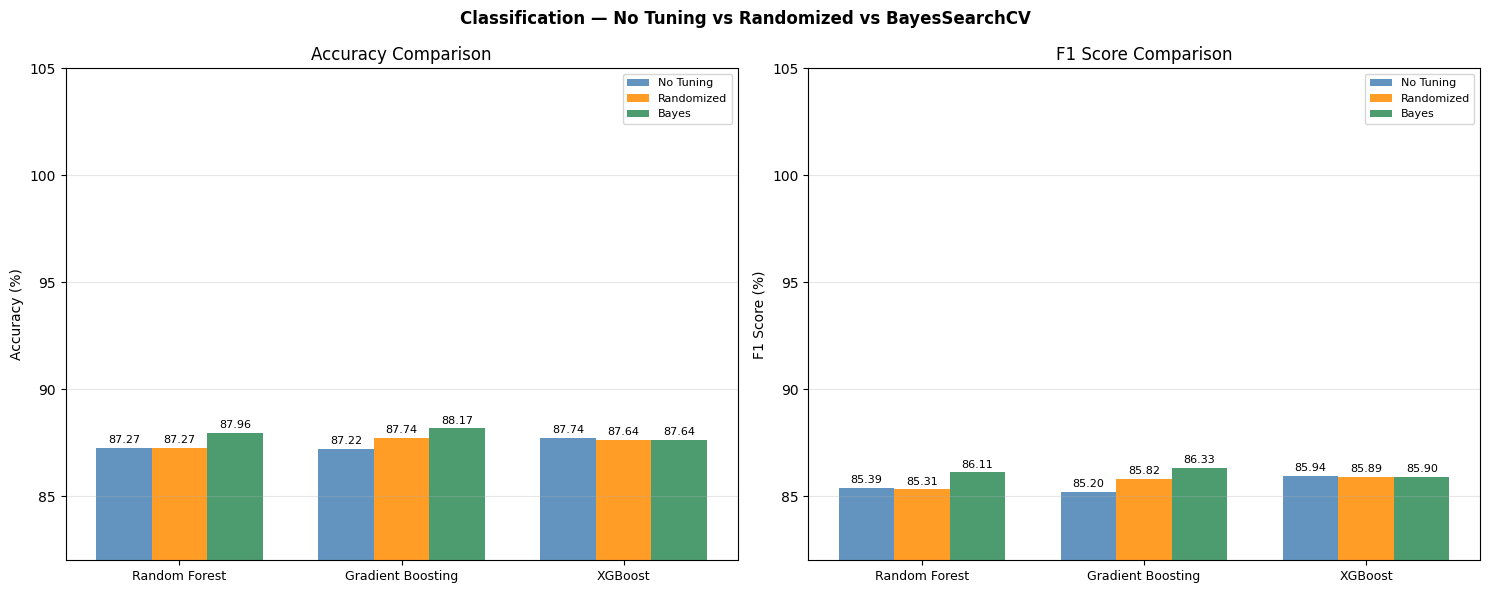

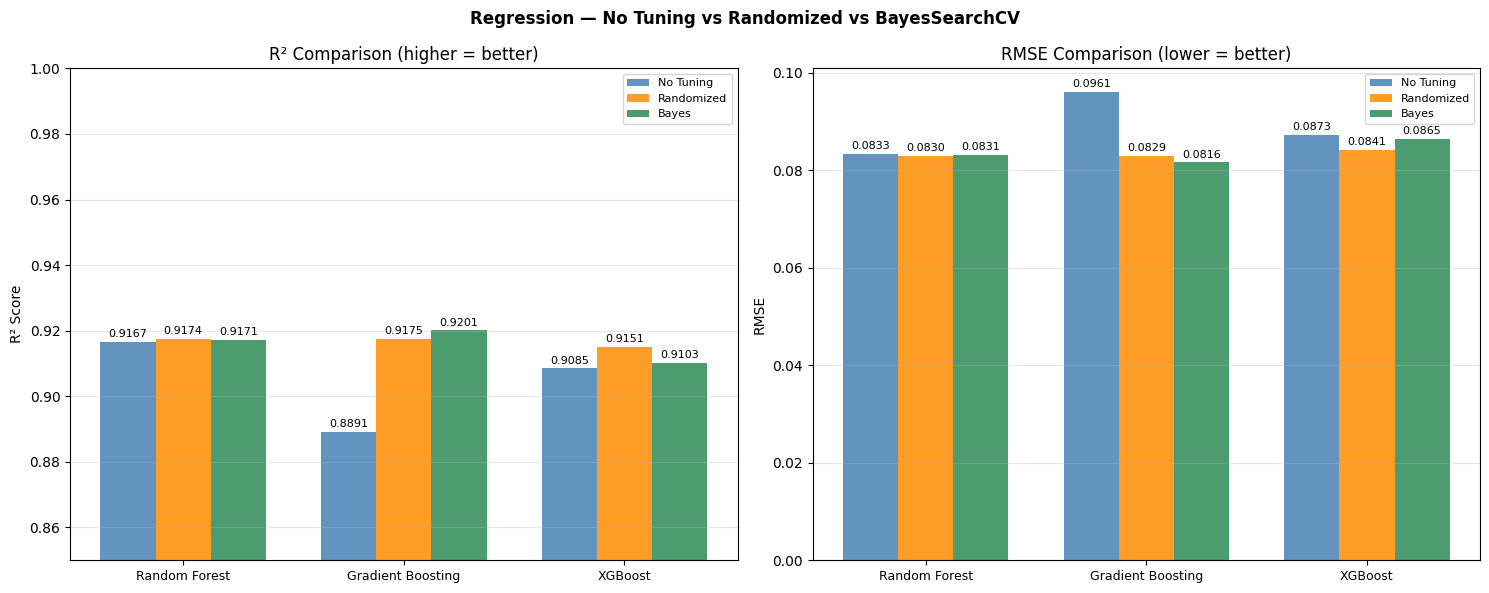


🎉 BayesSearchCV Tuning Complete!

   New files created:
   ├── classification_tuned_bayes.csv  ← NEW
   ├── regression_tuned_bayes.csv      ← NEW
   ├── clf_3way_comparison.png         ← NEW
   └── reg_3way_comparison.png         ← NEW

   Existing files untouched:
   ├── classification_results.csv      ✅ safe
   ├── regression_results.csv          ✅ safe
   ├── classification_tuned.csv        ✅ safe
   └── regression_tuned.csv            ✅ safe


In [ ]:
# @title
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "xgboost", "scikit-optimize", "-q"])

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble        import (RandomForestClassifier,
                                     GradientBoostingClassifier,
                                     RandomForestRegressor,
                                     GradientBoostingRegressor)
from sklearn.model_selection import (train_test_split,
                                     StratifiedKFold, KFold)
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import (accuracy_score, f1_score,
                                     precision_score, recall_score,
                                     roc_auc_score, r2_score,
                                     mean_absolute_error,
                                     mean_squared_error,
                                     explained_variance_score,
                                     mean_absolute_percentage_error)
from xgboost    import XGBClassifier, XGBRegressor
from skopt      import BayesSearchCV
from skopt.space import Real, Integer, Categorical

print("✅ Libraries imported")

# ── CONFIG ───────────────────────────────────────────────────────
BASE        = r"C:\Users\dahar\Downloads\drive-download-20260312T141721Z-3-001"
RESULTS_DIR = r"C:\Users\dahar\Downloads\ML_Project_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

CLF_BAYES_CSV = f"{RESULTS_DIR}/classification_tuned_bayes.csv"
REG_BAYES_CSV = f"{RESULTS_DIR}/regression_tuned_bayes.csv"

# ── LOAD & COMBINE DATA ──────────────────────────────────────────
df1 = pd.read_csv(f"{BASE}/ims_test1_features.csv")
df2 = pd.read_csv(f"{BASE}/ims_features.csv")
df3 = pd.read_csv(f"{BASE}/ims_test3_features.csv")
df  = pd.concat([df1, df2, df3], ignore_index=True)

drop_cols    = ['file_name', 'file_index', 'RUL',
                'health_label', 'health_status']
feature_cols = [c for c in df.columns if c not in drop_cols
                and c != 'test_id']

X   = df[feature_cols].values
y_c = df['health_label'].values
y_r = df['RUL'].values

print(f"✅ Data loaded: {X.shape}")

# ── TRANSFORM HELPER ─────────────────────────────────────────────
def apply_log_standard(X_tr, X_te):
    shift    = abs(X_tr.min()) + 1
    X_tr_log = np.log1p(X_tr + shift)
    X_te_log = np.log1p(X_te + shift)
    sc       = StandardScaler()
    return sc.fit_transform(X_tr_log), sc.transform(X_te_log)

# ================================================================
# PART 1 — CLASSIFICATION (BayesSearchCV)
# ================================================================
print("\n" + "="*65)
print("PART 1 — CLASSIFICATION — BayesSearchCV")
print("="*65)

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X, y_c, test_size=0.2, random_state=42, stratify=y_c
)
X_tr_c_t, X_te_c_t = apply_log_standard(X_tr_c, X_te_c)
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

clf_search_spaces = {
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42, n_jobs=-1),
        "space": {
            "n_estimators"     : Integer(100, 500),
            "max_depth"        : Integer(5, 50),
            "min_samples_split": Integer(2, 20),
            "min_samples_leaf" : Integer(1, 10),
            "max_features"     : Categorical(["sqrt", "log2", 0.3, 0.5]),
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "space": {
            "n_estimators" : Integer(100, 400),
            "learning_rate": Real(0.005, 0.3, prior='log-uniform'),
            "max_depth"    : Integer(2, 8),
            "subsample"    : Real(0.6, 1.0),
            "max_features" : Categorical(["sqrt", "log2", 0.5]),
        }
    },
    "XGBoost": {
        "model": XGBClassifier(random_state=42, verbosity=0,
                               eval_metric='mlogloss', n_jobs=-1,
                               device='cuda'),
        "space": {
            "n_estimators"    : Integer(100, 500),
            "learning_rate"   : Real(0.005, 0.3, prior='log-uniform'),
            "max_depth"       : Integer(2, 10),
            "subsample"       : Real(0.6, 1.0),
            "colsample_bytree": Real(0.6, 1.0),
            "gamma"           : Real(0, 0.5),
            "reg_alpha"       : Real(0, 1.0),
            "reg_lambda"      : Real(0.5, 2.0),
        }
    },
}

clf_results = []

for model_name, config in clf_search_spaces.items():
    print(f"🔍 Tuning: {model_name}  (30 Bayesian iterations)")

    search = BayesSearchCV(
        estimator    = config['model'],
        search_spaces= config['space'],
        n_iter       = 30,
        cv           = cv_clf,
        scoring      = 'f1_macro',
        n_jobs       = 1,
        random_state = 42,
        verbose      = 0,
        refit        = True,
    )
    search.fit(X_tr_c_t, y_tr_c)

    best_model = search.best_estimator_
    y_pred     = best_model.predict(X_te_c_t)
    y_prob     = best_model.predict_proba(X_te_c_t)

    acc  = accuracy_score(y_te_c, y_pred)
    f1   = f1_score(y_te_c, y_pred, average='macro')
    prec = precision_score(y_te_c, y_pred, average='macro')
    rec  = recall_score(y_te_c, y_pred, average='macro')
    auc  = roc_auc_score(y_te_c, y_prob,
                         multi_class='ovr', average='macro')

    print(f"   ✅ Best CV F1     : {search.best_score_*100:.2f}%")
    print(f"   ✅ Test Accuracy  : {acc*100:.2f}%")
    print(f"   ✅ Test F1        : {f1*100:.2f}%")
    print(f"   ✅ Test ROC-AUC   : {auc*100:.2f}%")
    print(f"   ✅ Best Params    : {search.best_params_}\n")

    clf_results.append({
        "Model"           : model_name,
        "Tuning Method"   : "BayesSearchCV",
        "Best Params"     : str(dict(search.best_params_)),
        "CV F1 Score (%)" : round(search.best_score_*100, 2),
        "Accuracy (%)"    : round(acc*100, 2),
        "F1 Score (%)"    : round(f1*100, 2),
        "Precision (%)"   : round(prec*100, 2),
        "Recall (%)"      : round(rec*100, 2),
        "ROC-AUC (%)"     : round(auc*100, 2),
    })

df_clf_bayes = pd.DataFrame(clf_results)
df_clf_bayes.to_csv(CLF_BAYES_CSV, index=False)
print(f"✅ Saved → {CLF_BAYES_CSV}")

# ================================================================
# PART 2 — REGRESSION (BayesSearchCV)
# ================================================================
print("\n" + "="*65)
print("PART 2 — REGRESSION — BayesSearchCV")
print("="*65)

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X, y_r, test_size=0.2, random_state=42
)
X_tr_r_t, X_te_r_t = apply_log_standard(X_tr_r, X_te_r)
cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

reg_search_spaces = {
    "Random Forest Reg": {
        "model": RandomForestRegressor(random_state=42, n_jobs=-1),
        "space": {
            "n_estimators"     : Integer(100, 500),
            "max_depth"        : Integer(5, 50),
            "min_samples_split": Integer(2, 20),
            "min_samples_leaf" : Integer(1, 10),
            "max_features"     : Categorical(["sqrt", "log2", 0.3, 0.5]),
        }
    },
    "Gradient Boosting Reg": {
        "model": GradientBoostingRegressor(random_state=42),
        "space": {
            "n_estimators" : Integer(100, 400),
            "learning_rate": Real(0.005, 0.3, prior='log-uniform'),
            "max_depth"    : Integer(2, 8),
            "subsample"    : Real(0.6, 1.0),
            "max_features" : Categorical(["sqrt", "log2", 0.5]),
        }
    },
    "XGBoost Reg": {
        "model": XGBRegressor(random_state=42, verbosity=0,
                              n_jobs=-1, device='cuda'),
        "space": {
            "n_estimators"    : Integer(100, 500),
            "learning_rate"   : Real(0.005, 0.3, prior='log-uniform'),
            "max_depth"       : Integer(2, 10),
            "subsample"       : Real(0.6, 1.0),
            "colsample_bytree": Real(0.6, 1.0),
            "gamma"           : Real(0, 0.5),
            "reg_alpha"       : Real(0, 1.0),
            "reg_lambda"      : Real(0.5, 2.0),
        }
    },
}

reg_results = []

for model_name, config in reg_search_spaces.items():
    print(f"🔍 Tuning: {model_name}  (30 Bayesian iterations)")

    search = BayesSearchCV(
        estimator    = config['model'],
        search_spaces= config['space'],
        n_iter       = 30,
        cv           = cv_reg,
        scoring      = 'r2',
        n_jobs       = 1,
        random_state = 42,
        verbose      = 0,
        refit        = True,
    )
    search.fit(X_tr_r_t, y_tr_r)

    best_model = search.best_estimator_
    y_pred     = np.clip(best_model.predict(X_te_r_t), 0, 1)
    mask       = y_te_r > 0.01

    r2   = r2_score(y_te_r, y_pred)
    mae  = mean_absolute_error(y_te_r, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te_r, y_pred))
    mape = mean_absolute_percentage_error(
               y_te_r[mask], y_pred[mask]) * 100
    ev   = explained_variance_score(y_te_r, y_pred)

    print(f"   ✅ Best CV R²     : {search.best_score_:.4f}")
    print(f"   ✅ Test R²        : {r2:.4f}")
    print(f"   ✅ Test MAE       : {mae:.4f}")
    print(f"   ✅ Test RMSE      : {rmse:.4f}")
    print(f"   ✅ Test MAPE      : {mape:.2f}%")
    print(f"   ✅ Best Params    : {search.best_params_}\n")

    reg_results.append({
        "Model"              : model_name,
        "Tuning Method"      : "BayesSearchCV",
        "Best Params"        : str(dict(search.best_params_)),
        "CV R²"              : round(search.best_score_, 4),
        "R²"                 : round(r2,   4),
        "MAE"                : round(mae,  4),
        "RMSE"               : round(rmse, 4),
        "MAPE (%)"           : round(mape, 2),
        "Explained Variance" : round(ev,   4),
    })

df_reg_bayes = pd.DataFrame(reg_results)
df_reg_bayes.to_csv(REG_BAYES_CSV, index=False)
print(f"✅ Saved → {REG_BAYES_CSV}")

# ================================================================
# COMPARISON: No Tuning vs Randomized vs Bayes
# ================================================================
print("\n" + "="*65)
print("📊 FULL 3-WAY COMPARISON")
print("="*65)

prev_clf = pd.read_csv(r"C:\Users\dahar\Downloads\drive-download-20260312T141840Z-3-001\classification_results.csv")
rand_clf = pd.read_csv(r"C:\Users\dahar\Downloads\drive-download-20260312T141840Z-3-001\classification_tuned.csv")
prev_reg = pd.read_csv(r"C:\Users\dahar\Downloads\drive-download-20260312T141840Z-3-001\regression_results.csv")
rand_reg = pd.read_csv(r"C:\Users\dahar\Downloads\drive-download-20260312T141840Z-3-001\regression_tuned.csv")

# Classification
print("\nCLASSIFICATION — Accuracy (%)")
print(f"{'Model':<25} {'No Tuning':>10} {'Randomized':>12} "
      f"{'Bayes':>8} {'Δ (Bayes-None)':>15}")
print("-"*73)
clf_compare_rows = []
for bayes_name in ["Random Forest", "Gradient Boosting", "XGBoost"]:
    prev_name = "XGBoost (Bonus)" if bayes_name == "XGBoost" else bayes_name
    no_tune   = prev_clf[prev_clf['Model']==prev_name]['Accuracy'].max()
    rand_row  = rand_clf[rand_clf['Model']==bayes_name]
    rand_acc  = rand_row['Accuracy (%)'].values[0] if len(rand_row) else 0
    bayes_row = df_clf_bayes[df_clf_bayes['Model']==bayes_name]
    bayes_acc = bayes_row['Accuracy (%)'].values[0] if len(bayes_row) else 0
    delta     = round(bayes_acc - no_tune, 2)
    print(f"{bayes_name:<25} {no_tune:>10.2f} {rand_acc:>12.2f} "
          f"{bayes_acc:>8.2f} {delta:>+15.2f}%")
    clf_compare_rows.append({
        "Model": bayes_name, "No Tuning Acc": no_tune,
        "Randomized Acc": rand_acc, "Bayes Acc": bayes_acc
    })

# Regression
print("\nREGRESSION — R² Score")
print(f"{'Model':<28} {'No Tuning':>10} {'Randomized':>12} "
      f"{'Bayes':>8} {'Δ (Bayes-None)':>15}")
print("-"*76)
reg_compare_rows = []
for bayes_name, prev_name in {
    "Random Forest Reg"    : "Random Forest Reg",
    "Gradient Boosting Reg": "Gradient Boosting Reg",
    "XGBoost Reg"          : "XGBoost Reg (Bonus)",
}.items():
    no_tune   = prev_reg[prev_reg['Model']==prev_name]['R²'].max()
    rand_row  = rand_reg[rand_reg['Model']==bayes_name]
    rand_r2   = rand_row['R²'].values[0] if len(rand_row) else 0
    bayes_row = df_reg_bayes[df_reg_bayes['Model']==bayes_name]
    bayes_r2  = bayes_row['R²'].values[0] if len(bayes_row) else 0
    delta     = round(bayes_r2 - no_tune, 4)
    print(f"{bayes_name:<28} {no_tune:>10.4f} {rand_r2:>12.4f} "
          f"{bayes_r2:>8.4f} {delta:>+15.4f}")
    reg_compare_rows.append({
        "Model": bayes_name, "No Tuning R2": no_tune,
        "Randomized R2": rand_r2, "Bayes R2": bayes_r2
    })

df_clf_cmp = pd.DataFrame(clf_compare_rows)
df_reg_cmp = pd.DataFrame(reg_compare_rows)

# ── Visualization ─────────────────────────────────────────────────
x = np.arange(3)
w = 0.25

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Classification — No Tuning vs Randomized vs BayesSearchCV",
             fontsize=12, fontweight='bold')

b1 = axes[0].bar(x-w, df_clf_cmp['No Tuning Acc'],  w, label='No Tuning',  color='steelblue',  alpha=0.85)
b2 = axes[0].bar(x,   df_clf_cmp['Randomized Acc'], w, label='Randomized', color='darkorange', alpha=0.85)
b3 = axes[0].bar(x+w, df_clf_cmp['Bayes Acc'],      w, label='Bayes',      color='seagreen',   alpha=0.85)
for bars in [b1, b2, b3]:
    axes[0].bar_label(bars, fmt='%.2f', padding=2, fontsize=8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_clf_cmp['Model'], fontsize=9)
axes[0].set_ylabel("Accuracy (%)"); axes[0].set_ylim([82, 105])
axes[0].legend(fontsize=8); axes[0].grid(True, axis='y', alpha=0.3)
axes[0].set_title("Accuracy Comparison")

f1_no  = [prev_clf[prev_clf['Model']==
           ("XGBoost (Bonus)" if m=="XGBoost" else m)
           ]['F1 Score'].max() for m in ["Random Forest","Gradient Boosting","XGBoost"]]
f1_r   = [rand_clf[rand_clf['Model']==m]['F1 Score (%)'].values[0]
          if len(rand_clf[rand_clf['Model']==m]) else 0
          for m in ["Random Forest","Gradient Boosting","XGBoost"]]
f1_b   = [df_clf_bayes[df_clf_bayes['Model']==m]['F1 Score (%)'].values[0]
          if len(df_clf_bayes[df_clf_bayes['Model']==m]) else 0
          for m in ["Random Forest","Gradient Boosting","XGBoost"]]
b1 = axes[1].bar(x-w, f1_no, w, label='No Tuning',  color='steelblue',  alpha=0.85)
b2 = axes[1].bar(x,   f1_r,  w, label='Randomized', color='darkorange', alpha=0.85)
b3 = axes[1].bar(x+w, f1_b,  w, label='Bayes',      color='seagreen',   alpha=0.85)
for bars in [b1, b2, b3]:
    axes[1].bar_label(bars, fmt='%.2f', padding=2, fontsize=8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(["Random Forest","Gradient Boosting","XGBoost"], fontsize=9)
axes[1].set_ylabel("F1 Score (%)"); axes[1].set_ylim([82, 105])
axes[1].legend(fontsize=8); axes[1].grid(True, axis='y', alpha=0.3)
axes[1].set_title("F1 Score Comparison")

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/clf_3way_comparison.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Regression — No Tuning vs Randomized vs BayesSearchCV",
             fontsize=12, fontweight='bold')

b1 = axes[0].bar(x-w, df_reg_cmp['No Tuning R2'],  w, label='No Tuning',  color='steelblue',  alpha=0.85)
b2 = axes[0].bar(x,   df_reg_cmp['Randomized R2'], w, label='Randomized', color='darkorange', alpha=0.85)
b3 = axes[0].bar(x+w, df_reg_cmp['Bayes R2'],      w, label='Bayes',      color='seagreen',   alpha=0.85)
for bars in [b1, b2, b3]:
    axes[0].bar_label(bars, fmt='%.4f', padding=2, fontsize=8)
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.replace(' Reg','') for m in df_reg_cmp['Model']], fontsize=9)
axes[0].set_ylabel("R² Score"); axes[0].set_ylim([0.85, 1.0])
axes[0].legend(fontsize=8); axes[0].grid(True, axis='y', alpha=0.3)
axes[0].set_title("R² Comparison (higher = better)")

rmse_no = [prev_reg[prev_reg['Model']==
            ("XGBoost Reg (Bonus)" if "XGBoost" in m else m)
            ]['RMSE'].min() for m in df_reg_cmp['Model']]
rmse_r  = [rand_reg[rand_reg['Model']==m]['RMSE'].values[0]
           if len(rand_reg[rand_reg['Model']==m]) else 0
           for m in df_reg_cmp['Model']]
rmse_b  = [df_reg_bayes[df_reg_bayes['Model']==m]['RMSE'].values[0]
           if len(df_reg_bayes[df_reg_bayes['Model']==m]) else 0
           for m in df_reg_cmp['Model']]
b1 = axes[1].bar(x-w, rmse_no, w, label='No Tuning',  color='steelblue',  alpha=0.85)
b2 = axes[1].bar(x,   rmse_r,  w, label='Randomized', color='darkorange', alpha=0.85)
b3 = axes[1].bar(x+w, rmse_b,  w, label='Bayes',      color='seagreen',   alpha=0.85)
for bars in [b1, b2, b3]:
    axes[1].bar_label(bars, fmt='%.4f', padding=2, fontsize=8)
axes[1].set_xticks(x)
axes[1].set_xticklabels([m.replace(' Reg','') for m in df_reg_cmp['Model']], fontsize=9)
axes[1].set_ylabel("RMSE"); axes[1].legend(fontsize=8)
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].set_title("RMSE Comparison (lower = better)")

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/reg_3way_comparison.png", dpi=150)
plt.show()

print("\n" + "="*65)
print("🎉 BayesSearchCV Tuning Complete!")
print("="*65)
print(f"\n   New files created:")
print(f"   ├── classification_tuned_bayes.csv  ← NEW")
print(f"   ├── regression_tuned_bayes.csv      ← NEW")
print(f"   ├── clf_3way_comparison.png         ← NEW")
print(f"   └── reg_3way_comparison.png         ← NEW")
print(f"\n   Existing files untouched:")
print(f"   ├── classification_results.csv      ✅ safe")
print(f"   ├── regression_results.csv          ✅ safe")
print(f"   ├── classification_tuned.csv        ✅ safe")
print(f"   └── regression_tuned.csv            ✅ safe")


In [ ]:
b import sys, subprocess

# Install packages
subprocess.run([sys.executable, "-m", "pip", "install",
                "torch", "torchvision", "torchaudio",
                "--index-url", "https://download.pytorch.org/whl/cu121", "-q"])
subprocess.run([sys.executable, "-m", "pip", "install",
                "xgboost", "scikit-optimize", "-q"])

# Check GPU
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
